# NLP Project

This notebook documents the full project for the NLP 2026 assignment: "Who wants to be Polimilionaire?" \
Team: Nasty Language Processing \
Francesco Caracciolo: francesco1.caracciolo@mail.polimi.it \
Xuwen Ye: xuwen.ye@mail.polimi.it \
Alessandro Trimarchi: alessandro.trimarchi@mail.polimi.it \
Michelangelo Stefanini: michelangelo.stefanini@mail.polimi.it


Link to video: https://youtu.be/bc7QcoofzKg

Link to demo video: https://youtu.be/ToAQ4uWxUiw

Link to datasets and indexes: https://drive.google.com/drive/folders/1HQYDOqt1ygAyaJO-g8nkxdHiDkvIsiQG?usp=sharing


Resources used:
- **Ollama**: model running (most experiments are done with ollama default quantization and parameters)
-  **LangChain**: General agent and rag framework
- **FAISS**: Vector database
- ddgs: websearch
- trafilatura: web fetch
- llama.cpp: some experiments for model running (not shown in the notebook)

AI Assistants that helped with the notebook:
- OpenCode
- Claude Code

## Settings
The following cells contains the settings that we have used for running experiments

In [ ]:
# Audio mode settings at the bottom

SETTINGS = {
    "notebook_settings": {
        "login_gdrive": True,
        "project_folder": "/gdrive/MyDrive/Colab Notebooks/NLP",
        "polimillionaire_dir": "/gdrive/MyDrive/Colab Notebooks/NLP",
        "download_dependencies": True,
        "run_colab_xterm": True
    },
    "datasets": [
        {
            "name": "ANCIENT5",
            "download": True,
            "url": "",
            "path": "/gdrive/MyDrive/Colab Notebooks/NLP/Datasets/ANCIENT5",
            "type": "local"
        }
    ],
    "embedding": {
        "model": "hf.co/unsloth/embeddinggemma-300m-GGUF:BF16",
        "model_link": "hf.co/unsloth/embeddinggemma-300m-GGUF:BF16",
        "embedding_size": 768,
        "endpoint": "http://localhost:11434/v1/",
        "apikey": "",
    },
    # Default LLM used when an agent does not specify its own
    "llm": {
        "model": "gemma4:e2b",
        "model_link": "gemma4:e2b",
        "endpoint": "http://localhost:11434/v1/",
        "apikey": "",
        "extra_body": {
            #"temperature": 1,
            #"top_p": 0.95,
            #"reasoning_effort": "high"
        },
    },
    "ollama_settings": {
        "install_ollama": True,
        "pull_llm_model": True,
        "pull_embedding_model": True,
        "serve_ollama": True,
        "context_length": 8192,
    },
    # Default tool flags used when an agent does not specify its own
    "tools": {
        "web_search": False,
        "web_fetch": False,
        "python_eval": False,
        "rag_search": False,
        "wikipedia_search": False,
        "tavily_search": False,
    },
    # Default output mode: "tool" | "tool_no_explanation" | "json"
    #   - "tool":                answer_question tool with answer + explanation
    #   - "tool_no_explanation": answer_question tool with answer only
    #   - "json":                no answer tool; answer parsed from JSON in response text
    "output_mode": "tool",
    # Default RAG settings used when an agent does not specify its own
    "rag": {
        "enabled": False,   # global default; agents can override per-agent
        "indexing": {
            "reindex": False, # Wether to create a new index or use the existing one
            "chunk_size": 512, # The size of the chunks to use for the index
            "overlap_size": 128, # The overlap size for the chunks
            "index_directory": "Indexes/ANCIENT5", # The directory to save the index
            "text_column": "text",
            "metadata_columns": ["id", "title", "url", "categories", "token_count"],
            "batch_size": 64,
            "tokenizer_encoding": "cl100k_base",
        },
        "topk": 3, # Number of documents given to the LLM
        # Hybrid retrieval: dense (FAISS) + sparse (BM25) fused with Reciprocal Rank Fusion.
        "hybrid": {
            "enabled": True,
            "index_bm25": True,
            "rrf_k": 60,                # RRF constant; larger => flatter contribution per rank
            "fetch_k": 20,              # candidates fetched from each retriever before fusion
            "weights": {"dense": 1.0, "bm25": 1.0},
        },
        "reranker": {
            "enabled": False,
            "model": "jinaai/jina-reranker-v3",
            "load": False,
            "documents_number": 5, # Number of documents to fetch before reranking
        }
    },
    "polimillionaire": {
        "url": "https://polimillionaire.botsarchive.com",
        "username": "fcaracciolo",
        "password": "",
        "comp_id": 1, # Competition to play on
        "experiments": 100, # Number of experiments to run
    },
    "logging": {
        "enabled": True,
        "log_dir": "logs/experiments/math-new",
        "question_bank_dir": "logs/question_bank",
        "experiment_name": "qwen3.5-4b", # Change this when making new Experiments, maybe we will make this dynamic later
    },

    # ── Few-shot examples ──────────────────────────────────────────────────────
    # Top-level default few-shot examples (used when an agent omits `few_shots`).
    # Each entry is a list of message dicts that will be converted to LangChain messages.
    # Supported roles: "human", "ai", "tool".
    #   - human: {"role": "human", "content": "..."}
    #   - ai:    {"role": "ai", "content": "...", "tool_calls": [{"id": "...", "name": "...", "args": {...}}]}
    #   - tool:  {"role": "tool", "tool_call_id": "...", "content": "..."}
    "few_shots": [],
    "question_idx": "letters", # "letters" or "numbers". If to show options in a question as 0. option or A. option

    # ── Per-category agent configuration ──────────────────────────────────────
    # Maps competition_id (int) to an agent name.
    "competition_to_agent": {0: "entertainment", 1: "ancient", 2: "science", 3: "maths", 4: "philosophy", 5: "news"},
    "default_agent": "entertainment",

    # Each agent entry can override: llm, tools, rag (incl. enabled flag), prompt key.
    # Omitted keys fall back to the top-level defaults above.
    "agents": {
        "ancient": {
            "prompt": "ancient",
            "tools": {
                "wikipedia_search": False,
                "rag_search": False,
                "web_search": False,
            },
            "rag": {
                "enabled": True,           # inject RAG context into the system prompt
                "topk": 2,
            },
        },
        "entertainment": {
            "prompt": "entertainment",
            "tools": {
                "web_search": False,
                "wikipedia_search": False,
                "rag_search": True,
            },
            "rag": {
                "enabled": True,
                "index_directory": "Indexes/entertainment",
                "dataset": "entertainment",
                "topk": 2,
            },
        },
        "science": {
            "prompt": "science",
            "tools": {
                "wikipedia_search": True,
            },
            "rag": {
                "enabled": False,
            },
        },

        "maths": {
            "prompt": "maths",
            "tools": {
                "python_eval": True,
            },
            "rag": {
                "enabled": False,
            },
            "few_shots": [
                [
                    {"role": "human", "content": "Q: What is the magnitude of the vector v = (3, 4)?\n  0. 5\n  1. 7\n  2. 3\n  3. 12"},
                    {"role": "ai", "tool_calls": [{"id": "fs1", "name": "python_eval", "args": {"python_script": "import math\nprint(math.sqrt(3**2 + 4**2))"}}]},
                    {"role": "tool", "tool_call_id": "fs1", "content": "5.0"},
                    {"role": "ai", "tool_calls": [{"id": "fs2", "name": "answer_question", "args": {"answer": 0, "explanation": "Calculated using the Pythagorean theorem"}}]},
                    {"role": "tool", "tool_call_id": "fs2", "content": '{"status": "submitted", "answer": 0}'},
                ],
            ],
        },
        "news": {
            "prompt": "news",
            "tools": {
                "web_search": False,
                "tavily_search": True,
            },
            "rag": {
                "enabled": False,
            },
        },
        "philosophy": {
            "prompt": "philosophy",
            "tools": {
                "wikipedia_search": True,
                "web_search": False
            },
            "rag": {
                "enabled": True,
            },
        },
    }
}
NOLOG_KEYS = ["apikey", "notebook_settings", "polimillionaire", "endpoint"]

In [ ]:
# @title Prompts

SETTINGS["prompts"] = {

        # ---- default Prompt ----
        "default": """<instruction>
You are an expert assistant answering a four-option multiple-choice question.
Read the question, weigh the options against any retrieved context, then call the
answer_question tool exactly once with the chosen option (0, 1, 2, 3) and a one-sentence explanation.
</instruction>
""",
        # ---- Entertainment Prompts ----

# Prompt 1: default with no RAG and no web search
         "entertainment": """<instruction>
You are an expert in entertainment, including cinema, music, television, celebrities, awards, games, books, and pop culture.
Your task is to answer a four-option multiple-choice question.

Use this workflow:
1. Read the question carefully.
2. Use the retrieved RAG context first, if available.
3. Compare all four options.
4. Choose the best-supported option.
5. Call the answer_question tool exactly once.

Important rules:
- The answer must be only one integer: 0, 1, 2, or 3.
- Do not provide an explanation.
- Do not call answer_question with any field except answer.
</instruction>

<response_format> Call answer_question exactly once with: {"answer": 0} or {"answer": 1} or {"answer": 2} or {"answer": 3}</response_format>
""",

# Prompt 2: entertainment prompt for rag and web search
        "entertainment": """<instruction>
You are an expert in entertainment, including cinema, music, television, celebrities, awards, games, books, and pop culture.
Your task is to answer a four-option multiple-choice question.

Use this workflow:
1. Read the question carefully.
2. Use the retrieved RAG context first, if available.
3. Consider the RAG context insufficient if any of the following is true: the answer is not explicitly stated, multiple options remain plausible, key entities, dates, numbers, names, or facts are missing, the retrieved passages are only loosely related to the question.
If the RAG context is insufficient, perform a targeted web search focused on the specific missing information and use them together with the RAG context.
4. Compare all four options.
5. Choose the best-supported option.
6. Call the answer_question tool exactly once.

Important rules:
- The answer must be only one integer: 0, 1, 2, or 3.
- Do not provide an explanation.
- Do not call answer_question with any field except answer.
</instruction>

<response_format> Call answer_question exactly once with: {"answer": 0} or {"answer": 1} or {"answer": 2} or {"answer": 3}</response_format>
""",
        # ---- Ancient Prompts ----

# Prompt 1: default ancient prompt

        "ancient": """<instruction>
You are an expert historian specialized in ancient history, with a deep understanding of the civilizations, cultures.
Your task is to answer questions related to ancient history using the provided context.
The user will ask you a multiple-choice question, you should select the most appropriate answer from the given options (0, 1, 2, 3) based on the context.
Reason in the following steps:
1. Read the question and understand what is being asked.
2. Check for the context provided and identify relevant information that can help answer the question.
3. Evaluate each of the answer options against the context and determine which one is the most accurate.
5. Choose the best-supported option and include "Guessed" in your explanation.
</instruction>
<response_format>Use the answer tool in order to answer the question. The answer must include the selected option (0, 1, 2, 3) and a simple explanation (1 or 2 sentences) of the reasoning process that led to that choice. If the answer is guessed due to insufficient context, include "Guessed" in the explanation.</response_format>
""",


# Prompt 2: ancient prompt for websearch

      "ancient_web": """<instruction>
You are an expert historian specialized in ancient history answering a four-option multiple-choice question.
Use the retrieved context first. If the context is missing, weak, or ambiguous, use web_search with a short targeted query about the key ancient person, place, civilization, ruler, event, dynasty, artifact, battle, or date.
Do not search the full question and do not search all answer options together.
Prefer well-established historical facts. Then call answer_question exactly once.
</instruction>
<response_format>Call the answer tool with the chosen option (0, 1, 2, 3) and a short explanation. If the answer is guessed due to insufficient evidence, include "Guessed" in the explanation.</response_format>

""",

        # ---- Science and Nature Prompts ----


# Prompt 1: default science prompt

        "science": """<instruction>
You are a science expert answering a four-option multiple-choice question about science and nature.
Reason carefully, use tools when needed, then call answer_question exactly once.
</instruction>
<response_format>Call the answer tool with the chosen option (0, 1, 2, 3) and a one-sentence explanation.</response_format>
""",


# Prompt 2: science prompt for websearch

      "science_web": """<instruction>
You are a science expert answering a four-option multiple-choice question about science and nature.
Use the retrieved context first. If it is missing or unclear, use web_search with a short query about the key scientific concept, organism, phenomenon, or fact.
Do not search the full question. Then call answer_question exactly once.
</instruction>
<response_format>Call the answer tool with the chosen option (0, 1, 2, 3) and a one-sentence explanation.</response_format>
""",

        # ---- Maths Prompts ----
        "maths": """You are a fast, precise math solver. Your goal is to find the correct option (0, 1, 2, or 3) and submit it via the `answer_question` tool.

Follow this exact workflow:
1. PLAN: Write EXACTLY ONE SENTENCE stating if the problem is theory or requires math. Do not explain the math here.
2. COMPUTE (If needed): Use the `python_eval` tool immediately.
   - Pre-imported: math, np, sympy, statistics, cmath, random.
   - The script MUST end with a single `print()` containing only the index (0-3).
3. SUBMIT: Call the `answer_question` tool.
   - Pass the correct index to the `option` parameter.
   - Provide an ultra-short summary (UNDER 10 WORDS) for the `explanation` parameter (e.g., "Calculated using numpy eigenvalues" or "By definition of prime numbers").

STRICT RULES:
- NO RAMBLING: Do not write long text outside of the tools.
- Keep the tool's `explanation` parameter to a single, brief phrase. Do not write an essay inside the tool call.
- NEVER calculate by hand.
""",
        "maths_simple_calc": """You are a fast, precise math solver. Your goal is to find the correct option (A, B, C, or D) and submit it via the `answer_question` tool.

Follow this exact workflow:
1. PLAN: Write EXACTLY ONE SENTENCE stating if the problem is theory or requires math. Do not explain the math here.
2. COMPUTE (If needed): Use the `simple_calc` tool to evaluate a single arithmetic expression. It returns a float value as a string.
   - Allowed: numbers; operators `+ - * / // % **`; parentheses; functions `sqrt, abs, log, exp, sin, cos, tan, floor, ceil`; constants `pi, e`.
   - Example: `simple_calc(expression="(3*5 + 2/7879)**3")` returns the cube of the parenthesized value.
   - NOT supported: variables, `solve`/`diff`/`integrate`, attribute access, implicit multiplication, `^` for power (use `**`), or any name outside the whitelist above.
3. SUBMIT: Call the `answer_question` tool.
   - Pass the correct option letter (A-D) to the `answer` parameter.
   - Provide an ultra-short summary (UNDER 10 WORDS) for the `explanation` parameter (e.g., "Roots from solve(x**2-4)" or "By definition of prime numbers").

STRICT RULES:
- NO RAMBLING: Do not write long text outside of the tools.
- Keep the tool's `explanation` parameter to a single, brief phrase. Do not write an essay inside the tool call.
- NEVER calculate by hand.
- Do NOT try to call Python built-ins or use attribute access in expressions; the calculator will reject them.
""",

      # ---- Philosophy and psicology Prompts ----


# Prompt 1: default philosophy prompt

        "philosophy": """<instruction>
You are an expert in philosophy, psychology, political thought, social theory, and the history of ideas answering a four-option multiple-choice question.
Use the retrieved context first. The questions are usually definitional or conceptual: thinkers, schools, doctrines, political/economic ideologies, psychology concepts, and applied ethics.
Compare all four options against the context. Prefer precise definitions and canonical positions over vague associations.
Then call answer_question exactly once.
</instruction>
<response_format>Call the answer tool with the chosen option (0, 1, 2, 3) and a short explanation. If the answer is guessed due to insufficient evidence, include "Guessed" in the explanation.</response_format>
""",

        "philosophy_web": """<instruction>
You are an expert in philosophy, psychology, political thought, social theory, and the history of ideas answering a four-option multiple-choice question.
Use the retrieved context first. If the context is missing, weak, contradictory, or too generic, use web_search with one short targeted query about the key entity or concept.
Search strategy:
- For a thinker: search the exact name plus the doctrine or concept in the question, e.g. "George Berkeley material objects immaterialism".
- For a philosophical school or doctrine: search the exact term plus "definition" or "principle", e.g. "scientific socialism definition historical materialism".
- For political/economic thought: search the exact ideology plus "main principle", e.g. "neoliberalism main principle" or "laissez-faire economics principle".
- For psychology: search the exact concept plus "psychology definition".
- Do not search the full question.
- Do not search all answer options together.
- Prefer concise, authoritative encyclopedia-style results.
After search, compare all four options and choose the best-supported answer. Then call answer_question exactly once.
</instruction>
<response_format>Call the answer tool with the chosen option (0, 1, 2, 3) and a short explanation. If the answer is guessed due to insufficient evidence, include "Guessed" in the explanation.</response_format>
""",
        # ---- News Prompt ----
        "news": """<instruction>
You are a fast news expert answering a four-option multiple-choice question.

Use this workflow:
1. Read the question and the four options carefully.
2. Use web_search with a short focused query.
3. If the search snippets are not enough, use web_fetch on one relevant result.
4. Do not use more than 5 tool calls total.
5. As soon as one option is clearly best-supported, stop searching.
6. Call answer_question exactly once.

Important rules:
- Prefer speed over perfect certainty.
- Do not use RAG.
- Do not use Wikipedia search.
- Do not use python.
- The answer must be only one integer: 0, 1, 2, or 3.
- Do not provide an explanation.
- Do not call answer_question with any field except answer.
</instruction>

<response_format>Call answer_question exactly once with: {"answer": 0} or {"answer": 1} or {"answer": 2} or {"answer": 3} </response_format>
"""
}

### Settings Profiles

In [ ]:
# @title Local settings endpoint
if False:
    # Example of overriding settings for a different environment (e.g., local machine)
    SETTINGS["notebook_settings"]["login_gdrive"] = False
    SETTINGS["notebook_settings"]["download_dependencies"] = False
    SETTINGS["notebook_settings"]["run_colab_xterm"] = False

    # Ollama settings
    SETTINGS["ollama_settings"]["install_ollama"] = False
    SETTINGS["ollama_settings"]["pull_llm_model"] = False
    SETTINGS["ollama_settings"]["pull_embedding_model"] = False
    SETTINGS["ollama_settings"]["serve_ollama"] = False

    if False:
        ENDPOINT = "http://localhost:8080"
        SETTINGS["llm"]["endpoint"] = ENDPOINT + "/v1/"
        #SETTINGS["embedding"]["endpoint"] = ENDPOINT + "/v1/"
        SETTINGS["llm"]["model_link"] = "qwen3.5-coder:9b"
        SETTINGS["llm"]["model"] = SETTINGS["llm"]["model_link"]

In [ ]:
# @title Colab settings profile
import sys
if 'google.colab' in sys.modules:

  SETTINGS["notebook_settings"]["login_gdrive"] = True
  SETTINGS["notebook_settings"]["download_dependencies"] = True
  SETTINGS["notebook_settings"]["run_colab_xterm"] = True

  # Ollama settings
  SETTINGS["ollama_settings"]["install_ollama"] = True
  SETTINGS["ollama_settings"]["pull_llm_model"] = True
  SETTINGS["ollama_settings"]["pull_embedding_model"] = True
  SETTINGS["ollama_settings"]["serve_ollama"] = True

In [ ]:
# @title Re-run settings profile
# Change from False to True in order to be able to re-run the whole notebook
# skipping already done tasks
if False:
  SETTINGS["notebook_settings"]["login_gdrive"] = False
  SETTINGS["notebook_settings"]["download_dependencies"] = False
  #SETTINGS["notebook_settings"]["run_colab_xterm"] = False

  SETTINGS["ollama_settings"]["install_ollama"] = False
  SETTINGS["ollama_settings"]["pull_llm_model"] = False
  SETTINGS["ollama_settings"]["pull_embedding_model"] = False
  #SETTINGS["ollama_settings"]["serve_ollama"] = False

  SETTINGS["rag"]["indexing"]["reindex"] = False
  SETTINGS["rag"]["reranker"]["load"] = False

In [ ]:
# @title  Change experiment name
if False:
  model_name = SETTINGS["llm"]["model"].replace(":", "-")
  rerank = "rerank" if SETTINGS["rag"]["reranker"]["enabled"] else ""
  rag = "rag" if SETTINGS["rag"]["enabled"] else ""
  hybrid = "hybrid" if SETTINGS["rag"]["hybrid"]["enabled"] else ""
  topk = str(SETTINGS["rag"]["topk"]) if SETTINGS["rag"]["topk"] != 3 else ""
  competition = str(SETTINGS["competition_to_agent"][0])
  SETTINGS["logging"]["experiment_name"] = SETTINGS["logging"]["experiment_name"] + competition[:3] + "_" + model_name + "_" + rag + "_" + rerank + "_" + hybrid+ "top" + topk

## Notebook setup

This section prepares the runtime: dependencies are installed, Google Drive is mounted, Ollama is installed and served, the LLM and embedding models are pulled, the Polimillionaire client is loaded, and optional reranking components are initialized, all according to the settings.


In [ ]:

# @title Download dependencies
# Imports
import os
import sys
if SETTINGS["notebook_settings"]["download_dependencies"]:
    !pip install langchain langchain-community langchain-openai langchain-text-splitters faiss-cpu tiktoken ddgs wikipedia nltk transformers rank_bm25 trafilatura openai-whisper

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 13.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# @title Drive login

if SETTINGS["notebook_settings"]["login_gdrive"]:
    from google.colab import drive
    drive.mount('/gdrive')
    %cd {SETTINGS["notebook_settings"]["project_folder"]}

Mounted at /gdrive
/gdrive/MyDrive/Colab Notebooks/NLP


In [ ]:
# @title Install Ollama

if SETTINGS["ollama_settings"]["install_ollama"]:
    !apt install zstd
    !curl -fsSL https://ollama.com/install.sh | sh

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 51 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 0s (1,723 kB/s)
Selecting previously unselected package zstd.
(Reading database ... 122402 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current 

In [ ]:
# @title Serve ollama

if SETTINGS["ollama_settings"]["serve_ollama"]:
  !killall ollama
  ollama_start_cmd = "OLLAMA_CONTEXT_LENGTH=" + str(SETTINGS['ollama_settings']['context_length']) + " ollama serve &"
  !nohup bash -c "{ollama_start_cmd}"

ollama: no process found
nohup: ignoring input and appending output to 'nohup.out'


In [ ]:
# @title Pull LLM on Ollama

if SETTINGS["ollama_settings"]["pull_llm_model"]:
    !sleep 10
    import requests
    r = requests.post(f"http://localhost:11434/api/pull", json = {"model": SETTINGS["llm"]["model_link"]})
    print(r.text)

{"status":"pulling manifest"}
{"status":"pulling 4e30e2665218","digest":"sha256:4e30e2665218745ef463f722c0bf86be0cab6ee676320f1cfadf91e989107448","total":7162394016}
{"status":"pulling 4e30e2665218","digest":"sha256:4e30e2665218745ef463f722c0bf86be0cab6ee676320f1cfadf91e989107448","total":7162394016}
{"status":"pulling 4e30e2665218","digest":"sha256:4e30e2665218745ef463f722c0bf86be0cab6ee676320f1cfadf91e989107448","total":7162394016}
{"status":"pulling 4e30e2665218","digest":"sha256:4e30e2665218745ef463f722c0bf86be0cab6ee676320f1cfadf91e989107448","total":7162394016}
{"status":"pulling 4e30e2665218","digest":"sha256:4e30e2665218745ef463f722c0bf86be0cab6ee676320f1cfadf91e989107448","total":7162394016}
{"status":"pulling 4e30e2665218","digest":"sha256:4e30e2665218745ef463f722c0bf86be0cab6ee676320f1cfadf91e989107448","total":7162394016}
{"status":"pulling 4e30e2665218","digest":"sha256:4e30e2665218745ef463f722c0bf86be0cab6ee676320f1cfadf91e989107448","total":7162394016}
{"status":"pulling

In [ ]:
# @title Pull Embedding model

if SETTINGS["ollama_settings"]["pull_embedding_model"]:
    import requests
    r = requests.post(f"http://localhost:11434/api/pull", json = {"model": SETTINGS["embedding"]["model_link"]})
    print(r.text)

{"status":"pulling manifest"}
{"status":"pulling 95a1f284251f","digest":"sha256:95a1f284251f78a1409a9c9e52dd4026c2180b13a90a5ede2a878bb8141fba08","total":612429792}
{"status":"pulling 95a1f284251f","digest":"sha256:95a1f284251f78a1409a9c9e52dd4026c2180b13a90a5ede2a878bb8141fba08","total":612429792}
{"status":"pulling 95a1f284251f","digest":"sha256:95a1f284251f78a1409a9c9e52dd4026c2180b13a90a5ede2a878bb8141fba08","total":612429792}
{"status":"pulling 95a1f284251f","digest":"sha256:95a1f284251f78a1409a9c9e52dd4026c2180b13a90a5ede2a878bb8141fba08","total":612429792}
{"status":"pulling 95a1f284251f","digest":"sha256:95a1f284251f78a1409a9c9e52dd4026c2180b13a90a5ede2a878bb8141fba08","total":612429792}
{"status":"pulling 95a1f284251f","digest":"sha256:95a1f284251f78a1409a9c9e52dd4026c2180b13a90a5ede2a878bb8141fba08","total":612429792}
{"status":"pulling 95a1f284251f","digest":"sha256:95a1f284251f78a1409a9c9e52dd4026c2180b13a90a5ede2a878bb8141fba08","total":612429792}
{"status":"pulling 95a1f2

In [ ]:
# @title Add Polimillionaire module to path
# Append to sys.path if it is not already present
package_parent_dir = SETTINGS["notebook_settings"]["polimillionaire_dir"]
if package_parent_dir not in sys.path:
    sys.path.append(package_parent_dir)

# Verify the path was added
print(sys.path)

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/gdrive/MyDrive/Colab Notebooks/NLP']


In [ ]:
# @title Polimi login

from millionaire_client import MillionaireClient, AuthenticationError
client = MillionaireClient(SETTINGS["polimillionaire"]["url"])
try:
    user = client.login(SETTINGS["polimillionaire"]["username"], SETTINGS["polimillionaire"]["password"])
    print(f"\nWelcome, {user.username}! (Role: {user.role})")
except AuthenticationError as e:
    print(f"Login failed: {e}")


Welcome, fcaracciolo! (Role: student)


In [ ]:
# @title Load Reranker
if SETTINGS["rag"]["reranker"]["load"]:
    import torch
    device = "cuda" if torch.cuda.is_available() else "cpu"
    from transformers import AutoModel
    reranker = AutoModel.from_pretrained(
        'jinaai/jina-reranker-v3',
        dtype="auto",
        trust_remote_code=True,
    ).to(device)
    reranker.eval()

### Load datasets

In [ ]:
# @title Download and load datasets


from datasets import load_dataset

datasets = {}
for dataset in SETTINGS["datasets"]:
    if dataset["download"] and dataset["type"] == "hf":
        dataset_name = dataset["url"]
        datasets[dataset["name"]] = load_dataset(dataset_name)

## RAG system

### Domain Knowledge Indexes

The RAG system is based on domain-specific knowledge indexes built for the main Polimillionaire categories. The goal was not only to retrieve generic external context, but to create controlled knowledge bases whose coverage matches the expected question domains. For the Wikipedia-based indexes, we first generated targeted queries to a dataset made by DragonLLM called Clean-Wikipedia-English-Articles: https://huggingface.co/datasets/DragonLLM/Clean-Wikipedia-English-Articles \
then used those queries to retrieve and clean relevant Wikipedia articles before indexing them.

For **Entertainment**, we use a Wikipedia-based index built from cleaned articles selected through a rule-based scoring procedure combining seed entities, category matching, keyword boosts, and content relevance signals. The resulting index contains approximately **9.8k Wikipedia articles**, covering music and artists (45%), film and cinema (35%), television and streaming (10%), fictional characters and franchises (5%), and awards, festivals, and broader pop culture (5%). The selected documents are cleaned and indexed to support retrieval for questions about movies, TV series, music, celebrities, books, video games, and popular culture.

For **Ancient History**, we use a Wikipedia-based index built from cleaned articles related to the ancient world. The documents were selected through targeted DragonLLM/Wikidata-driven queries anchored to ancient-world entities and relations such as `part of`, `main subject`, `country`, `located in`, and `citizenship`. The index targets major civilizations and regions including Ancient Rome, Ancient Egypt, Ancient Greece, Mesopotamia / Near East, Persia, Carthage, Anatolia / the Hittite world, and broader mixed ancient-world topics. The index contains approximately **2.2k Wikipedia articles** and is designed to provide a relatively broad and balanced coverage of ancient history. Besides civilization-level coverage, it also includes semantic areas such as people, works and texts, events and warfare, religion and mythology, architecture and places, languages and scripts, law and society, and technology and science. Metadata such as civilization, entity type, period, region, and topic is stored to support retrieval analysis and error inspection.

For **Science and Nature**, we experimented with two complementary indexes. The first one, `science_nature_facts`, is built from the **SciQ dataset**, a scientific question-answering benchmark based on knowledge from school science textbooks. Each SciQ example contains a question, the correct answer, three distractors, and a `support` passage explaining the scientific fact needed to answer correctly. We indexed these support passages as compact fact-like scientific explanations, producing about **12,234 passages**. Since SciQ does not provide a native taxonomy, we added a rule-based subject classification with categories such as biology, physics, chemistry, ecology, earth science, astronomy, scientific method, and general science. The largest groups are biology 4337 rows, physics 2617, chemistry 2419, general science 1024, earth science 825, ecology 587, astronomy 267, and scientific method 158.
The second science index, `science_nature_wiki`, is built from cleaned Wikipedia articles retrieved through targeted DragonLLM-generated queries. It is more encyclopedic than SciQ and contains **1455 documents**, distributed mainly across biology 550, physics 400, chemistry 290, astronomy 126, ecology 41, earth science 23, scientific method 13, and general science 12. The intended runtime retrieval strategy is to query both sources, retrieve the top SciQ facts and the top Wikipedia documents, merge and deduplicate them, and then rerank the final context before passing it to the LLM.

For **Philosophy / Psychology**, we use a Wikipedia-based index built from cleaned articles retrieved through targeted DragonLLM-generated queries. The index focuses on philosophy, psychology, political and social thought, economic ideologies, gender and identity theory, and applied ethics. It contains **2046 articles**. Its distribution is: core philosophy 593 articles, political and social thought 443, psychology / psyche 391, gender identity and critical theory 227, economic ideologies 213, and ethics / society / CSR 179. This index was designed for questions about thinkers, schools, doctrines, political and economic ideologies, psychological concepts, and applied ethics.

### Creating Index

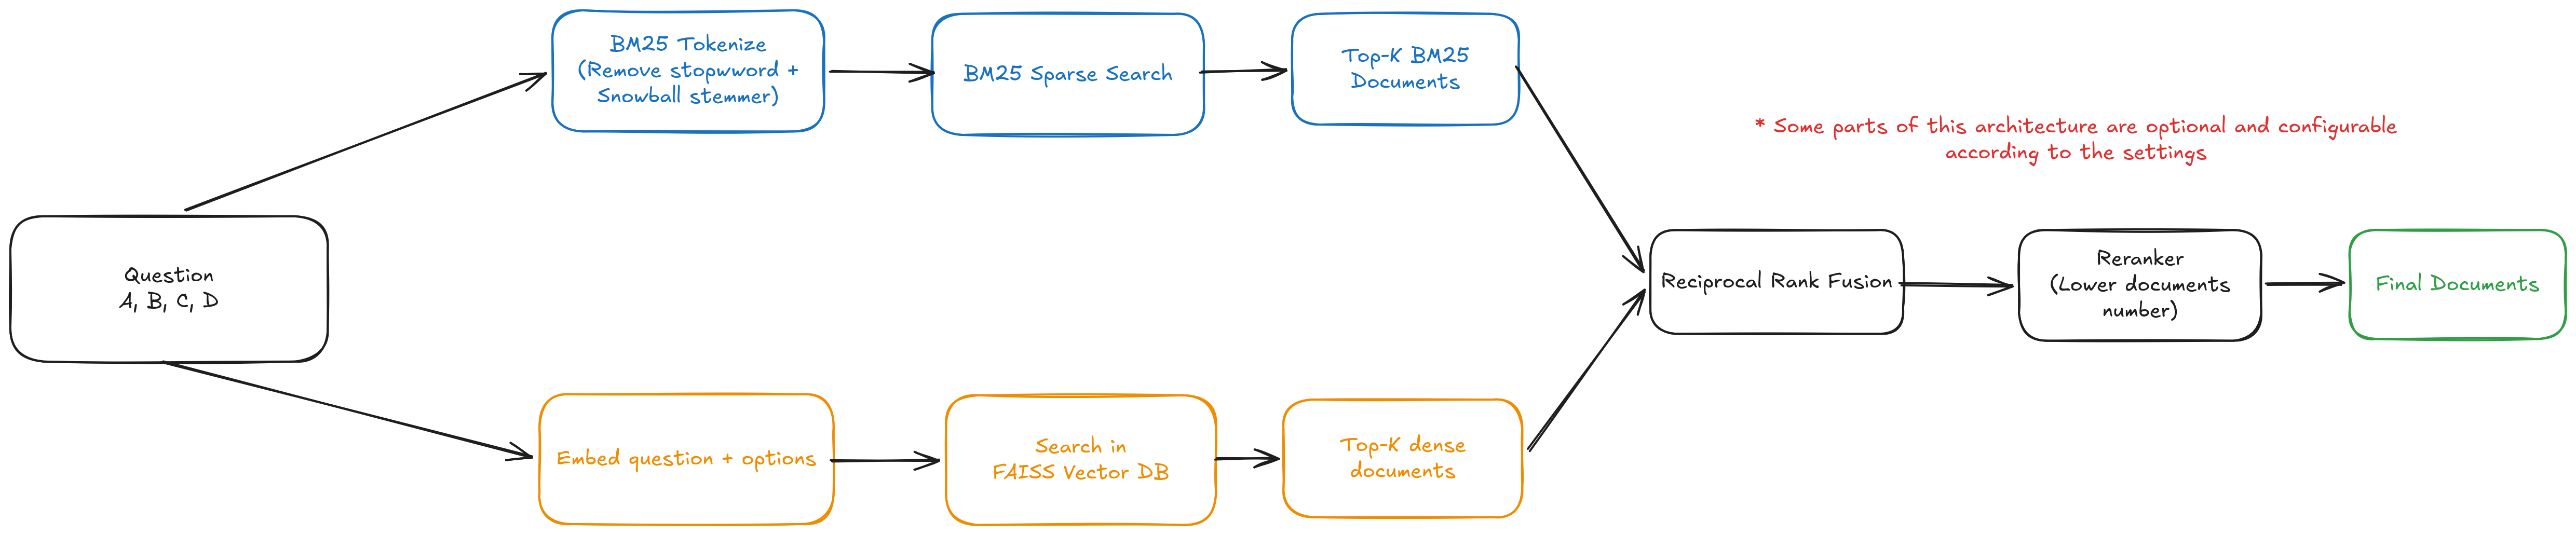

This block builds the retrieval-augmented generation pipeline. Documents are embedded with FAISS, tokenized for BM25 sparse retrieval, optionally fused with Reciprocal Rank Fusion, and exposed through a unified search interface for the agents.

The question (options included) is used as a query to the RAG Index.
The index is composed by two main components:
1. **BM25 Index**: this is used for lexical search. This helps finding domain-specific knowledge (specifically effective for words that the embedder might have never seen)
2. **Semantic search index**: this is used for finding documents that, even though worded differently, are similar to the question semantically. In order to achieve this, all documents are split, embedded and added to teh FAISS vector database for Approximate Nearest Neighbor search.

> **Note**: BM25 and Semantic Search have the same document splits. All our indexes are made by using 512 tokens splitting with an overlap of 128 tokens.

With hybrid search, the results of the two indexes are then reranked using **Reciprocal Rank Fusion (RRF)**.
RRF merges the lists looking at the rank score, and merges them.

If enabled, the results are then **reranker** using a Reranker model. (Usually to reduce 5 documents -> 2 most relevant in a more accurate way)



In [ ]:
# @title RAG Imports and helper functions

import math
import re
import hashlib
from pathlib import Path
from tqdm.auto import tqdm

from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.retrievers import BM25Retriever
from langchain_text_splitters import TokenTextSplitter
from langchain_core.documents import Document


def build_embeddings(settings):
    cfg = settings["embedding"]
    return OpenAIEmbeddings(
        model=cfg["model"],
        base_url=cfg["endpoint"],
        api_key=cfg["apikey"] or "ollama",
        check_embedding_ctx_length=False,
    )



def _doc_key(doc: Document) -> str:
    """Stable identifier for fusion: hash of (title|page_content)."""
    title = (doc.metadata or {}).get("title", "")
    h = hashlib.md5()
    h.update(str(title).encode("utf-8", errors="ignore"))
    h.update(b"\x00")
    h.update((doc.page_content or "").encode("utf-8", errors="ignore"))
    return h.hexdigest()



/tmp/ipykernel_1175/1987145042.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS


In [ ]:
# @title BM25 Tokenization, Stemmer and Stopword remover

_BM25_TOKEN_RE = re.compile(r"\w+", re.UNICODE)

import nltk

# Download NLTK data
def _ensure_nltk_data():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords", quiet=True)

_ensure_nltk_data()

from nltk.corpus import stopwords as _sw
from nltk.stem.snowball import SnowballStemmer

# Load stemmer and stopwords
_STOPWORDS = set(_sw.words("english"))
_STEMMER = SnowballStemmer("english")

# Create BM25 tokenization function
def _bm25_tokenize(text: str) -> list[str]:
    tokens = _BM25_TOKEN_RE.findall((text or "").lower())
    return [_STEMMER.stem(t) for t in tokens if t not in _STOPWORDS]

In [ ]:
# @title RAG Index class

class RAGIndex:
    def __init__(self, embeddings, settings):
        self.embeddings = embeddings
        self.settings = settings
        self.cfg = settings["rag"]
        self.vectorstore: FAISS | None = None
        self._retrievers: dict = {}
        # Mirror of every Document indexed in FAISS; needed to (re)build BM25
        # without a second pass over the source dataset.
        self._all_docs: list[Document] = []

    def _splitter(self):
        # Split the documents according to the settings
        return TokenTextSplitter(
            encoding_name=self.cfg["indexing"]["tokenizer_encoding"],
            chunk_size=self.cfg["indexing"]["chunk_size"],
            chunk_overlap=self.cfg["indexing"]["overlap_size"],
        )

    def _row_to_docs(self, row, splitter) -> list[Document]:
        # Helper function to convert dataset's rows to Langchain Documents
        text = row[self.cfg["indexing"]["text_column"]]
        meta = {k: row[k] for k in self.cfg["indexing"]["metadata_columns"] if k in row}
        return [Document(page_content=chunk, metadata=meta) for chunk in splitter.split_text(text)]

    def _add(self, docs: list[Document]):
        # Add documents to the FAISS vector database
        if self.vectorstore is None:
            self.vectorstore = FAISS.from_documents(docs, self.embeddings)
        else:
            self.vectorstore.add_documents(docs)
        self._all_docs.extend(docs)

    def save(self, path=None):
        # Save the vector database and index
        path = path or self.cfg["indexing"]["index_directory"]
        Path(path).mkdir(parents=True, exist_ok=True)
        self.vectorstore.save_local(path)

    def load(self, path=None):
        # Load database from disk
        path = path or self.cfg["indexing"]["index_directory"]
        self.vectorstore = FAISS.load_local(
            path, self.embeddings, allow_dangerous_deserialization=True
        )
        # Mirror FAISS docstore so BM25 can be rebuilt without re-chunking the dataset.
        self._all_docs = self._docs_from_vectorstore()
        # Load BM25 with hybrid retrivial
        if self.cfg.get("hybrid", {}).get("enabled"):
            self.build_bm25()
        return self

    def _docs_from_vectorstore(self) -> list[Document]:
        # Get the docs from the vector store database
        # Used for BM25
        if self.vectorstore is None:
            return []
        docstore = self.vectorstore.docstore
        mapping = self.vectorstore.index_to_docstore_id
        return [docstore.search(mapping[i]) for i in range(len(mapping))]

    def similarity_search(self, query: str, topk: int | None = None) -> list[dict]:
        # Search in the vector db using the semantic search
        k = topk or self.settings["rag"]["topk"]
        pairs = self.vectorstore.similarity_search_with_relevance_scores(query, k=k)
        return [self._format(doc, score) for doc, score in pairs]

    @staticmethod
    def _format(doc: Document, score: float) -> dict:
        # Format document metadata
        return {
            "title": doc.metadata.get("title"),
            "url": doc.metadata.get("url"),
            "id": doc.metadata.get("id"),
            "categories": doc.metadata.get("categories"),
            "token_count": doc.metadata.get("token_count"),
            "similarity": round(float(score) * 100, 2),
            "text": doc.page_content,
        }

    # ---- Hybrid retrieval: dense (FAISS) + sparse (BM25) fused with RRF ----
    def as_retriever(self, **kw):
        """Expose the dense FAISS retriever for use in an ensemble."""
        return self.vectorstore.as_retriever(**kw)

    def add_retriever(self, name: str, retriever):
        """Register a named retriever (e.g. BM25) for hybrid search."""
        self._retrievers[name] = retriever

    # ---- Build Index functions ----
    def build(self, dataset, show_progress=True):
        """
        """
        # Build semantic similarity index
        splitter = self._splitter()
        bs = self.cfg["indexing"]["batch_size"]
        rows = dataset["train"] if hasattr(dataset, "keys") else dataset

        buffer: list[Document] = []
        it = tqdm(rows, disable=not show_progress, desc="chunking+embedding")
        for row in it:
            buffer.extend(self._row_to_docs(row, splitter))
            while len(buffer) >= bs:
                batch, buffer = buffer[:bs], buffer[bs:]
                self._add(batch)
        if buffer:
            self._add(buffer)
        # If Hybrid retrivial is on, build BM25 index
        if self.cfg.get("hybrid", {}).get("enabled"):
            self.build_bm25()
        return self

    def build_bm25(self, docs: list[Document] | None = None, k: int | None = None) -> "RAGIndex":
        """Build BM25 error
        """
        corpus = docs if docs is not None else self._all_docs
        if not corpus:
            raise RuntimeError(
                "No documents available for BM25. Call build() or load() first, "
                "or pass docs explicitly."
            )
        fetch_k = k or self.cfg.get("hybrid", {}).get("fetch_k", 20)
        bm25 = BM25Retriever.from_documents(corpus, preprocess_func=_bm25_tokenize)
        bm25.k = fetch_k
        self.add_retriever("bm25", bm25)
        return self

    def build_from_texts(self, texts: list[str], metadatas: list[dict] | None = None, show_progress=True):
            """Build the index from a list of plain text strings and optional metadata. Used for hybrid websearch"""
            text_column = self.cfg["indexing"]["text_column"]

            if metadatas is None:
                metadatas = [{} for _ in texts]

            # Standardize into the dictionary-row format expected by self.build()
            dataset = []
            for text, meta in zip(texts, metadatas):
                row = {text_column: text}
                row.update(meta)  # Embed metadata into the row for _row_to_docs extraction
                dataset.append(row)

    @staticmethod
    def _rrf_fuse(
        ranked_lists: dict[str, list[Document]],
        k: int = 60,
        weights: dict | None = None,
    ) -> list[tuple[Document, float, dict[str, int]]]:
        """Reciprocal Rank Fusion.

        For each retriever ``r`` and rank position ``i`` (0-based) of document ``d``,
        contributes ``weights[r] / (k + i + 1)`` to ``d``'s score. Returns docs
        sorted by fused score, paired with per-retriever rank for inspection.
        """
        weights = weights or {}
        scores: dict[str, float] = {}
        ranks: dict[str, dict[str, int]] = {}
        seen: dict[str, Document] = {}
        for name, docs in ranked_lists.items():
            w = float(weights.get(name, 1.0))
            for rank, doc in enumerate(docs):
                key = _doc_key(doc)
                seen.setdefault(key, doc)
                scores[key] = scores.get(key, 0.0) + w / (k + rank + 1)
                ranks.setdefault(key, {})[name] = rank + 1
        order = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
        return [(seen[key], score, ranks[key]) for key, score in order]

    def hybrid_search(self, query: str, topk: int | None = None) -> list[dict]:
        """Dense + registered retrievers fused via Reciprocal Rank Fusion.

        Falls back to pure ``similarity_search`` when no extra retrievers are registered.
        """
        if not self._retrievers:
            return self.similarity_search(query, topk=topk)

        final_k = topk or self.cfg["topk"]
        hcfg = self.cfg["hybrid"]
        fetch_k = hcfg.get("fetch_k", max(final_k * 5, 20))
        rrf_k = hcfg.get("rrf_k", 60)
        weights = hcfg["weights"]

        ranked: dict[str, list[Document]] = {}

        # Dense branch: keep the cosine similarity around for the final report.
        dense_pairs = self.vectorstore.similarity_search_with_relevance_scores(
            query, k=fetch_k
        )
        ranked["dense"] = [d for d, _ in dense_pairs]
        dense_scores = {_doc_key(d): s for d, s in dense_pairs}

        # Get BM25 documents
        for name, retriever in self._retrievers.items():
            # BM25Retriever exposes ``k``; bump it so it returns enough candidates.
            initial_k = retriever.k if hasattr(retriever, "k") else None
            try:
                retriever.k = fetch_k
            except Exception:
                pass
            try:
                docs = retriever.invoke(query)
            except AttributeError:
                docs = retriever.get_relevant_documents(query)
            # Restore original k
            if initial_k is not None:
                retriever.k = initial_k
            ranked[name] = list(docs)[:fetch_k]

        fused = self._rrf_fuse(ranked, k=rrf_k, weights=weights)[:final_k]

        out: list[dict] = []
        for doc, score, per_retriever_rank in fused:
            item = self._format(doc, dense_scores.get(_doc_key(doc), 0.0))
            item["rrf_score"] = round(float(score), 6)
            item["ranks"] = per_retriever_rank
            out.append(item)
        return out

    def rerank(self, query: str, candidates: list[dict], topk: int) -> list[dict]:
        """Rerank candidates with a cross-encoder and return the topk."""
        documents = [text["text"] for text in candidates]
        if topk is None:
            topk = self.cfg["topk"]
        results = reranker.rerank(query, documents, top_n=topk)
        items = []
        for result in results:
            item = candidates[result["index"]]
            item["reranker_score"] = result["relevance_score"]
            items.append(item)
        return items

    def search_without_rerank(self, query: str, topk: int | None = None) -> list[dict]:
        if self._retrievers and self.cfg["hybrid"]["enabled"]:
            return self.hybrid_search(query, topk=topk)
        return self.similarity_search(query, topk=topk)

    def search(self, query: str, topk: int | None = None) -> list[dict]:
        """Single entry point: hybrid when extra retrievers are registered, else dense."""
        if self.cfg["reranker"]["enabled"]:
            candidates = self.search_without_rerank(query, topk=self.cfg["reranker"]["documents_number"])
            return self.rerank(query, candidates, topk=topk)
        else:
            return self.search_without_rerank(query, topk=topk)

In [ ]:
# @title Load/Build RAG index

embeddings = build_embeddings(SETTINGS)
rag = RAGIndex(embeddings, SETTINGS)

idx_dir = SETTINGS["rag"]["indexing"]["index_directory"]
if SETTINGS["rag"]["indexing"]["reindex"] or not Path(idx_dir).exists():
    rag.build(datasets["ancient_history"])
    rag.save()
else:
    rag.load()

# build()/load() auto-fit BM25 when hybrid is enabled; just confirm it's wired up.
if SETTINGS["rag"]["hybrid"]["enabled"]:
    print(f"BM25 fitted over {len(rag._all_docs)} chunks; hybrid retrievers: {list(rag._retrievers)}")


BM25 fitted over 13503 chunks; hybrid retrievers: ['bm25']


In [ ]:
# @title Test retrivial

# query = "According to Hittite documents, which term is believed to be related to the name of the Achaeans, and is mentioned in the Tawagalawa letter?"
query = "Which of the following best describes Coppola's approach to directing 'The Godfather'?"

print("=== Dense only ===")
for hit in rag.similarity_search(query):
    print(hit)
    print(f"[{hit['similarity']}%] {hit['title']} | {hit['url']}")
    print(hit["text"][:300])
    print()

print("=== Hybrid (FAISS + BM25, RRF) ===")
for hit in rag.search_without_rerank(query):
    ranks = hit.get("ranks", {})
    rank_str = ", ".join(f"{r}#{pos}" for r, pos in ranks.items())
    print(f"[rrf={hit.get('rrf_score')} | dense={hit['similarity']}% | {rank_str}] {hit['title']} | {hit['url']}")
    print(hit["text"][:300])
    print()

print("=== Hybrid (FAISS + BM25, RRF, Reranker) ===")
for hit in rag.search(query, 3):
    ranks = hit.get("ranks", {})
    rank_str = ", ".join(f"{r}#{pos}" for r, pos in ranks.items())
    print(f"[reranker={hit.get('reranker_score')} | dense={hit['similarity']}% | {rank_str}] {hit['title']} | {hit['url']}")
    print(hit["text"][:300])
    print()

=== Dense only ===
{'title': 'Socratic method', 'url': 'https://en.wikipedia.org/wiki/Socratic_method', 'id': 49892, 'categories': ['Articles with short description', 'Short description is different from Wikidata', 'Use dmy dates from February 2024', 'All articles with unsourced statements', 'Articles with unsourced statements from January 2024', 'Articles containing Ancient Greek (to 1453)-language text', 'Articles containing Latin-language text', 'Articles containing Latin-language text', 'All articles with unsourced statements', 'Articles with unsourced statements from January 2024', 'All articles with unsourced statements', 'Articles with unsourced statements from January 2024', 'Articles containing Latin-language text', 'Webarchive template wayback links', 'Socrates#Method', 'Debate types', 'Education in ancient Greece', 'Educational psychology', 'History of education', 'Dialectic', 'Inquiry', 'Philosophical methodology', 'Group problem solving methods', 'Rhetoric'], 'token_count'

In [ ]:
# @title Agent configuration helpers - load the right agent for the current configuration


def resolve_agent(name: str, settings: dict) -> dict:
    """Merge a named agent's overrides over the top-level defaults.

    Returns a flat resolved dict with keys:
        prompt_key, llm_cfg, tools_flags, rag_cfg (always contains 'enabled').
    Top-level defaults are used for any key the agent entry omits.
    """
    agent_overrides = settings.get("agents", {}).get(name, {})

    # LLM: merge top-level llm with per-agent llm overrides
    llm_cfg = {**settings["llm"], **agent_overrides.get("llm", {})}

    # Tools: merge top-level tools flags with per-agent overrides
    tools_flags = {**settings["tools"], **agent_overrides.get("tools", {})}

    # RAG: start from top-level rag scalar settings, then apply agent overrides
    default_rag = {
        "enabled": settings["rag"].get("enabled", True),
        "index_directory": settings["rag"]["indexing"]["index_directory"],
        "dataset": settings["datasets"][0]["name"] if settings["datasets"] else None,
        "topk": settings["rag"]["topk"],
    }
    rag_cfg = {**default_rag, **agent_overrides.get("rag", {})}

    # Prompt key: agent override or "default"
    prompt_key = agent_overrides.get("prompt", "default")

    # Few-shots: agent override or top-level default
    few_shots = agent_overrides.get("few_shots", settings.get("few_shots", []))

    # Output mode: agent override or top-level default
    output_mode = agent_overrides.get("output_mode", settings.get("output_mode", "tool"))

    return {
        "name": name,
        "prompt_key": prompt_key,
        "llm_cfg": llm_cfg,
        "tools_flags": tools_flags,
        "rag_cfg": rag_cfg,
        "few_shots": few_shots,
        "output_mode": output_mode,
    }
# Cache resolved agent runtimes so FAISS + BM25 are loaded once per session
# instead of on every question. Clear with `_AGENT_RUNTIME_CACHE.clear()` if
# you change SETTINGS or reindex on disk and want a fresh load.
_AGENT_RUNTIME_CACHE: dict = {}

def get_agent_runtime(name: str, settings: dict, datasets: dict) -> dict:
    """Materialise all runtime objects for a named agent.

    Returns:
        {
          "llm":          ChatOpenAI instance,
          "tools":        list of LangChain tools (without answer_question),
          "rag_index":    RAGIndex | None,
          "prompt_key":   str,
          "rag_enabled":  bool,
          "topk":         int,
        }
    """
    if name in _AGENT_RUNTIME_CACHE:
        return _AGENT_RUNTIME_CACHE[name]

    cfg = resolve_agent(name, settings)

    # Build LLM
    from langchain_openai import ChatOpenAI
    lc = cfg["llm_cfg"]
    llm = ChatOpenAI(
        model=lc["model"],
        base_url=lc.get("endpoint") or None,
        api_key=lc.get("apikey") or "ollama",
    )

    # Build / load RAG index if enabled
    rag_index = None
    if cfg["rag_cfg"]["enabled"]:
        idx_dir = cfg["rag_cfg"]["index_directory"]
        emb = build_embeddings(settings)
        rag_index = RAGIndex(emb, settings)
        if Path(idx_dir).exists():
            rag_index.load(idx_dir)
        else:
            ds_name = cfg["rag_cfg"].get("dataset")
            ds = datasets.get(ds_name) if ds_name else None
            if ds is not None:
                rag_index.build(ds)
                rag_index.save(idx_dir)
            else:
                print(f"[agent:{name}] RAG enabled but dataset '{ds_name}' not found â€” skipping.")
                rag_index = None

    # Build tools; bind per-agent rag_index to rag_search if requested
    tools_flags = cfg["tools_flags"].copy()
    tool_list = []
    if tools_flags.get("rag_search") and rag_index is not None:
        tool_list.append(make_rag_search(rag_index))
        tools_flags = {**tools_flags, "rag_search": False}  # already added manually

    # Add remaining tools via the shared builder (pass a fake settings dict)
    _fake_settings = {**settings, "tools": tools_flags}
    tool_list += [t for t in build_tools_from_settings(_fake_settings)
                  if t.name != "rag_search"]

    runtime = {
        "llm": llm,
        "tools": tool_list,
        "rag_index": rag_index,
        "prompt_key": cfg["prompt_key"],
        "rag_enabled": cfg["rag_cfg"]["enabled"],
        "topk": cfg["rag_cfg"]["topk"],
        "few_shots": cfg["few_shots"],
        "output_mode": cfg["output_mode"],
    }
    _AGENT_RUNTIME_CACHE[name] = runtime
    return runtime

## Agent Loop

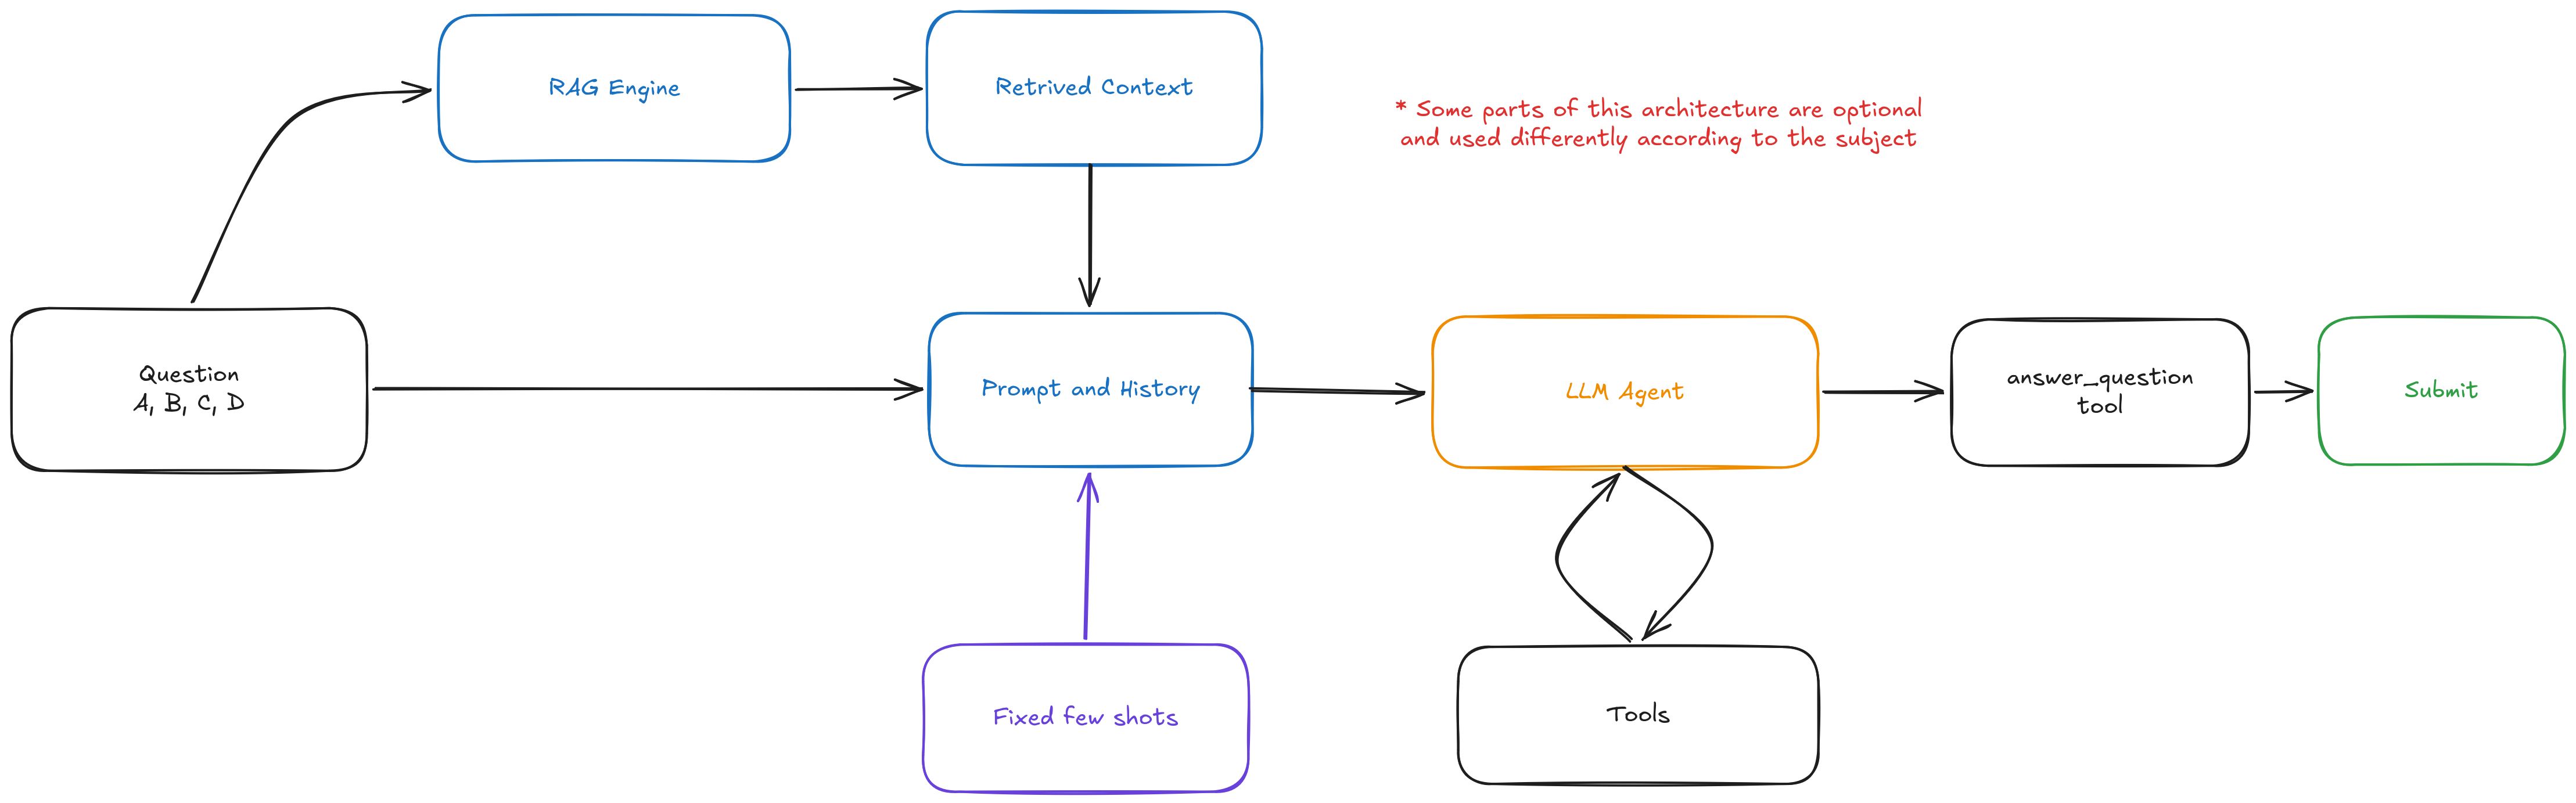

These cells define the core agent architecture. The system builds the LLM, parses answer formats, injects retrieved context, binds tools, runs the tool-calling loop, and returns the selected answer together with metadata such as messages, tools used, and timing.

In [ ]:
# @title Imports and utility functions
import json
import re as _re
import time as _time
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage, AIMessage
from pydantic import BaseModel, Field, model_validator
import ast

def build_llm(settings: dict) -> ChatOpenAI:
    cfg = settings["llm"]
    return ChatOpenAI(
        model=cfg["model"],
        base_url=cfg["endpoint"] or None,
        api_key=cfg["apikey"] or "ollama",
        extra_body=cfg.get("extra_body", {}),
    )


def _parse_few_shot_messages(examples: list[list[dict]]) -> list:
    """Convert few-shot example dicts from config into LangChain message objects.

    Each example is a list of message dicts with:
      - {"role": "human", "content": "..."}
      - {"role": "ai",    "content": "...", "tool_calls": [{...}]}
      - {"role": "tool",  "tool_call_id": "...", "content": "..."}
    """
    messages = []
    for example in examples:
        for msg in example:
            role = msg.get("role", "human")
            if role == "human":
                messages.append(HumanMessage(content=msg.get("content", "")))
            elif role == "ai":
                _tc = msg.get("tool_calls")
                messages.append(AIMessage(
                    content=msg.get("content", ""),
                    tool_calls=_tc if _tc else [],
                ))
            elif role == "tool":
                messages.append(ToolMessage(
                    content=msg.get("content", ""),
                    tool_call_id=msg.get("tool_call_id", ""),
                ))
    return messages



_DIV = "=" * 60

def _verbose_print(msg_type: str, content: str, tool_name: str | None = None):
    """Print a plaintext block during verbose agent execution."""
    if msg_type == "reasoning":
        pass
    elif msg_type == "thinking":
        print(f"{'─' * 40}")
        print(f"  Thinking: {content}")
    elif msg_type == "text":
        print(f"{'─' * 40}")
        print(f"  Text: {content}")
    elif msg_type == "tool_call":
        print(_DIV)
        print(f"  Tool call: {tool_name}")
        print(f"  Args: {content}")
    elif msg_type == "tool_output":
        print(f"{'─' * 40}")
        print(f"  Output ({tool_name}):")
        print(f"  {content}")

In [ ]:
# @title AnswerQuestion Inputs

# 0-3 Indexes AnswerQuestions
class AnswerQuestionInput(BaseModel):
    answer: int = Field(
        ...,
        ge=0,
        le=3,
        description="Your final answer: 0, 1, 2, or 3 (the option number).",
    )
    explanation: str = Field(
        ...,
        description=(
            "Why you chose this answer. "
            "If the information comes from the retrieved context, cite the source title and URL."
            "If you have guessed the answer, start the explaination with GUESSED"
        ),
    )

    @model_validator(mode='before')
    @classmethod
    def _normalize_fields(cls, data):
        if isinstance(data, dict):
            if 'option' in data and 'answer' not in data:
                data['answer'] = data.pop('option')
        return data


class AnswerOnlyInput(BaseModel):
    answer: int = Field(
        ...,
        ge=0,
        le=3,
        description="Your final answer: 0, 1, 2, or 3 (the option number).",
    )

    @model_validator(mode='before')
    @classmethod
    def _normalize_fields(cls, data):
        if isinstance(data, dict):
            if 'option' in data and 'answer' not in data:
                data['answer'] = data.pop('option')
        return data

# A-D Answer Question
# Map between integer option indices (used by the Polimillionaire API and logs)
# and the letter labels shown to the LLM.
LETTERS = ["A", "B", "C", "D"]
def idx_to_letter(i: int) -> str:
    return LETTERS[int(i)]
def letter_to_idx(s) -> int:
    return LETTERS.index(str(s).strip().upper())

class AnswerQuestionInputLetter(BaseModel):
    answer: str = Field(
        ...,
        pattern="^[A-Da-d]$",
        description="Your final answer: A, B, C, or D (the option letter).",
    )
    explanation: str = Field(
        default="",
        description=(
            "Why you chose this answer. Provide a small description."
        ),
    )

    @model_validator(mode='before')
    @classmethod
    def _normalize_fields(cls, data):
        if isinstance(data, dict):
            if 'option' in data and 'answer' not in data:
                data['answer'] = data.pop('option')
        return data


class AnswerOnlyInputLetter(BaseModel):
    answer: str = Field(
        ...,
        pattern="^[A-Da-d]$",
        description="Your final answer: A, B, C, or D (the option letter).",
    )

    @model_validator(mode='before')
    @classmethod
    def _normalize_fields(cls, data):
        if isinstance(data, dict):
            if 'option' in data and 'answer' not in data:
                data['answer'] = data.pop('option')
        return data

def _parse_json_answer(text: str) -> int | None:
    """Try to extract {"answer": <0-3>} from text. Falls back to regex."""
    try:
        obj = json.loads(text)
        ans = obj.get("answer")
        if isinstance(ans, int) and 0 <= ans <= 3:
            return ans
    except (json.JSONDecodeError, AttributeError):
        pass
    m = _re.search(r'\b([0-3])\b', text)
    return int(m.group(1)) if m else None


def _extract_text_tool_call(text: str, tool_names: list[str]) -> tuple[str, dict] | None:
    """Extract a tool call that the LLM wrote as plain text instead of a proper tool call.

    Handles patterns like:
        tool_name{answer:0, explanation:"some text"}
        tool_name(answer=0, explanation="some text")
        tool_name({"answer": 0, "explanation": "some text"})
        tool_name{answer:0,explanation:<|"|>Normality of population...<|"|>}
    """
    for name in tool_names:
        m = _re.search(
            _re.escape(name) + r'\s*[{(]',
            text, _re.DOTALL | _re.IGNORECASE,
        )
        if not m:
            continue
        start = m.end()
        depth, i, in_q = 1, start, False
        while i < len(text) and depth > 0:
            ch = text[i]
            if not in_q and ch == '"':
                in_q = True
            elif in_q and ch == '"' and (i == 0 or text[i - 1] != '\\'):
                in_q = False
            elif not in_q:
                if ch in '{(':
                    depth += 1
                elif ch in '})':
                    depth -= 1
                    if depth == 0:
                        break
            i += 1
        if depth != 0:
            continue
        inner = text[start:i]
        for candidate in (inner, '{' + inner + '}'):
            try:
                obj = json.loads(candidate)
                if isinstance(obj, dict):
                    return name, obj
            except (json.JSONDecodeError, ValueError):
                pass
        args = _parse_pseudo_kv(inner)
        if args:
            return name, args
    return None


def _parse_pseudo_kv(text: str) -> dict | None:
    """Parse comma-separated key:value or key=value pairs (not necessarily valid JSON).

    Handles unquoted keys, various quote wrappers including <|"|>...<|"|>.
    """
    tokens: list[str] = []
    cur = ""
    in_q = False
    depth = 0
    for ch in text:
        if in_q:
            cur += ch
            if ch == '"':
                in_q = False
        elif ch == '"':
            in_q = True
            cur += ch
        elif ch in '{[':
            depth += 1
            cur += ch
        elif ch in '}]':
            depth -= 1
            cur += ch
        elif ch == ',' and depth == 0:
            tokens.append(cur.strip())
            cur = ""
        else:
            cur += ch
    if cur.strip():
        tokens.append(cur.strip())

    args: dict = {}
    for tok in tokens:
        kv = _re.split(r'[:=]\s*', tok, maxsplit=1)
        if len(kv) != 2:
            continue
        key = kv[0].strip().strip('"\'')
        val = kv[1].strip()
        try:
            args[key] = int(val)
            continue
        except ValueError:
            pass
        try:
            args[key] = float(val)
            continue
        except ValueError:
            pass
        for pfx, sfx in [('"', '"'), ("'", "'"), ('<|"|>', '<|"|>'), ('<|"', '"|>')]:
            if val.startswith(pfx) and val.endswith(sfx) and len(val) >= len(pfx) + len(sfx):
                val = val[len(pfx):-len(sfx)]
                break
        args[key] = val
    return args or None


def _lc_messages_to_openai(messages: list) -> list[dict]:
    result = []
    for msg in messages:
        if isinstance(msg, SystemMessage):
            result.append({"role": "system", "content": msg.content})
        elif isinstance(msg, HumanMessage):
            result.append({"role": "user", "content": msg.content})
        elif isinstance(msg, AIMessage):
            d: dict = {"role": "assistant", "content": msg.content or ""}
            if msg.tool_calls:
                d["tool_calls"] = [
                    {
                        "id": tc["id"],
                        "type": "function",
                        "function": {
                            "name": tc["name"],
                            "arguments": json.dumps(tc["args"]),
                        },
                    }
                    for tc in msg.tool_calls
                ]
            result.append(d)
        elif isinstance(msg, ToolMessage):
            result.append({
                "role": "tool",
                "tool_call_id": msg.tool_call_id,
                "content": msg.content,
            })
    return result



In [ ]:
# @title Default Agent loop

def run_agent_loop(
    question: str,
    settings: dict,
    agent: str = "ancient",
    max_iterations: int = 10,
    datasets: dict | None = None,
    verbose: bool = False,
    question_idx = "numbers"
) -> dict:
    """Run a tool-calling agent loop to answer a 4-option multiple-choice question.

    Resolves the named agent's LLM, tools, RAG index, and prompt from SETTINGS,
    then runs the loop until ``answer_question`` is called or max_iterations hit.

    Args:
        question:       Full question text including the four options.
        settings:       The SETTINGS dict.
        agent:          Name of the agent to use (key in SETTINGS['agents']).
        max_iterations: Safety cap on the number of LLM calls.
        datasets:       Dataset dict (used to build RAG index on first call if needed).
        verbose:        If True, stream agent thinking, tool calls, and tool outputs
                        with formatted Markdown display.
        question_idx:   Question idx type, if letters or numbers

    Returns:
        {
            "answer":      int | None,
            "explanation": str | None,
            "rag_context": list[dict],
            "messages":    list,
        }
    """
    t0 = _time.perf_counter()

    ds = datasets if datasets is not None else globals().get("datasets", {})
    runtime = get_agent_runtime(agent, settings, ds)
    output_mode = runtime["output_mode"]

    # 1. RAG context retrieval
    rag_context: list[dict] = []
    if runtime["rag_enabled"] and runtime["rag_index"] is not None:
        # search() routes to hybrid (FAISS + BM25, RRF) when extra retrievers
        # are registered, else falls back to pure dense similarity.
        rag_context = runtime["rag_index"].search(
            question, topk=runtime["topk"]
        )

    # 2. Build answer tools based on output_mode
    _final: dict = {}
    if question_idx == "numbers":
      schemas = [AnswerQuestionInput, AnswerOnlyInput]
    elif question_idx == "letters":
      schemas = [AnswerQuestionInputLetter, AnswerOnlyInputLetter]
    if output_mode == "tool":
        @tool("answer_question", args_schema=schemas[0])
        def answer_question(answer: int, explanation: str) -> str:
            """Submit your final answer to the multiple-choice question.
            Call this exactly once when you are confident in your choice."""
            _final["answer"] = answer
            _final["explanation"] = explanation
            return json.dumps({"status": "submitted", "answer": answer})
        answer_tool = answer_question

    elif output_mode == "tool_no_explanation":
        @tool("answer_question", args_schema=schemas[1])
        def answer_question(answer: int) -> str:
            """Submit your final answer to the multiple-choice question.
            Call this exactly once when you are confident in your choice."""
            _final["answer"] = answer
            _final["explanation"] = ""
            return json.dumps({"status": "submitted", "answer": answer})
        answer_tool = answer_question

    else:
        answer_tool = None

    if answer_tool is not None:
        all_tools = list(runtime["tools"]) + [answer_tool]
    else:
        all_tools = list(runtime["tools"])
    tool_map = {t.name: t for t in all_tools}

    # 3. Assemble chat history with RAG context
    context_block = ""
    user_message = ""
    if rag_context:
        lines = ["\n## Retrieved context\n"]
        for i, hit in enumerate(rag_context, 1):
            lines.append(
                f"### [{i}] {hit['title']}  (similarity: {hit['similarity']}%)\n"
                f"Source: {hit['url']}\n\n"
                f"{hit['text']}\n"
            )
        context_block = "\n".join(lines)
        user_message = "<context>" + context_block + "</context>\n\n"
    user_message += question

    prompt_key = runtime["prompt_key"]
    system_prompt = settings["prompts"][prompt_key]
    messages = [SystemMessage(content=system_prompt)]

    # Inject few-shot examples from config
    messages.extend(_parse_few_shot_messages(runtime["few_shots"]))

    messages.append(HumanMessage(content=user_message))

    # 4. Agent loop
    if all_tools:
        llm_with_tools = runtime["llm"].bind_tools(all_tools)
    else:
        llm_with_tools = runtime["llm"]

    for iteration in range(max_iterations):
        if verbose:
            print(f"\n{_DIV}")
            print(f"  ITERATION {iteration + 1}")
            print(_DIV)

        if verbose:
            text_chunks = []
            reasoning_chunks = []
            tool_calls_accum = {}

            _bound_llm = getattr(llm_with_tools, 'bound', llm_with_tools)
            _tools_kwarg = getattr(llm_with_tools, 'kwargs', {}).get("tools")
            _raw_client = _bound_llm.client
            _stream_params = {
                "model": _bound_llm.model_name,
                "messages": _lc_messages_to_openai(messages),
                "stream": True,
            }
            if _tools_kwarg:
                _stream_params["tools"] = _tools_kwarg

            for raw_chunk in _raw_client.create(**_stream_params):
                if not raw_chunk.choices:
                    continue
                delta = raw_chunk.choices[0].delta

                if delta.content:
                    text_chunks.append(delta.content)

                rc = getattr(delta, 'reasoning', None) or getattr(delta, 'reasoning_content', None)
                if rc:
                    reasoning_chunks.append(rc)

                if delta.tool_calls:
                    for tc in delta.tool_calls:
                        idx = tc.index
                        if idx not in tool_calls_accum:
                            tool_calls_accum[idx] = {"id": "", "name": "", "args": ""}
                        if tc.id:
                            tool_calls_accum[idx]["id"] += tc.id
                        if tc.function:
                            if tc.function.name:
                                tool_calls_accum[idx]["name"] += tc.function.name
                            if tc.function.arguments:
                                tool_calls_accum[idx]["args"] += tc.function.arguments

            full_text = "".join(text_chunks).strip()
            if full_text:
                _verbose_print("thinking", full_text)

            full_reasoning = "".join(reasoning_chunks).strip()
            if full_reasoning:
                _verbose_print("reasoning", full_reasoning)

            parsed_tool_calls = []
            for idx in sorted(tool_calls_accum.keys()):
                tc_data = tool_calls_accum[idx]
                try:
                    args_parsed = json.loads(tc_data["args"]) if tc_data["args"] else {}
                except json.JSONDecodeError:
                    args_parsed = {}
                parsed_tool_calls.append({
                    "id": tc_data["id"],
                    "name": tc_data["name"],
                    "args": args_parsed,
                })

            _tc = parsed_tool_calls if parsed_tool_calls else []
            _ak = {"reasoning_content": full_reasoning} if full_reasoning else {}
            try:
                response = AIMessage(
                    content=full_text,
                    tool_calls=_tc,
                    additional_kwargs=_ak,
                )
            except Exception as _aim_err:
                print(f"Warning: AIMessage construction failed ({_aim_err}). Using plain text response.")
                if full_text:
                    _verbose_print("text", full_text)
                response = AIMessage(content=full_text, tool_calls=[], additional_kwargs={})
        else:
            response = llm_with_tools.invoke(messages)

        messages.append(response)
        messages[-1].additional_kwargs["__elapsed__"] = _time.perf_counter() - t0

        # No tool calls check for text-embedded tool call, then final response
        if not response.tool_calls:
            _text_tc = _extract_text_tool_call(
                response.content or "", list(tool_map.keys()),
            )
            if _text_tc is not None:
                _tc_name, _tc_args = _text_tc
                if verbose:
                    _verbose_print("tool_call", json.dumps(_tc_args, indent=2), tool_name=_tc_name)
                    print(f"  [text-tool-call] Recovered {_tc_name} from plain text")
                else:
                    print(f"  [text-tool-call] {_tc_name}({_tc_args})")
                fn = tool_map.get(_tc_name)
                if fn:
                    result = fn.invoke(_tc_args)
                    messages.append(ToolMessage(
                        content=str(result),
                        tool_call_id=f"txt_{_time.perf_counter_ns()}",
                    ))
                    messages[-1].additional_kwargs["__elapsed__"] = _time.perf_counter() - t0
                if _final:
                    break
                continue

            # JSON mode: parse answer from response text
            if output_mode == "json" and not _final:
                parsed = _parse_json_answer(response.content or "")
                if parsed is not None:
                    _final["answer"] = parsed
                    _final["explanation"] = None
            break

        for tc in response.tool_calls:
            fn = tool_map.get(tc["name"])
            result = fn.invoke(tc["args"]) if fn else f"Unknown tool: {tc['name']}"

            if verbose:
                _verbose_print("tool_call", json.dumps(tc["args"], indent=2), tool_name=tc["name"])
                _verbose_print("tool_output", str(result)[:3000], tool_name=tc["name"])
            else:
                print(tc["name"], tc["args"])

            messages.append(ToolMessage(content=str(result), tool_call_id=tc["id"]))
            messages[-1].additional_kwargs["__elapsed__"] = _time.perf_counter() - t0

        if _final:
            break

    elapsed = _time.perf_counter() - t0
    tools_used = [
        tc["name"]
        for m in messages
        if getattr(m, "tool_calls", None)
        for tc in m.tool_calls
    ]
    if question_idx == "letters":
      _final["answer"] = letter_to_idx(_final.get("answer"))
    return {
        "answer": _final.get("answer"),
        "explanation": _final.get("explanation"),
        "rag_context": rag_context,
        "messages": messages,
        "answer_time": elapsed,
        "tools_used": tools_used,
    }


### Logging

This section records each experiment in structured JSON files. It stores resolved settings, questions, answers, correctness, tool usage, token usage, timing, and separate right/wrong question banks for later analysis.

In [ ]:
# @title Logging utilities
import hashlib
import re
import os
import copy
import tempfile
from datetime import datetime, timezone
from pathlib import Path
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, SystemMessage, ToolMessage


# Helpers

def _slugify(name: str) -> str:
    """Lowercase and replace non-alphanumeric chars with underscores."""
    return re.sub(r"[^a-z0-9]+", "_", name.lower()).strip("_")


def _strip_nolog(obj, nolog_keys: list[str]):
    """Recursively remove keys listed in nolog_keys from nested dicts."""
    if isinstance(obj, dict):
        return {k: _strip_nolog(v, nolog_keys) for k, v in obj.items() if k not in nolog_keys}
    if isinstance(obj, list):
        return [_strip_nolog(i, nolog_keys) for i in obj]
    return obj


def build_resolved_settings_snapshot(settings: dict, agent_name: str) -> dict:
    """Return a JSON-safe resolved-agent config with NOLOG_KEYS stripped."""
    cfg = resolve_agent(agent_name, settings)
    nolog = NOLOG_KEYS
    snapshot = {
        "agent": agent_name,
        "prompt_key": cfg["prompt_key"],
        "prompt_text": settings.get("prompts", {}).get(cfg["prompt_key"], ""),
        "llm": cfg["llm_cfg"],
        "tools": cfg["tools_flags"],
        "rag": cfg["rag_cfg"],
    }
    return _strip_nolog(snapshot, nolog)


def _question_identity(question) -> str:
    """Stable identity for a question: use question.id if available, else content hash."""
    if hasattr(question, "id") and question.id:
        return str(question.id)
    # Sort option texts so reshuffled options still match
    option_texts = sorted(opt.text for opt in question.options) if hasattr(question, "options") else []
    raw = question.text + "|" + "|".join(option_texts)
    return hashlib.sha256(raw.encode()).hexdigest()[:16]


def _extract_token_usage(msg: AIMessage) -> dict:
    """Extract token usage from an AIMessage's response_metadata.

    Handles OpenAI-style (token_usage / usage) and reasoning/thinking tokens
    from both o-series (reasoning_tokens) and thinking-enabled models.
    Returns a dict with input_tokens, output_tokens, thinking_tokens, total_tokens
    (all int, 0 when not present).
    """
    meta = getattr(msg, "response_metadata", {}) or {}

    # OpenAI-style: response_metadata["token_usage"]
    usage = meta.get("token_usage") or meta.get("usage") or {}

    input_tokens  = (usage.get("prompt_tokens")     or usage.get("input_tokens")  or 0)
    output_tokens = (usage.get("completion_tokens")  or usage.get("output_tokens") or 0)
    total_tokens  = (usage.get("total_tokens")       or 0)

    # Thinking / reasoning tokens â€” OpenAI o-series style
    completion_details = usage.get("completion_tokens_details") or {}
    thinking_tokens = (
        completion_details.get("reasoning_tokens")
        or completion_details.get("thinking_tokens")
        or 0
    )

    # Fallback: some providers put thinking_tokens at the top level of usage
    if not thinking_tokens:
        thinking_tokens = usage.get("thinking_tokens") or usage.get("reasoning_tokens") or 0

    # Fallback: count thinking content blocks inside the message content
    if not thinking_tokens and isinstance(msg.content, list):
        for block in msg.content:
            if isinstance(block, dict) and block.get("type") in ("thinking", "reasoning"):
                thinking_tokens += block.get("thinking_tokens", 0) or len(
                    block.get("thinking", block.get("text", ""))
                ) // 4  # rough charâ†’token estimate when count is absent

    if not total_tokens:
        total_tokens = input_tokens + output_tokens

    return {
        "input_tokens":    int(input_tokens),
        "output_tokens":   int(output_tokens),
        "thinking_tokens": int(thinking_tokens),
        "total_tokens":    int(total_tokens),
    }


def _extract_reasoning(msg: AIMessage) -> str | None:
    """Extract reasoning/thinking content from an AIMessage.

    Checks multiple possible locations:
      1. additional_kwargs["reasoning_content"]  (Ollama / OpenAI o-series)
      2. additional_kwargs["reasoning"]           (alternative key)
      3. Direct attribute .reasoning               (some LangChain versions)
      4. Content blocks with type "thinking" / "reasoning" in msg.content (list format)
    """
    for key in ("reasoning_content", "reasoning"):
        raw = msg.additional_kwargs.get(key)
        if raw:
            if isinstance(raw, str):
                return raw
            if isinstance(raw, list):
                return "".join(
                    r.get("text", "") if isinstance(r, dict) else str(r)
                    for r in raw
                )
            return str(raw)

    raw = getattr(msg, 'reasoning', None)
    if raw and isinstance(raw, str):
        return raw

    if isinstance(msg.content, list):
        parts = []
        for block in msg.content:
            if not isinstance(block, dict):
                continue
            if block.get("type") in ("thinking", "reasoning"):
                text = block.get("thinking", block.get("text", ""))
                if text:
                    parts.append(text)
        if parts:
            return "\n".join(parts)

    return None


def _serialize_message(msg: BaseMessage) -> dict:
    """Convert a LangChain message to a plain JSON-safe dict, including token counts."""
    d: dict = {
        "type": msg.__class__.__name__,
        "content": msg.content,
    }
    elapsed = msg.additional_kwargs.get("__elapsed__")
    if elapsed is not None:
        d["elapsed"] = round(elapsed, 3)
    if isinstance(msg, AIMessage):
        if msg.tool_calls:
            d["tool_calls"] = [
                {"id": tc.get("id"), "name": tc.get("name"), "args": tc.get("args")}
                for tc in msg.tool_calls
            ]
        reasoning = _extract_reasoning(msg)
        if reasoning:
            d["reasoning"] = reasoning
        d["token_usage"] = _extract_token_usage(msg)
    if isinstance(msg, ToolMessage):
        d["tool_call_id"] = msg.tool_call_id
        if hasattr(msg, "name"):
            d["name"] = msg.name
    return d


def _aggregate_token_usage(messages: list) -> dict:
    """Sum token usage across all AIMessages in a message list."""
    total = {"input_tokens": 0, "output_tokens": 0, "thinking_tokens": 0, "total_tokens": 0}
    for m in messages:
        if isinstance(m, AIMessage):
            usage = _extract_token_usage(m)
            for k in total:
                total[k] += usage[k]
    return total


def _atomic_write_json(path: Path, data) -> None:
    """Write JSON to path atomically via a temp file."""
    path.parent.mkdir(parents=True, exist_ok=True)
    fd, tmp = tempfile.mkstemp(dir=path.parent, suffix=".tmp")
    try:
        with os.fdopen(fd, "w", encoding="utf-8") as f:
            json.dump(data, f, ensure_ascii=False, indent=2)
        os.replace(tmp, path)
    except Exception:
        try:
            os.unlink(tmp)
        except OSError:
            pass
        raise


def _settings_key(snapshot: dict) -> str:
    return json.dumps(snapshot, sort_keys=True)


# Experiment Logger

class ExperimentLogger:
    """Logs an experiment (multiple game sessions) to a JSON file.

    File naming: if <experiment_name>.json already exists with different settings,
    tries <experiment_name>-1.json, -2.json, ... until a match or a free slot.
    """

    def __init__(self, settings: dict, agent_name: str, competition):
        self._enabled = settings.get("logging", {}).get("enabled", True)
        if not self._enabled:
            self._file_path = None
            self._current_session = None
            return

        log_dir = Path(settings["logging"]["log_dir"])
        experiment_name = settings["logging"]["experiment_name"]
        resolved = build_resolved_settings_snapshot(settings, agent_name)

        self._file_path = self._resolve_file(log_dir, experiment_name, resolved)
        self._resolved_settings = resolved
        self._competition = competition
        self._agent_name = agent_name
        self._current_session: dict | None = None

    @staticmethod
    def _resolve_file(log_dir: Path, name: str, snapshot: dict) -> Path:
        key = _settings_key(snapshot)
        candidates = [log_dir / f"{name}.json"] + [
            log_dir / f"{name}-{i}.json" for i in range(1, 1000)
        ]
        for path in candidates:
            if not path.exists():
                return path
            try:
                existing = json.loads(path.read_text(encoding="utf-8"))
                if _settings_key(existing.get("settings", {})) == key:
                    return path
            except (json.JSONDecodeError, OSError):
                return path
        return candidates[-1]

    def start_session(self):
        if not self._enabled:
            return
        self._current_session = {
            "start_time": datetime.now(timezone.utc).isoformat(),
            "competition_id": self._competition.id,
            "competition_name": self._competition.name,
            "agent": self._agent_name,
            "reward": 0,
            "questions": [],
        }

    def log_question(
        self,
        question,
        messages: list,
        answer: int | None,
        correct: bool | None,
        answer_time: float,
        tools_used: list[str],
        timed_out: bool = False,
    ):
        if not self._enabled or self._current_session is None:
            return
        serialized = [_serialize_message(m) for m in messages]
        token_totals = _aggregate_token_usage(messages)
        self._current_session["questions"].append({
            "level": getattr(question, "level", None),
            "question_id": getattr(question, "id", None),
            "text": question.text,
            "options": [{"id": opt.id, "text": opt.text} for opt in question.options],
            "messages": serialized,
            "tools_used": tools_used,
            "answer": answer,
            "correct": correct,
            "timed_out": timed_out,
            "answer_time": round(answer_time, 3),
            "token_usage": token_totals,
        })

    def end_session(self, reward: float):
        if not self._enabled or self._current_session is None:
            return
        self._current_session["reward"] = reward

        path = self._file_path
        if path.exists():
            try:
                data = json.loads(path.read_text(encoding="utf-8"))
            except (json.JSONDecodeError, OSError):
                data = {"experiment_name": path.stem, "settings": self._resolved_settings, "sessions": []}
        else:
            data = {
                "experiment_name": path.stem.split("-")[0],
                "settings": self._resolved_settings,
                "sessions": [],
            }

        data["sessions"].append(self._current_session)
        _atomic_write_json(path, data)
        print(f"[logger] Session saved â†’ {path}")
        self._current_session = None


# Question Bank Logger

class QuestionBankLogger:
    """Maintains per-category right/wrong question banks on disk."""

    def __init__(self, settings: dict, competition):
        self._enabled = settings.get("logging", {}).get("enabled", True)
        if not self._enabled:
            return
        bank_dir = Path(settings["logging"]["question_bank_dir"])
        slug = _slugify(competition.name)
        self._right_path = bank_dir / f"{slug}_right.json"
        self._wrong_path = bank_dir / f"{slug}_wrong.json"

    def _load(self, path: Path) -> list:
        if path.exists():
            try:
                return json.loads(path.read_text(encoding="utf-8"))
            except (json.JSONDecodeError, OSError):
                pass
        return []

    def record(self, question, chosen_answer: int | None, correct: bool | None):
        if not self._enabled:
            return
        qid = _question_identity(question)
        now = datetime.now(timezone.utc).isoformat()

        right = self._load(self._right_path)
        wrong = self._load(self._wrong_path)

        right_ids = {_question_identity_from_record(r) for r in right}
        wrong_ids  = {_question_identity_from_record(r) for r in wrong}

        record = {
            "question_id": getattr(question, "id", None),
            "level": getattr(question, "level", None),
            "text": question.text,
            "options": [{"id": opt.id, "text": opt.text} for opt in question.options],
            "answer": chosen_answer,
            "first_seen": now,
        }

        if correct:
            if qid not in right_ids:
                right.append(record)
                _atomic_write_json(self._right_path, right)
            # Remove from wrong if present
            if qid in wrong_ids:
                wrong = [r for r in wrong if _question_identity_from_record(r) != qid]
                _atomic_write_json(self._wrong_path, wrong)
        else:
            if qid in right_ids:
                return  # Already known correct â€” skip
            if qid not in wrong_ids:
                wrong.append(record)
                _atomic_write_json(self._wrong_path, wrong)


def _question_identity_from_record(record: dict) -> str:
    """Compute identity from an already-serialized question record."""
    if record.get("question_id"):
        return str(record["question_id"])
    option_texts = sorted(opt["text"] for opt in record.get("options", []))
    raw = record.get("text", "") + "|" + "|".join(option_texts)
    return hashlib.sha256(raw.encode()).hexdigest()[:16]


### Plotting

In [ ]:
# @title Setup

import json
import fnmatch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
plt.rcParams["figure.dpi"] = 110  # figure rendering
plt.rcParams["axes.grid"] = True  # show grid
plt.rcParams["grid.alpha"] = 0.3  # grid opacity

# Source folder: scanned recursively for .json files
MATCH_BASE_PATH = SETTINGS["notebook_settings"]["project_folder"] + "/logs/"

In [ ]:
# @title Experiments loading utilities

_MATCH_CACHE = {}   # selection -> [relative path]

def match_files(experiments=None, force=False):
    """Return the SORTED list of file paths (relative to MATCH_BASE_PATH) that match
    `experiments` — exact names / globs / regex.

    experiments=None  -> use the global EXPERIMENTS
    experiments=[] /  -> every .json in the tree (fallback)
    force=True        -> re-walk the disk (e.g. after adding files)
    """
    if experiments is None:
        experiments = EXPERIMENTS
    key = frozenset(experiments) if experiments else "__ALL__"
    if force or key not in _MATCH_CACHE:
        if not os.path.isdir(MATCH_BASE_PATH):
            parent = os.path.dirname(MATCH_BASE_PATH.rstrip("/")) or "/"
            try:
                siblings = sorted(os.listdir(parent))
            except OSError as e:
                raise FileNotFoundError(
                    f"Base folder not reachable: {MATCH_BASE_PATH!r} ({e}). "
                    f"On Colab the Drive mount is most likely stale/dropped -> "
                    f"re-run the mount cell (it uses force_remount=True)."
                )
            raise FileNotFoundError(
                f"Base folder does not exist: {MATCH_BASE_PATH!r}. "
                f"Check MATCH_BASE_PATH. Contents of {parent!r}: {siblings}"
            )
        select_all = not experiments
        paths = []
        for root, _dirs, files in os.walk(MATCH_BASE_PATH):
            for fn in sorted(files):
                rel = os.path.relpath(os.path.join(root, fn), MATCH_BASE_PATH)
                if select_all:
                    if fn.endswith(".json"):
                        paths.append(rel)
                elif any(_entry_matches(p, rel) for p in experiments):
                    paths.append(rel)
        _MATCH_CACHE[key] = sorted(paths)
    return _MATCH_CACHE[key]


def load_one(relpath):
    """Parse an experiment file (relative to MATCH_BASE_PATH) -> dict.
    Returns None (and warns) if the file isn't valid JSON; raises on read errors."""
    full = os.path.join(MATCH_BASE_PATH, relpath)
    try:
        with open(full, "r", encoding="utf-8") as f:
            return json.load(f)
    except OSError as e:
        raise OSError(
            f"Could not read {full!r} ({e}). On Colab this usually means the Drive "
            f"mount dropped -> re-run the mount cell, then reload (force=True)."
        )
    except json.JSONDecodeError as e:
        print(f"[load_one] skipping non-JSON / invalid {relpath}: {e}")
        return None


def iter_experiments(experiments=None):
    """Yield (relpath, data) for each matched file.
    Only a single parsed experiment is in memory at any moment."""
    for rel in match_files(experiments):
        data = load_one(rel)
        if data is not None:
            yield rel, data

In [ ]:

def _entry_matches(pattern, key):
    """True if `pattern` selects the file identified by `key` (relpath or name).
    `pattern` is interpreted both as a glob (fnmatch, * = wildcard) and as a regex."""
    name = os.path.basename(key)
    pat_base = os.path.basename(pattern)
    targets = {key, name}
    # GLOB
    for pat in {pattern, pat_base}:
        for t in targets:
            if fnmatch.fnmatch(t, pat):
                return True
    # REGEX (not valid regex are ignored)
    for pat in {pattern, pat_base}:
        try:
            rx = re.compile(pat, re.IGNORECASE)
        except re.error:
            continue
        for t in targets:
            if rx.search(t):
                return True
    return False

In [ ]:
def model_label(exp):
    """Readable model label from the file content."""
    try:
        m = exp.get("settings", {}).get("logging").get("experiment_name")
        if m:
            return m
    except Exception:
        pass
    return exp.get("experiment_name", "unknown")


def classify_question(q):
    """'correct' | 'wrong' | 'timeout' | 'other' for a single question."""
    if q.get("timed_out"):
        return "timeout"
    if q.get("correct") is True:
        return "correct"
    if q.get("correct") is False:
        return "wrong"
    return "other"


def build_sessions(experiments=None):
    """Session-level DataFrame (one row = one game), built by STREAMING the matched
    files one at a time via iter_experiments()."""
    rows = []
    for fname, exp in iter_experiments(experiments):     # one file in RAM at a time
        model = fname
        for si, s in enumerate(exp.get("sessions", [])):
            qs = s.get("questions", [])
            rows.append({
                "file": fname,
                "model": model,
                "session_idx": si,
                "reward": s.get("reward", np.nan),
                "n_questions": len(qs),
                "n_correct": sum(1 for q in qs if classify_question(q) == "correct"),
                "n_wrong":   sum(1 for q in qs if classify_question(q) == "wrong"),
                "n_timeout": sum(1 for q in qs if classify_question(q) == "timeout"),
            })
        # `exp` goes out of scope on the next iteration -> freed by the GC.
    return pd.DataFrame(rows)


HIT_THRESHOLDS_DEFAULT = [10, 15]

def aggregate(df_s, thresholds=HIT_THRESHOLDS_DEFAULT):
    """Per-model aggregated metrics. hit@K = % of games with >= K correct."""
    g = df_s.groupby("model")
    agg = g.agg(
        n_runs=("session_idx", "count"),
        avg_reward=("reward", "mean"),
        avg_correct=("n_correct", "mean"),   # mean correct answers per game
        tot_correct=("n_correct", "sum"),
        tot_wrong=("n_wrong", "sum"),
        tot_timeout=("n_timeout", "sum"),
    )
    for k in thresholds:
        agg[f"hit@{k}"] = g["n_correct"].apply(lambda s, k=k: (s >= k).mean() * 100)
    return agg.reset_index()


# Cache the LIGHTWEIGHT session table per selection (never the raw JSON payloads).
_SESSIONS_CACHE = {}

def reset_cache():
    """Forget cached paths and session tables (call after adding/changing files)."""
    _MATCH_CACHE.clear()
    _SESSIONS_CACHE.clear()


def _prepare(experiments=None, thresholds=HIT_THRESHOLDS_DEFAULT):
    """Shared pipeline -> (matched_paths, df_sessions, df_agg, model_order, labels).
    Streams files via build_sessions(); caches only the small session DataFrame."""
    if experiments is None:
        experiments = EXPERIMENTS
    key = frozenset(experiments) if experiments else "__ALL__"
    if key not in _SESSIONS_CACHE:
        _SESSIONS_CACHE[key] = build_sessions(experiments)
    df_s = _SESSIONS_CACHE[key]
    if df_s.empty:
        raise ValueError("No sessions: the selection did not match any valid file.")
    df_a = aggregate(df_s, thresholds)
    order = df_a.sort_values("avg_reward", ascending=False)["model"].tolist()
    df_a = df_a.set_index("model").loc[order].reset_index()
    # labels = filename (without .json) of the first file seen for each model,
    # taken straight from the session table (no need to keep the parsed JSON).
    m2f = df_s.drop_duplicates("model").set_index("model")["file"].to_dict()
    labels = [os.path.basename(m2f[m]).replace(".json", "") for m in order]
    return match_files(experiments), df_s, df_a, order, labels


def _palette(n):
    return plt.cm.tab10(np.linspace(0, 1, n))


def _annotate(ax, bars, values, is_percent=False):
    for b, v in zip(bars, values):
        if is_percent:
            txt = f"{v:.1f}%"
        elif v >= 100:
            txt = f"{v:.0f}"
        else:
            txt = f"{v:.2f}"
        ax.annotate(txt, (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=8,
                    xytext=(0, 2), textcoords="offset points")

In [ ]:
# @title Plot functions

def box_plot(experiments=None):
    """Boxplot of the distribution of correct answers per game, by model."""
    _, df_s, _, order, labels = _prepare(experiments)
    fig, ax = plt.subplots(figsize=(10, 6))
    data_box = [df_s.loc[df_s["model"] == m, "n_correct"].values for m in order]
    bp = ax.boxplot(
        data_box, tick_labels=labels, showmeans=True, patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5),
        meanprops=dict(marker="D", markerfacecolor="white",
                       markeredgecolor="black", markersize=6),
    )
    cmap = plt.cm.viridis(np.linspace(0.15, 0.85, len(order)))
    for patch, c in zip(bp["boxes"], cmap):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    for i, m in enumerate(order, start=1):
        y = df_s.loc[df_s["model"] == m, "n_correct"].values
        x = np.random.normal(i, 0.06, size=len(y))
        ax.scatter(x, y, s=18, color="black", alpha=0.35, zorder=3)
    ax.set_ylabel("Correct answers per game")
    ax.set_title("Distribution of correct answers per game", fontweight="bold")
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right")
    plt.tight_layout()
    plt.show()
    return df_s


def hit_at(k, experiments=None):
    """% of games with >= k correct answers, by model (bar chart)."""
    _, _, df_a, order, labels = _prepare(experiments, thresholds=sorted({10, 15, k}))
    col = f"hit@{k}"
    vals = df_a[col].values
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(order))
    bars = ax.bar(x, vals, color=_palette(len(order)), edgecolor="black", linewidth=0.6)
    _annotate(ax, bars, vals, is_percent=True)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("% success rate")
    ax.set_title(f"% hit@{k} games (>= {k} correct answers)", fontweight="bold")
    plt.tight_layout()
    plt.show()
    return df_a[["model", col]]


def avg_reward(experiments=None):
    """Mean reward per game, by model (log scale)."""
    _, _, df_a, order, labels = _prepare(experiments)
    vals = df_a["avg_reward"].values
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(order))
    bars = ax.bar(x, vals, color=_palette(len(order)), edgecolor="black", linewidth=0.6)
    ax.set_yscale("log")
    _annotate(ax, bars, vals)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Average reward")
    ax.set_title("Average reward (per game)", fontweight="bold")
    plt.tight_layout()
    plt.show()
    return df_a[["model", "avg_reward"]]


def avg_question(experiments=None):
    """Mean CORRECT answers per game, by model (bar chart)."""
    _, _, df_a, order, labels = _prepare(experiments)
    vals = df_a["avg_correct"].values
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(order))
    bars = ax.bar(x, vals, color=_palette(len(order)), edgecolor="black", linewidth=0.6)
    _annotate(ax, bars, vals)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Average correct answers")
    ax.set_title("Average correct answers (per game)", fontweight="bold")
    plt.tight_layout()
    plt.show()
    return df_a[["model", "avg_correct"]]


def overview(experiments=None):
    """4 panels: avg_reward (log), avg_question, hit@10, hit@15."""
    _, _, df_a, order, labels = _prepare(experiments)
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    x = np.arange(len(order))
    colors = _palette(len(order))

    def panel(ax, values, title, ylabel, logy=False, is_percent=False):
        bars = ax.bar(x, values, color=colors, edgecolor="black", linewidth=0.6)
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_ylabel(ylabel)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
        if logy:
            ax.set_yscale("log")
        _annotate(ax, bars, values, is_percent=is_percent)

    panel(axes[0, 0], df_a["avg_reward"].values,
          "Average reward (per game)", "Average reward", logy=True)
    panel(axes[0, 1], df_a["avg_correct"].values,
          "Average correct answers (per game)", "Average correct answers")
    panel(axes[1, 0], df_a["hit@10"].values,
          "% hit@10 games (>= 10 correct answers)", "% success rate", is_percent=True)
    panel(axes[1, 1], df_a["hit@15"].values,
          "% hit@15 games (>= 15 correct answers)", "% success rate", is_percent=True)

    fig.suptitle("Overview — aggregated metrics per experiment", fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    return df_a


COL_CORRECT = "#2ca02c"
COL_WRONG   = "#d62728"
COL_TIMEOUT = "#ffcc80"


def outcomes(experiments=None):
    """Grouped bars: # correct / wrong / timeout per model."""
    _, _, df_a, order, labels = _prepare(experiments)
    fig, ax = plt.subplots(figsize=(12, 6.5))
    x = np.arange(len(order))
    w = 0.26
    corr = df_a["tot_correct"].values
    wrong = df_a["tot_wrong"].values
    tout = df_a["tot_timeout"].values
    b1 = ax.bar(x - w, corr,  w, label="Correct", color=COL_CORRECT, edgecolor="black", linewidth=0.5)
    b2 = ax.bar(x,     wrong, w, label="Wrong",   color=COL_WRONG,   edgecolor="black", linewidth=0.5)
    b3 = ax.bar(x + w, tout,  w, label="Timeout", color=COL_TIMEOUT, edgecolor="black", linewidth=0.5)
    for bars in (b1, b2, b3):
        for b in bars:
            h = b.get_height()
            ax.annotate(f"{int(h)}", (b.get_x() + b.get_width()/2, h),
                        ha="center", va="bottom", fontsize=8,
                        xytext=(0, 2), textcoords="offset points")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("Number of answers")
    ax.set_title("Distribution of the answers")
    ax.legend()
    plt.tight_layout()
    plt.show()
    return df_a[["model", "tot_correct", "tot_wrong", "tot_timeout"]]


def outcomes_pct(experiments=None):
    """% composition of outcomes (stacked, normalized to 100%) per model."""
    _, _, df_a, order, labels = _prepare(experiments)
    x = np.arange(len(order))
    corr = df_a["tot_correct"].values.astype(float)
    wrong = df_a["tot_wrong"].values.astype(float)
    tout = df_a["tot_timeout"].values.astype(float)
    totals = corr + wrong + tout
    totals[totals == 0] = np.nan
    p_corr = corr / totals * 100
    p_wrong = wrong / totals * 100
    p_tout = tout / totals * 100
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x, p_corr, color=COL_CORRECT, edgecolor="black", linewidth=0.5, label="Correct")
    ax.bar(x, p_wrong, bottom=p_corr, color=COL_WRONG, edgecolor="black", linewidth=0.5, label="Wrong")
    ax.bar(x, p_tout, bottom=p_corr + p_wrong, color=COL_TIMEOUT, edgecolor="black", linewidth=0.5, label="Timeout")
    for i in range(len(order)):
        if not np.isnan(totals[i]):
            if p_corr[i] > 6:
                ax.text(i, p_corr[i]/2, f"{p_corr[i]:.0f}%", ha="center", va="center", fontsize=8)
            if p_wrong[i] > 6:
                ax.text(i, p_corr[i] + p_wrong[i]/2, f"{p_wrong[i]:.0f}%", ha="center", va="center", fontsize=8)
            if p_tout[i] > 6:
                ax.text(i, p_corr[i] + p_wrong[i] + p_tout[i]/2, f"{p_tout[i]:.0f}%", ha="center", va="center", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_ylabel("% of total questions")
    ax.set_ylim(0, 100)
    ax.set_title("Outcome composition per experiment (%)")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    return df_a[["model", "tot_correct", "tot_wrong", "tot_timeout"]]

### Tools

This cell defines the tools available to the agents, including web search, web fetch, RAG search, Python execution, a restricted arithmetic calculator, and Wikipedia search. Each agent only receives the tools enabled in its configuration.

| Tool | What it does |
|---|---|
| `answer_question` | Final submission tool. The model calls it to select the chosen multiple-choice option and provide a short explanation. |
| `web_search` | Performs a DuckDuckGo (also with Tavily variant) web search and returns a list of results with title, URL, and short text snippet. |
| `web_fetch` | Fetches the content of a specific URL and returns it as text/markdown. |
| `wikipedia_search` | Searches English Wikipedia and returns article titles, URLs, and summary snippets. |
| `rag_search` | Lets the model explicitly query the local RAG index during the conversation. The index can use dense retrieval and hybrid retrieval with BM25. |
| `python_eval` | Executes Python code with common math/science libraries available, such as `math`, `numpy`, `sympy`, and `statistics`. |
| `simple_calc` | A safer lightweight calculator for single arithmetic expressions. It supports basic operators, roots, logs, trigonometric functions, and constants. |
| `hybrid_websearch`| Web search, fetch found URLs and perform hybrid search over the results

Overall, the most important tools were `answer_question`, `web_search`, `rag_search`/RAG context, and `python_eval`. Search tools were most useful in factual categories, while `python_eval` and `simple_calc` were designed specifically for Math.

In [ ]:
# @title Tools code

import io
import contextlib
import traceback

from google.colab import userdata
from typing import Literal
from tavily import TavilyClient

import wikipedia
from ddgs import DDGS

TAVILY_API_KEY = userdata.get("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY
TAVILY_USE_DATE_FILTER = True

TAVILY_START_DATE = (date.today() - timedelta(days=30)).isoformat()
TAVILY_END_DATE = date.today().isoformat()
TAVILY_TOPIC = "general"

# Web Search Tools
class WebSearchInput(BaseModel):
    term: str = Field(..., description="Web search query.")
    max_results: int = Field(5, description="Maximum number of results to return.")
    max_char_page: int = Field(
        500, description="Truncate each result body to this many characters."
    )

@tool("web_search", args_schema=WebSearchInput)
def web_search(term: str, max_results: int = 5, max_char_page: int = 500) -> str:
    """DuckDuckGo metasearch via ddgs. Returns title/href/body (body truncated)."""
    results = DDGS().text(term, max_results=max_results)
    out = [
        {
            "title": r.get("title"),
            "href": r.get("href"),
            "body": (r.get("body") or "")[:max_char_page],
        }
        for r in results
    ]
    return json.dumps(out, ensure_ascii=False)


class RagSearchInput(BaseModel):
    term: str = Field(..., description="Search query for the local RAG index.")
    topk: int = Field(3, description="Number of top chunks to return.")

def make_rag_search(rag_index):
    """Factory: build a `rag_search` tool bound to the given per-agent RAGIndex."""

    @tool("rag_search", args_schema=RagSearchInput)
    def rag_search(term: str, topk: int = 3) -> str:
        """Search the local RAG index for chunks relevant to the term.

        Uses hybrid retrieval (FAISS dense + BM25 fused with RRF) when extra
        retrievers are registered; otherwise falls back to pure dense search.
        """
        if rag_index is None or rag_index.vectorstore is None:
            return "RAG index not available."
        hits = rag_index.search(term, topk=topk)
        return json.dumps(hits, ensure_ascii=False)

    return rag_search

class TavilySearchInput(BaseModel):
    term: str = Field(..., description="Live web search query for Tavily.")
    max_results: int = Field(5, description="Maximum number of results to return.")
    search_depth: Literal["basic", "advanced"] = Field(
        "basic",
        description="Use 'basic' for faster search, 'advanced' for deeper search."
    )
    include_answer: bool = Field(
        True,
        description="Whether Tavily should return a short generated answer."
    )
    include_raw_content: bool = Field(
        False,
        description="Whether to include raw page content."
    )
    max_char_page: int = Field(
        800,
        description="Truncate each result content to this many characters."
    )

def _get_tavily_client() -> TavilyClient:
    api_key = os.getenv("TAVILY_API_KEY", "").strip()
    return TavilyClient(api_key=api_key)


@tool("tavily_search", args_schema=TavilySearchInput)
def tavily_search(
    term: str,
    max_results: int = 5,
    search_depth: str = "basic",
    include_answer: bool = True,
    include_raw_content: bool = False,
    max_char_page: int = 800,
) -> str:
    """Search the live web using Tavily. Use it when RAG is missing, insufficient, vague, or outdated."""
    try:
        client = _get_tavily_client()

        response = client.search(
            query=term,
            max_results=max_results,
            search_depth=search_depth,
            include_answer=include_answer,
            include_raw_content=include_raw_content,
        )

        out = {
            "query": response.get("query", term),
            "answer": response.get("answer"),
            "results": [],
        }

        for r in response.get("results", []):
            content = r.get("raw_content") or r.get("content") or ""
            out["results"].append(
                {
                    "title": r.get("title"),
                    "url": r.get("url"),
                    "score": r.get("score"),
                    "content": content[:max_char_page],
                }
            )

        return json.dumps(out, ensure_ascii=False)

    except Exception as e:
        return f"Tavily search error: {type(e).__name__}: {e}"


class WebFetchInput(BaseModel):
    url: str = Field(..., description="URL to fetch.")
    max_chars: int = Field(4000, description="Truncate fetched content to this many characters.")

@tool("web_fetch", args_schema=WebFetchInput)
def web_fetch(url: str, max_chars: int = 4000) -> str:
    """Fetch a URL and return its content as markdown, truncated to max_chars."""
    res = DDGS().extract(url, fmt="text_markdown")
    content = res.get("content", "") if isinstance(res, dict) else str(res)
    return content[:max_chars]

class PythonEvalInput(BaseModel):
    python_script: str = Field(
        ..., description="Python source code to execute. Combined stdout/stderr is returned."
    )

_PYTHON_NS = {
    "__builtins__": __builtins__,
    "math": __import__("math"),
    "np": __import__("numpy"),
    "sympy": __import__("sympy"),
    "statistics": __import__("statistics"),
    "cmath": __import__("cmath"),
    "random": __import__("random"),
}


@tool("python_eval", args_schema=PythonEvalInput)
def python_eval(python_script: str) -> str:
    """Execute Python code with pre-imported modules (math, np/numpy, sympy, statistics, cmath, random).
    Returns combined stdout/stderr (or traceback on error). Variables persist across calls."""
    buf = io.StringIO()
    try:
        with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
            exec(python_script, _PYTHON_NS)
    except Exception:
        buf.write("\n" + traceback.format_exc())
    return buf.getvalue() or "(no output)"

# -- Simple arithmetic calculator ---------------------------------------------
# Lightweight replacement for `python_eval` for pure-arithmetic expressions like
# `(3*5 + 2/7879)**3`. AST-validates a single expression, allows a small
# whitelist of math functions/constants, and returns `repr(float(result))`.

class SimpleCalcInput(BaseModel):
    expression: str = Field(
        ...,
        description=(
            "A single arithmetic expression to evaluate, e.g. '(3*5 + 2/7879)**3', "
            "'sqrt(3**2 + 4**2)', 'log(2) * pi'. Allowed: numbers; operators "
            "+ - * / // % **; parentheses; functions sqrt, abs, log, exp, sin, cos, "
            "tan, floor, ceil; constants pi, e. No variables, no attribute access, "
            "no statements."
        ),
    )

_SIMPLE_CALC_NS = {
    "sqrt": math.sqrt, "abs": abs,
    "log": math.log, "exp": math.exp,
    "sin": math.sin, "cos": math.cos, "tan": math.tan,
    "floor": math.floor, "ceil": math.ceil,
    "pi": math.pi, "e": math.e,
}

_SIMPLE_CALC_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Constant, ast.Call,
    ast.Name, ast.Load,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.FloorDiv, ast.Mod, ast.Pow,
    ast.UAdd, ast.USub,
)


@tool("simple_calc", args_schema=SimpleCalcInput)
def simple_calc(expression: str) -> str:
    """Evaluate a pure arithmetic expression and return its float value as a string.

    Allowed: numbers; operators + - * / // % **; parentheses; functions
    sqrt, abs, log, exp, sin, cos, tan, floor, ceil; constants pi, e.
    Rejects variables, attribute access, statements, and anything else.
    """
    try:
        tree = ast.parse(expression, mode="eval")
    except SyntaxError as exc:
        return f"Parse error: {type(exc).__name__}: {exc}"

    for node in ast.walk(tree):
        if not isinstance(node, _SIMPLE_CALC_NODES):
            return f"Rejected: node {type(node).__name__} not allowed"
        if isinstance(node, ast.Call) and not isinstance(node.func, ast.Name):
            return "Rejected: only direct function calls allowed"
        if isinstance(node, ast.Name) and node.id not in _SIMPLE_CALC_NS:
            return f"Rejected: unknown name {node.id!r}"

    try:
        result = eval(
            compile(tree, "<simple_calc>", "eval"),
            {"__builtins__": {}},
            _SIMPLE_CALC_NS,
        )
    except Exception as exc:
        return f"Eval error: {type(exc).__name__}: {exc}"

    return repr(float(result))


class WikipediaSearchInput(BaseModel):
    term: str = Field(
        ...,
        description=(
            "Short English Wikipedia-oriented query: entity names, places, periods, events "
            "(e.g. 'Middle Kingdom of Egypt'). Not the full exam questionâ€”one focused phrase per call."
        ),
    )
    max_results: int = Field(
        5,
        description="How many matching article titles to fetch from Wikipedia search (then summarized).",
    )
    max_char_page: int = Field(
        500,
        description="Max characters of each article summary snippet in the response.",
    )


@tool("wikipedia_search", args_schema=WikipediaSearchInput)
def wikipedia_search(term: str, max_results: int = 5, max_char_page: int = 500) -> str:
    """Query English Wikipedia: searches article titles, returns title/url/summary per hit.

    Prefer concise term strings (people, places, events). For multi-part questions,
    call multiple times with distinct terms rather than one long query."""
    titles = wikipedia.search(term, results=max_results)
    out = []
    for title in titles:
        try:
            page = wikipedia.page(title, auto_suggest=False, redirect=True)
            summary = page.summary
            url = page.url
        except (wikipedia.DisambiguationError, wikipedia.PageError, Exception):
            try:
                summary = wikipedia.summary(title, auto_suggest=False)
            except Exception:
                summary = ""
            url = f"https://en.wikipedia.org/wiki/{title.replace(' ', '_')}"
        out.append({"title": title, "url": url, "summary": (summary or "")[:max_char_page]})
    return json.dumps(out, ensure_ascii=False)


def build_tools_from_settings(settings: dict) -> list:
    """Return the list of LangChain tools enabled in SETTINGS['tools']."""
    flags = settings.get("tools", {})
    out = []
    if flags.get("rag_search"):
        out.append(rag_search)
    if flags.get("web_search"):
        out.append(web_search)
    if flags.get("web_fetch"):
    out.append(web_fetch)
    if flags.get("tavily_search"):
      out.append(tavily_search)
    if flags.get("python_eval"):
      out.append(python_eval)
    if flags.get("wikipedia_search"):
        out.append(wikipedia_search)
    if flags.get("simple_calc"):
        out.append(simple_calc)
    if flags.get("hybrid_websearch"):
        out.append(web_search2)
    return out

In [ ]:
from trafilatura import fetch_url, extract
from trafilatura.settings import DEFAULT_CONFIG
from copy import deepcopy
LAST_QUESTION = ""

FETCH_CONFIG = deepcopy(DEFAULT_CONFIG)
FETCH_CONFIG["DEFAULT"]["DOWNLOAD_TIMEOUT"] = "2"
FETCH_CONFIG["DEFAULT"]["SLEEP_TIME"] = "0"
FETCH_CONFIG["DEFAULT"]["USER_AGENT"] = "Mozilla/5.0 (X11; Linux x86_64; rv:151.0) Gecko/20100101 Firefox/151.0"
def _process_single_result(result):
    """Worker function to handle fetching and extracting for a single URL."""
    try:
        downloaded = fetch_url(result['href'], config=FETCH_CONFIG)
        extracted = extract(downloaded) if downloaded else None

        if extracted is None:
            result['text'] = result.get("body", "")
        else:
            result['text'] = extracted[:50000]

    except Exception as e:
        # Fallback to body if anything blows up during network request
        result['text'] = result.get("body", "")
        print(f'(Error: {e})')
    result["url"] = result["href"]

    return result


@tool("web_fetch", args_schema=WebFetchInput)
def web_fetch_2(url: str, max_chars: int = 4000) -> str:
    """Fetch a URL and return its content as markdown, truncated to max_chars."""
    content = _process_single_result({"href": url, "body": ""})['text']
    if content is None or len(content) < 4:
      return "It was not possible to extract the content. Please run a web_fetch on another page"

    return content[:max_chars]

def _web_search(query, max_results, timelimit=None):
    # Get the search results and force them into a list

    try:
          results = list(DDGS().text(query, max_results=max_results, backend="google", timelimt=timelimit))
          final_results = []
          blacklist = ["facebook", "youtube", "tiktok", "instagram", "x.com", "reddit", "t.me"]
          for result in results:
            for word in blacklist:
              if word in result["href"]:
                continue
            final_results.append(result)
          ddgs_results = final_results[:max_results]
    except Exception as e:
      print(e)
      return []
    with ThreadPoolExecutor(max_workers=5) as executor:
        final_results = list(executor.map(_process_single_result, ddgs_results))

    return final_results

def hybrid_web_search(query, max_results):
    import time
    t0 = time.time()
    results = _web_search(query, max_results, "m")
    t1 = time.time()
    if len(results) == 0:
      results = _web_search(query, max_results)
    if len(results) == 0:
      return []
    print(t1-t0)
    SETTINGS["rag"]["hybrid"]["enabled"] = True
    SETTINGS["rag"]["hybrid"]["fetch_k"] = 5
    index = RAGIndex(embeddings, SETTINGS)
    index.build_from_texts([result["text"] for result in results], results)
    question = LAST_QUESTION
    return index.hybrid_search(question, topk=5)


class HybridWebSearchInput(BaseModel):
    query: str = Field(..., description="Search query string.")
    max_results: int = Field(
        4, description="Number of web search result pages to fetch and index."
    )

@tool("web_search", args_schema=HybridWebSearchInput)
def make_hybrid_web_search(query, max_results):
  """ Search the web and return the most relevant text
  """
  search_results = hybrid_web_search(query, max_results)
  if len(search_results) == 0:
    return "No results found. Please use the web_search tool again with a different query"
  results = []
  for i, result in enumerate(search_results):
    txt = f"## Result {i}"
    txt += "\nURL: " + result["url"]
    txt += "\n\n" + result["text"]
    results.append(txt)
  text = "\n\n".join(results)
  return tex

In [ ]:
# @title Test an agent loop
# Skip cell
# script false --no-raise-error

example_question = """Which of the following best describes Coppola's approach to directing 'The Godfather'?
0. He followed the novel closely without changes
1. He focused on technical aspects only
2. He aimed a broad, historical perspective
3. He prioritized quick production to save costs
"""
result = run_agent_loop(example_question, settings=SETTINGS, agent="entertainment", datasets={}, verbose=True)

print(f"Answer: {result['answer']}")
print(f"Explanation: {result['explanation']}")
print(result["messages"])

KeyboardInterrupt: 

## Polimillionaire

This section connects the agent to the Polimillionaire game loop. It selects the competition, loads the local model, routes each question to the correct specialized agent, submits answers, logs results, and repeats the game for the configured number of experiments.

In [ ]:
# @title Competition Selection

# List available competitions and pick one
competitions = client.competitions.list_all()
for comp in competitions:
    print(f"  ID: {comp.id}  |  {comp.name}")

# Set this to the competition you want to play
comp_id = SETTINGS["polimillionaire"]["comp_id"]
print(f"\nUsing competition ID: {comp_id}")

  ID: 0  |  Entertainment
  ID: 1  |  Ancient History and Politics
  ID: 2  |  Science and Nature
  ID: 3  |  Maths
  ID: 4  |  Philosophy and Psychology
  ID: 5  |  News

Using competition ID: 1


In [ ]:
# @title Load ollama model
!ollama run {SETTINGS["llm"]["model"]} "Hello"

Hello! How can I help you today?



In [ ]:
# @title Method do run agent loop to answer a question
def answer_question(full_text: str, comp_id: int, verbose: bool = False) -> str:
    """Route to the correct agent for *comp_id* and return the chosen option (0-3) as a string.

    Falls back to SETTINGS['default_agent'] if comp_id is not in competition_to_agent.
    """
    agent_name = SETTINGS["competition_to_agent"].get(comp_id, SETTINGS["default_agent"])
    result = run_agent_loop(full_text, settings=SETTINGS, agent=agent_name, datasets=datasets, verbose=verbose)
    answer = result.get("answer")
    explanation = result.get("explanation", "")
    print(f"  [agent:{agent_name}] answer={answer}  |  {explanation[:120]}")
    return str(answer) if answer is not None else "0"

In [ ]:
# @title Play Game Method

import json
import time
import re as _re
from IPython.display import Audio, display

def save_audio(data: bytes, filename: str):
    """Save audio bytes to a WAV file."""
    with open(filename, "wb") as f:
        f.write(data)
    print(f"  Saved: {filename}")

def play_game(
    game,
    verbose: bool = True,
    architecture=run_agent_loop,
    question_idx="numbers",
    audio_mode=False,
    recognize_speech=None,
):
    competition_id = game.state.competition.id
    competition = game.state.competition
    agent_name = SETTINGS["competition_to_agent"].get(
        competition_id, SETTINGS["default_agent"]
    )

    # Initialise loggers (no-ops when logging.enabled is False)
    exp_logger = ExperimentLogger(SETTINGS, agent_name, competition)
    bank_logger = QuestionBankLogger(SETTINGS, competition)
    exp_logger.start_session()

    while game.in_progress:
        # --- TEXT MODE BRANCH ---
        if not audio_mode:
            question = game.current_question
            if not question:
                print("No question available. Game may have ended.")
                break

            print(f"\n--- Level {game.current_level} ---")
            full_text = f"Q: {question.text}"
            print(f"Q: {question.text}")
            print()

            for opt in question.options:
                opt_label = (
                    opt.id
                    if question_idx == "numbers"
                    else idx_to_letter(opt.id)
                )
                print(f"  {opt_label}. {opt.text}")
                full_text += f"\n  {opt_label}. {opt.text}"

        # --- AUDIO MODE BRANCH ---
        else:
            print(f"\n--- Level {game.current_level} ---")
            print("Fetching question audio...")
            try:
                question_audio = game.fetch_audio_question()
                save_audio(
                    question_audio, f"level_{game.current_level}_question.wav"
                )
                display(Audio(question_audio))
            except GameError as e:
                print(f"Error fetching question audio: {e}")
                break

            # Transcribe the question audio synchronously
            if recognize_speech:
                q_text = recognize_speech(question_audio)
            else:
                q_text = "[Audio Question Transcribed]"

            print(f"Q: {q_text}\n")
            full_text = f"Q: {q_text}"

            audios = []
            # Fetch and transcribe options sequentially (A, B, C, D)
            for i in range(4):
                letter = chr(65 + i)  # A, B, C, D
                print(f"Fetching option {letter} audio...")
                try:
                    option_audio = game.fetch_audio_option_next()
                    save_audio(
                        option_audio,
                        f"level_{game.current_level}_option_{letter}.wav",
                    )
                    audios.append(option_audio)
                except Exception as e:
                    print(f"Error fetching option audio: {e}")
                    break

                # Transcribe the option audio synchronously
                if recognize_speech:
                    opt_text = recognize_speech(option_audio)
                else:
                    opt_text = f"[Audio Option {letter} Transcribed]"

                # Resolve correct label formatting based on question_idx preference
                if game.current_question and i < len(
                    game.current_question.options
                ):
                    opt = game.current_question.options[i]
                    opt_label = (
                        opt.id
                        if question_idx == "numbers"
                        else idx_to_letter(opt.id)
                    )
                else:
                    opt_label = letter

                print(f"  {opt_label}. {opt_text}")
                full_text += f"\n  {opt_label}. {opt_text}"

            # Workaround for ipykernel display logic
            if len(audios) == 4:
                display(
                    Audio(audios[0]),
                    Audio(audios[1]),
                    Audio(audios[2]),
                    Audio(audios[3]),
                )
            elif audios:
                for aud in audios:
                    display(Audio(aud))

            game.refresh_state()
            question = game.current_question

        # --- AGENT ARCHITECTURE EXECUTION (Shared) ---
        time_left = game.time_remaining
        if time_left is not None:
            print(f"\nTime remaining: {time_left:.1f}s")

        try:
            LAST_QUESTION = full_text
            agent_result = architecture(
                full_text,
                settings=SETTINGS,
                agent=agent_name,
                datasets={},
                verbose=verbose,
                question_idx=question_idx,
            )
            answer_id = agent_result.get("answer")
            explanation = agent_result.get("explanation", "")
            messages = agent_result.get("messages", [])
            tools_used = agent_result.get("tools_used", [])
            answer_time = agent_result.get("answer_time", 0.0)

            print(
                f"  [agent:{agent_name}] answer={answer_id}  |  {explanation[:120]}"
            )

            if answer_id is None:
                answer_id = 0
        except Exception as e:
            print(f"Agent error: {e}. Defaulting to 0.")
            _match = _re.search(r"input_value=(\{[^}]+\})", str(e))
            if _match:
                print(f"  Actual tool call args: {_match.group(1)}")
            try:
                _val = (
                    json.loads(_match.group(1).replace("'", '"'))
                    if _match
                    else {}
                )
                answer_id = _val.get("answer", 0)
                print(f"  Recovered answer from failed tool call: {answer_id}")
            except Exception:
                answer_id = 0
            messages, tools_used, answer_time = [], [], 0.0

        # Submit answer to the game engine
        result = game.answer(answer_id)

        # Log details
        exp_logger.log_question(
            question=question,
            messages=messages,
            answer=answer_id,
            correct=result.correct,
            answer_time=answer_time,
            tools_used=tools_used,
            timed_out=result.timed_out,
        )
        if question:
            bank_logger.record(
                question, chosen_answer=answer_id, correct=result.correct
            )

        # Handle feedback and state terminations
        if result.correct:
            print(" CORRECT!")
            if result.game_over:
                print(f"\n CONGRATULATIONS! You completed the game!")
                print(f" Final earnings: ${result.earned_amount:,.2f}")
            else:
                print(f" Earned so far: ${result.earned_amount:,.2f}")
        elif result.timed_out or getattr(result, "status", "") == "timeout":
            print(" TIMED OUT!")
            print(f"\n Game Over!")
            print(f" Final earnings: ${result.earned_amount:,.2f}")
            break
        else:
            print(" WRONG ANSWER!")
            print(f"\n Game Over!")
            print(f" Final earnings: ${result.earned_amount:,.2f}")
            break

    exp_logger.end_session(reward=game.earned_amount)

    print("\n=== Game Summary ===")
    print(f"Reached Level: {game.current_level}")
    print(f"Total Earnings: ${game.earned_amount:,.2f}")

In [ ]:
# @title Game experiments

for i in range(SETTINGS["polimillionaire"]["experiments"]):
  print(f"\n=== Starting Game {i} ===")
  game = client.game.start(competition_id=comp_id)
  print(f"Session ID: {game.session_id}")
  print(f"Total number of questions: {game.state.competition.max_levels}")
  print()
  play_game(game)

## Experiment results

## Maths

Dataset description

Math questions required us to do a bit more thinking:
- We quickly noticed that **RAG would not have been effective** with math questions.
  1. Theory questions always involved applying theory well. Multiple concepts were often required to answer correctly. **Retrieving wrong concepts or text snippets would have a huge negative impact on the model**, causing it to create wrong reasoning. (Specially considering that we are using <10B models)
  2. Computation questions also have similar issues. Giving a pure theory dataset would worsen the performance, making the model use longer more formal routes (it is also hard to retrieve the correct theory questions). With an exercise dataset, **exercises with an high semantic similarity might have totally different steps**.

  Several areas are covered across both categories: abstract algebra, statistics and inference, probability, calculus and real analysis, number theory, geometry, and precalculus/algebra, with the options frequently being **mathematical expressions** rather than plain text, like fractions, roots, and symbolic forms (e.g. 3/4, \frac{3}{4}\sqrt{2}) and theory-driven computational questions (e.g. applications of Bayes' Theorem, hypergeometrical and binomial probability, etc...).

- LLMs are **not reliable with numeric calculations**. They learn relationships between tokens in a statistical way. They do not actually learn operations.

So, in order to improve our performances, we needed to rely on "**parametric skills**" and **tools** for calculations.

First of all, we evaluated some interesting models performances with a simple prompt and no tools (except for `answer_question`).


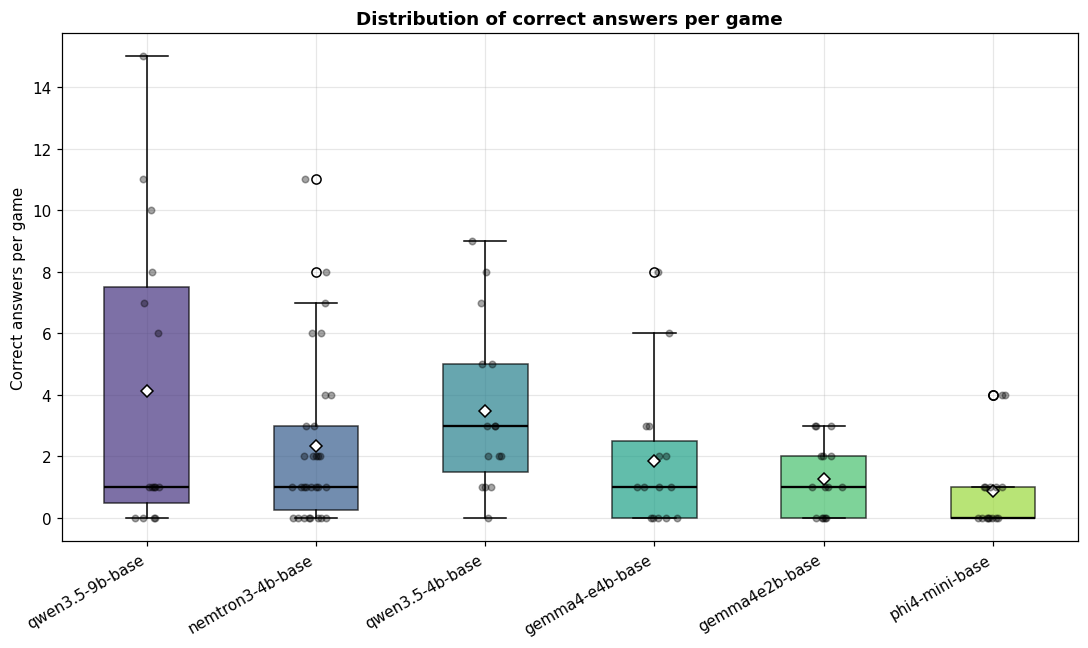

In [ ]:
# @title Base models experiments
df = box_plot(["experiments-math/*-base.json"])

Here is what we got:
1. Even though they performed better in previous categories, **Gemma models are pretty bad at math**. In the previous categories, they were likely advantaged by the higher number of total parameters.
2. Qwen3.5:9b is very good at math (as the whole Qwen family). It also **managed to score a million alone**. However, it **suffers timeouts**, which lowered the mean score.
3. Qwen3.5:4b never managed to get over 10 in a row but got a similar mean to the 9B model. This shows a good margin of improvement as it suffers less from timeouts.
4. Nemotron-3-nano:4b got a few higher scores than Qwen but with a smaller mean. Via manual inspection, we found that the errors were mostly calculation errors or tool call erros. This also probably shows some margin for improvement.
5. phi4-mini:3.8b was a praised model for maths when it came out. It performed pretty badly, this shows how much improvement there has been in just one year. It also shows that thinking models perform better.

> We also tried some different models later with tools.

In order to **improve the models performance** we could:
1. Add some **tool** for calculations
2. Try some **special architecture** (which we did later)
3. Improve our **prompt engineering**
4. **Fine-tune** a model for these tasks specifically. (we did not persue this, as stated later)

**Prompt engineering**

While doing our experiments we started with a very detailed prompt, as we are used to prompt big LLMs. We noticed that the models were not following our instructions well, and their internal reasoning often extended too much on detecting if they had to use some tools or not.
Instead, we made a more simple prompt with a Chain-of-Thought style. First, the model decides if to use the tools (for theory they are not required), then if it needs them, it uses them, and then matches the answer.
This change alone, gave us a ~10-20% of better mean performance.

**Tools**

In order to improve the models' calculations abilities, we tried three different tools:
1. `python_eval`: gives the model the ability to execute python code. This allows the model to perform big calculations and algorithms reliably.
2. `sympy_calc`: gives the model the ability to calculate some sympy expressions. The reason we tried this is to lower the time to generate python code and avoid timeouts. Since this performed pretty badly (likely because of the lack of training on this very specific syntax), we discared it (it is also not present in the notebook)
3. `simple_calc`: A simple calculator for arithmetic. Supports a python-like syntax and allowed the model to answer faster compared to python_eval


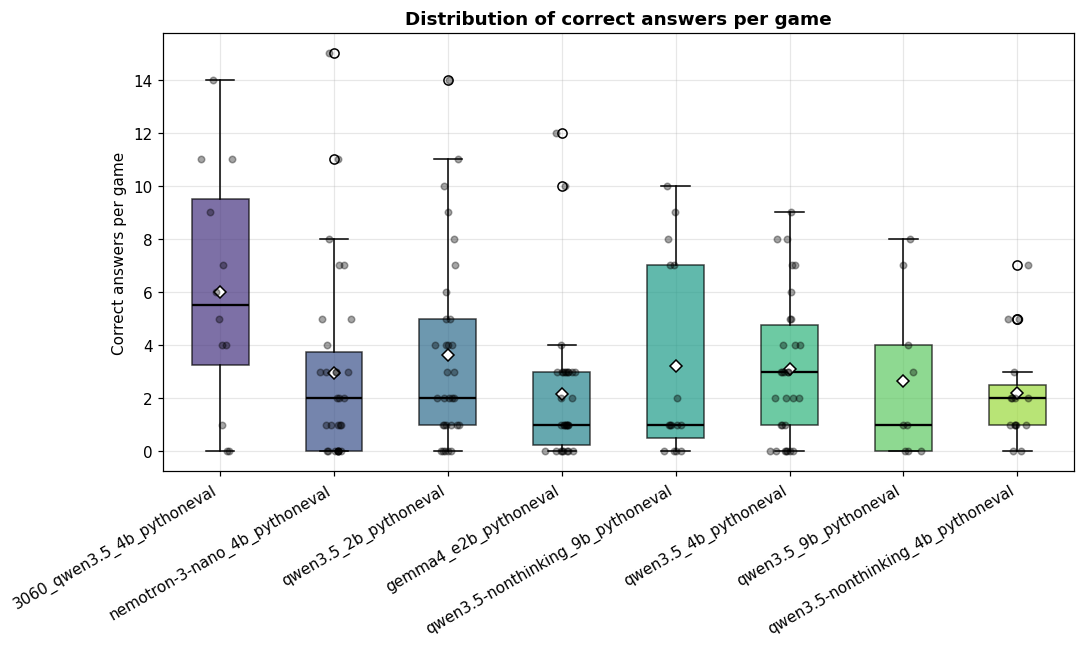

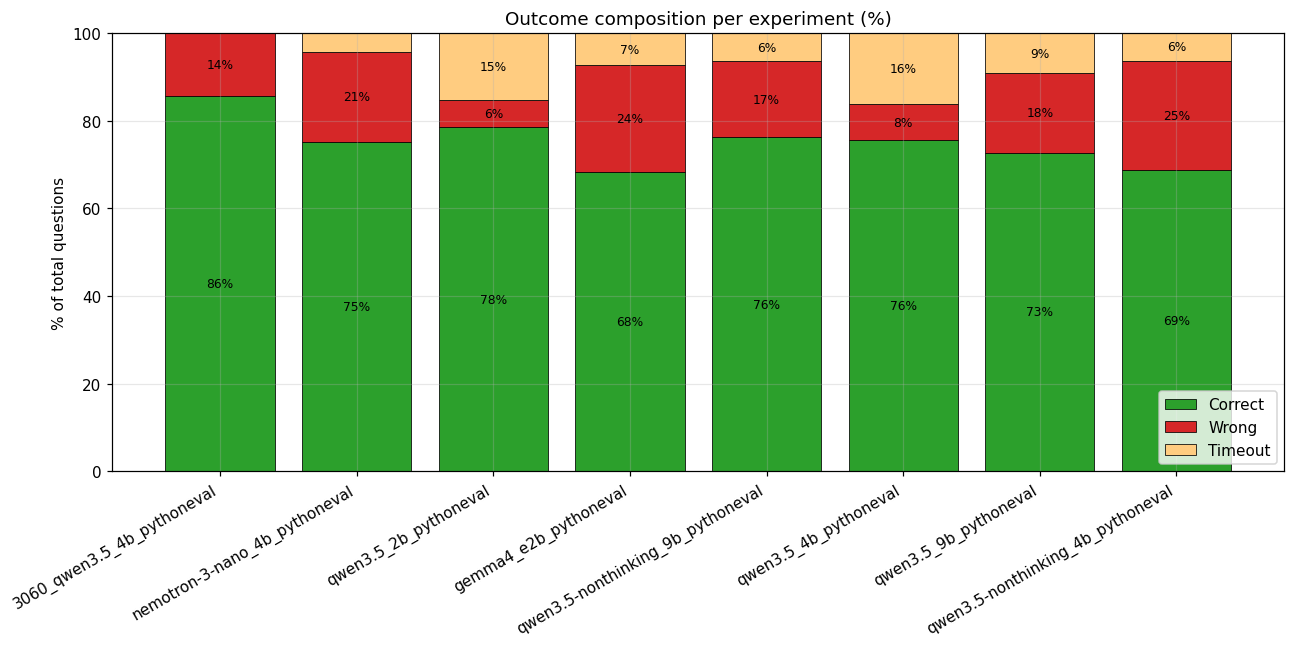

In [ ]:

# @title python_eval experiments
experiments = ["experiments-math/*_pythoneval.json"]
df = box_plot(experiments)
_ = outcomes_pct(experiments)

From these experiments we can see that:
1. Qwen models 2b and 4b, really suffer timeouts. We noticed that they often fall into some overthinking or reasoning loops.
2. If we had a ~20% faster inference (see `3060_` experiment on a RTX 3060), qwen3.5-4B would perform much better, with double the performance.
3. Non reasoning qwen variants, in spite of being faster, still have some performance drop, because they just get questions wrong. This shows that reasoning is very important for math tasks
4. Gemma, even with python helping for calculations, still performs bad in maths.


We also tried some more model with python_eval, however they performed poorly or not good enough to be mentioned and fully tested:

<details>
  <summary>More Models</summary>
  
  - Granite 4.1 3B and 8B: generally poor performance, specially in tool calling
  - Qwen 3.5 Next 9B: It is a fine tune of Qwen for math and programming tasks. Pretty good results with llama.cpp. However it did not run on ollama. We discarded as it would have had similar performances to Qwen 3.5 9B
  - Qwopus 3.5 4B: Finetune of Qwen with Opus reasoning. Tried hoping that it didn't have Qwen overthinking. Performed worse than base Qwen
  - rnj-8b: Many timeouts and bad at tool calling

</details>




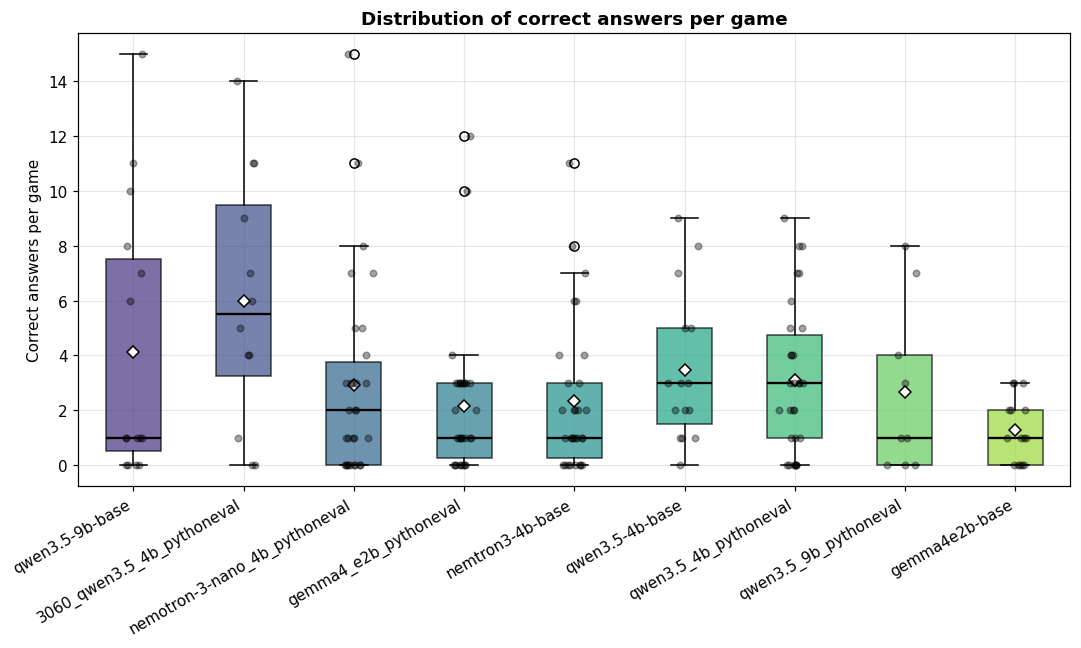

In [ ]:
# @title python_eval vs base models
experiments = ["experiments-math/nemtron3-4b-base.json", "experiments-math/nemotron-3-nano_4b_pythoneval.json",
               "experiments-math/qwen3.5-9b-base.json", "experiments-math/qwen3.5_9b_pythoneval.json",
               "experiments-math/qwen3.5-4b-base.json", "experiments-math/qwen3.5_4b_pythoneval.json",
               "experiments-math/gemma4_e2b_pythoneval.json", "experiments-math/gemma4e2b-base.json"]
df = box_plot(experiments)

Comparing base model against models with python_eval we notice:
1. Nemotron and Gemma gain performance from the python_eval tool
2. qwen3.5-4b has almost the same performance (withing the margin of error)
3. qwen3.5-9b is the only model losing performance. This is mostly because it is more affected by timeouts (having slower inference)

Since **inference speed was clearly the bottleneck**, we decided to use a new tool called `simple_calc`. That only handles arithmetic expressions. The model does not need to write verbose python code anymore.

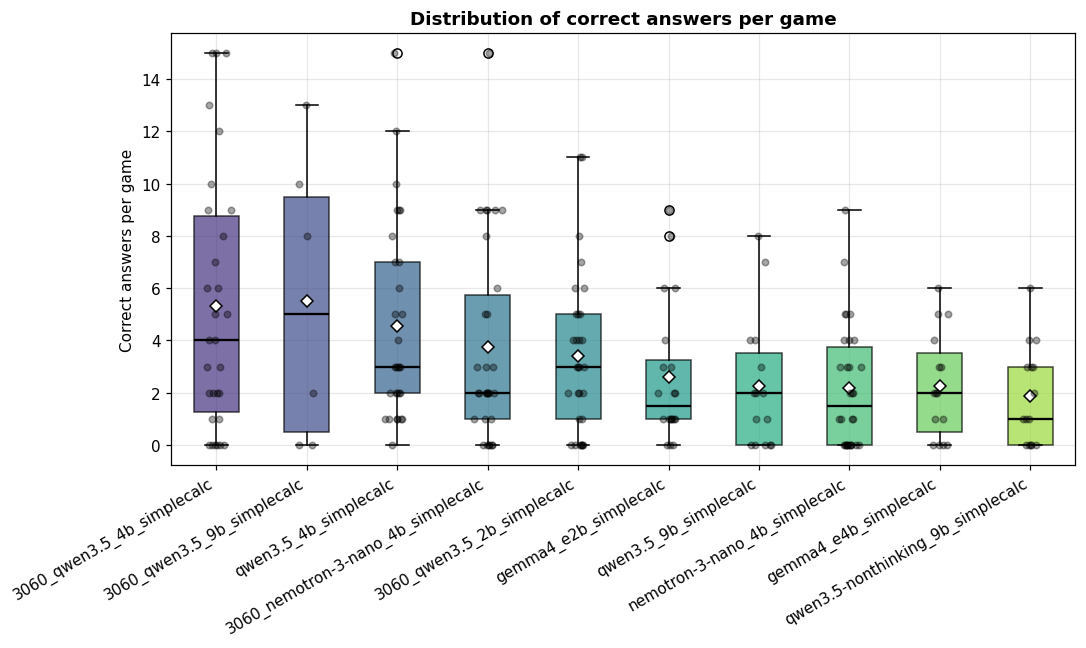

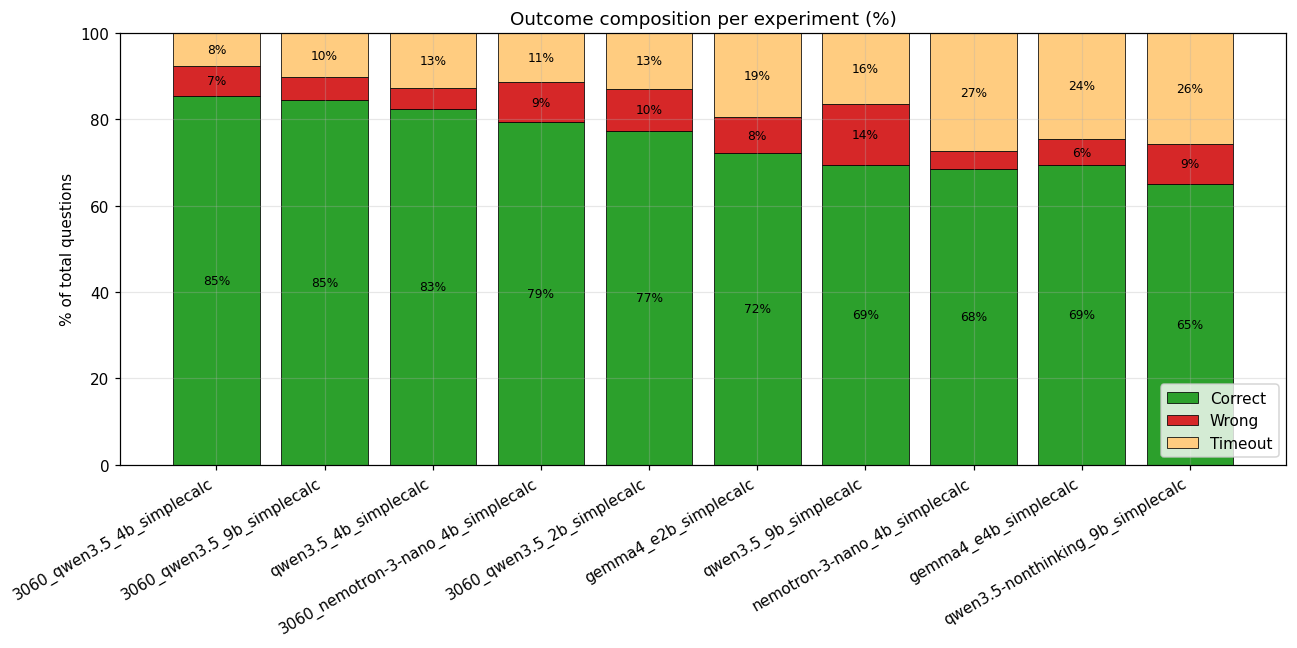

In [ ]:
experiments = ["experiments-math/*_simplecalc.json"]
df = box_plot(experiments)
_ = outcomes_pct(experiments)

The `simple_calc` tool made qwen3.5:4b performance much better, making it hit 1M. However, for other models that actually made it worse. Specially Gemma and Nemotron struggled by making a lot of simple_calc turns, causing them to timeout.

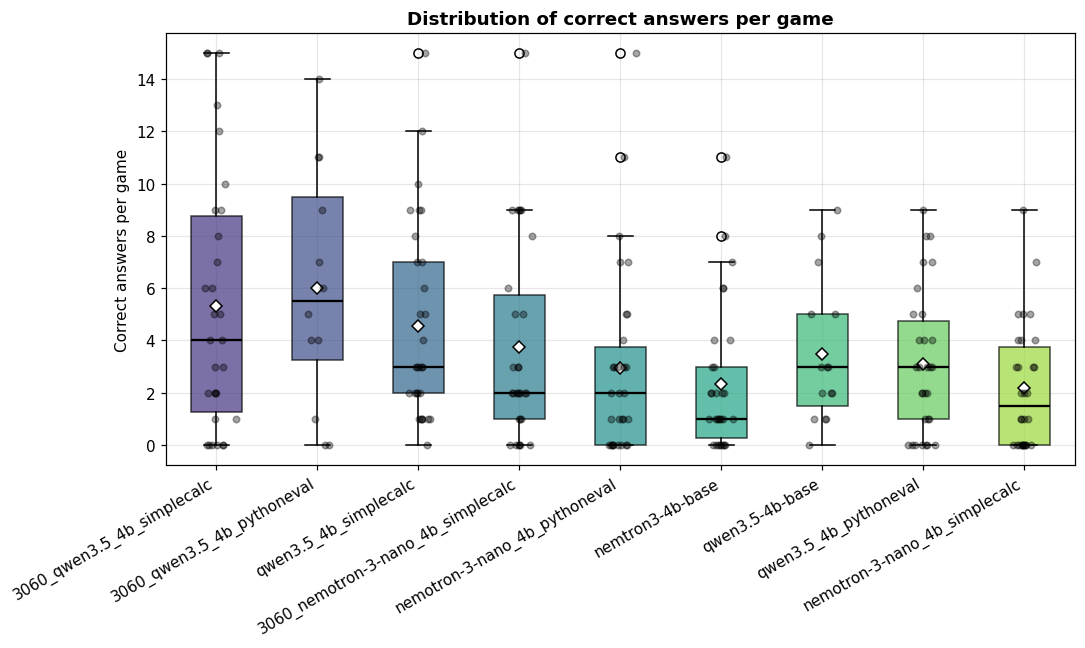

In [ ]:
experiments = ["experiments-math/nemtron3-4b-base.json", "experiments-math/nemotron-3-nano_4b_pythoneval.json", "experiments-math/nemotron-3-nano_4b_simplecalc.json",
               "experiments-math/qwen3.5-4b-base.json", "experiments-math/qwen3.5_4b_pythoneval.json","experiments-math/qwen3.5_4b_simplecalc.json"]
_ = box_plot(experiments)

### Alternative Math Architectures

#### Question Normalization

In order to make questions more understandable for the LLM in math
1. Use options A, B, C, D instead of 0, 1, 2, 3 to avoid answer confusion
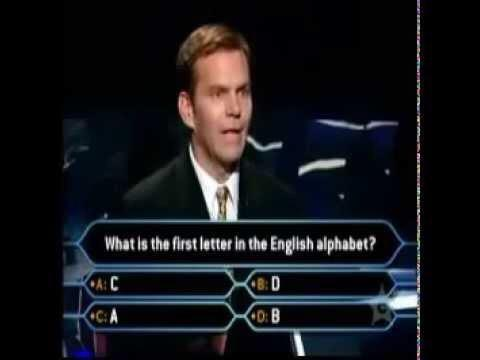
2. Convert mathematical expressions in options directly into numbers, for example

    - `3/4` => `3/4 ≈ 0.75`
    - `\frac{3}{4}` => `\frac{3}{4} ≈ 0.75`
    - `\frac{3}{4} \sqrt{2}` => `\frac{3}{4} \sqrt{2} ≈ 1.06066`

> This normalization is already applied to the experiments above

In [ ]:
# @title Estimate options numbers
# @title Estimate options numbers
import re
import math

def estimate_options(question: str) -> str:
    def evaluate_expr(expr_str):
        # Clean up LaTeX inline math wrappers if present
        s = expr_str.strip().replace('$', '')

        # 1. Convert LaTeX fractions: \frac{num}{den} -> (num) / (den)
        while True:
            new_s = re.sub(r'\\frac\{([^}]+)\}\{([^}]+)\}', r'( \1 ) / ( \2 )', s)
            if new_s == s:
                break
            s = new_s

        # 2. Convert LaTeX square roots: \sqrt{val} -> sqrt(val)
        while True:
            new_s = re.sub(r'\\sqrt\{([^}]+)\}', r'sqrt( \1 )', s)
            if new_s == s:
                break
            s = new_s

        # 3. Standardize math constants (pi, π)
        s = s.replace(r'\pi', ' pi ').replace('π', ' pi ')

        # 4. Handle implicit multiplication (e.g., '2e' -> '2 * e', '2pi' -> '2 * pi')
        # Digit followed by an identifier, bracket, or remaining backslash
        s = re.sub(r'(\d+)\s*([a-zA-Z\(\\])', r'\1 * \2', s)
        # Closing bracket followed by an identifier, digit, or bracket
        s = re.sub(r'\)\s*([a-zA-Z\d\(\\])', r') * \1', s)

        # 5. Drop any lingering LaTeX backslashes
        s = s.replace('\\', '')

        # 6. Explicitly route tokens to the safe math module
        s = re.sub(r'\bpi\b', 'math.pi', s)
        s = re.sub(r'\be\b', 'math.e', s)
        s = re.sub(r'\bsqrt\b', 'math.sqrt', s)

        try:
            # Safely evaluate using empty builtins and the math module
            val = eval(s, {"__builtins__": None}, {"math": math})
            if isinstance(val, (int, float)):
                return val
            return None
        except Exception:
            return None

    lines = question.split('\n')
    new_lines = []

    for line in lines:
        # Matches alphanumeric labels followed by a dot (e.g., '  0. ', 'A. ', '1. ')
        match = re.match(r'^(\s*[0-9a-zA-Z]+\.\s*)(.+)$', line)
        if match:
            prefix = match.group(1)
            option_text = match.group(2)
            val = evaluate_expr(option_text)

            if val is not None:
                # Format up to 5 decimal places and strip unnecessary trailing zeros
                val_str = f"{val:.5f}".rstrip('0').rstrip('.')
                val_str = val_str if val_str else "0"
                new_lines.append(f"{prefix}{option_text} ≈ {val_str}")
            else:
                new_lines.append(line)  # Leave untouched if it's purely a text option
        else:
            new_lines.append(line)

    return '\n'.join(new_lines)

In [ ]:
# @title Test question estimation

question = """Q: If the ratio of $2x-y$ to $x+y$ is 2 to 3, what is the ratio of $x$ to $y$? Express your answer as a common fraction.

  0. \\frac{4}{5}
  1. \\frac{5}{2}
  2. \\frac{5}{4}
  3. \\frac{2}{5}"""

print(estimate_options(question))

Q: If the ratio of $2x-y$ to $x+y$ is 2 to 3, what is the ratio of $x$ to $y$? Express your answer as a common fraction.

  0. \frac{4}{5} ≈ 0.8
  1. \frac{5}{2} ≈ 2.5
  2. \frac{5}{4} ≈ 1.25
  3. \frac{2}{5} ≈ 0.4


In [ ]:
# @title Math option estimation loop

def run_custom_math_option_estimation_loop(
    question: str,
    settings: dict,
    agent: str = "maths",
    max_iterations: int = 10,
    datasets: dict | None = None,
    verbose: bool = False,
    question_idx: str = "numbers",
) -> dict:
    question = estimate_options(question)
    result = run_agent_loop(
        question=question,
        settings=settings,
        agent=agent,
        max_iterations=max_iterations,
        datasets=datasets,
        verbose=verbose,
        question_idx=question_idx,
    )
    return result

In [ ]:
# @title Experiments: Math option estimation

for i in range(SETTINGS["polimillionaire"]["experiments"]):
  print(f"\n=== Starting Game {i} ===")
  game = client.game.start(competition_id=comp_id)
  print(f"Session ID: {game.session_id}")
  print(f"Total number of questions: {game.state.competition.max_levels}")
  print()
  play_game(game, architecture=run_custom_math_option_estimation_loop, question_idx="letters")


#### Question Categorization
The idea behind this architecture, is to remove any doubt about the question type, and avoid the use of tools in theory question. In this way, the prompt given to the answering LLM is more simple and specific.
1. Use and LLM to classify Theory or Computation question
2. Route to the specialized agent

In practice, we perform **categorization using another LLM**, Qwen3.5:0.8b without thinking. The accuracy is pretty good, and it takes ~2s to categorize the question.
Clearly, a much **smarter approach would be to train a simple Naive-Bayes linear classifier** using questions embeddings. However, creating a dataset without using the actual questions from polimillionaire would have required us too much time. Therefore we opted for the LLM route.

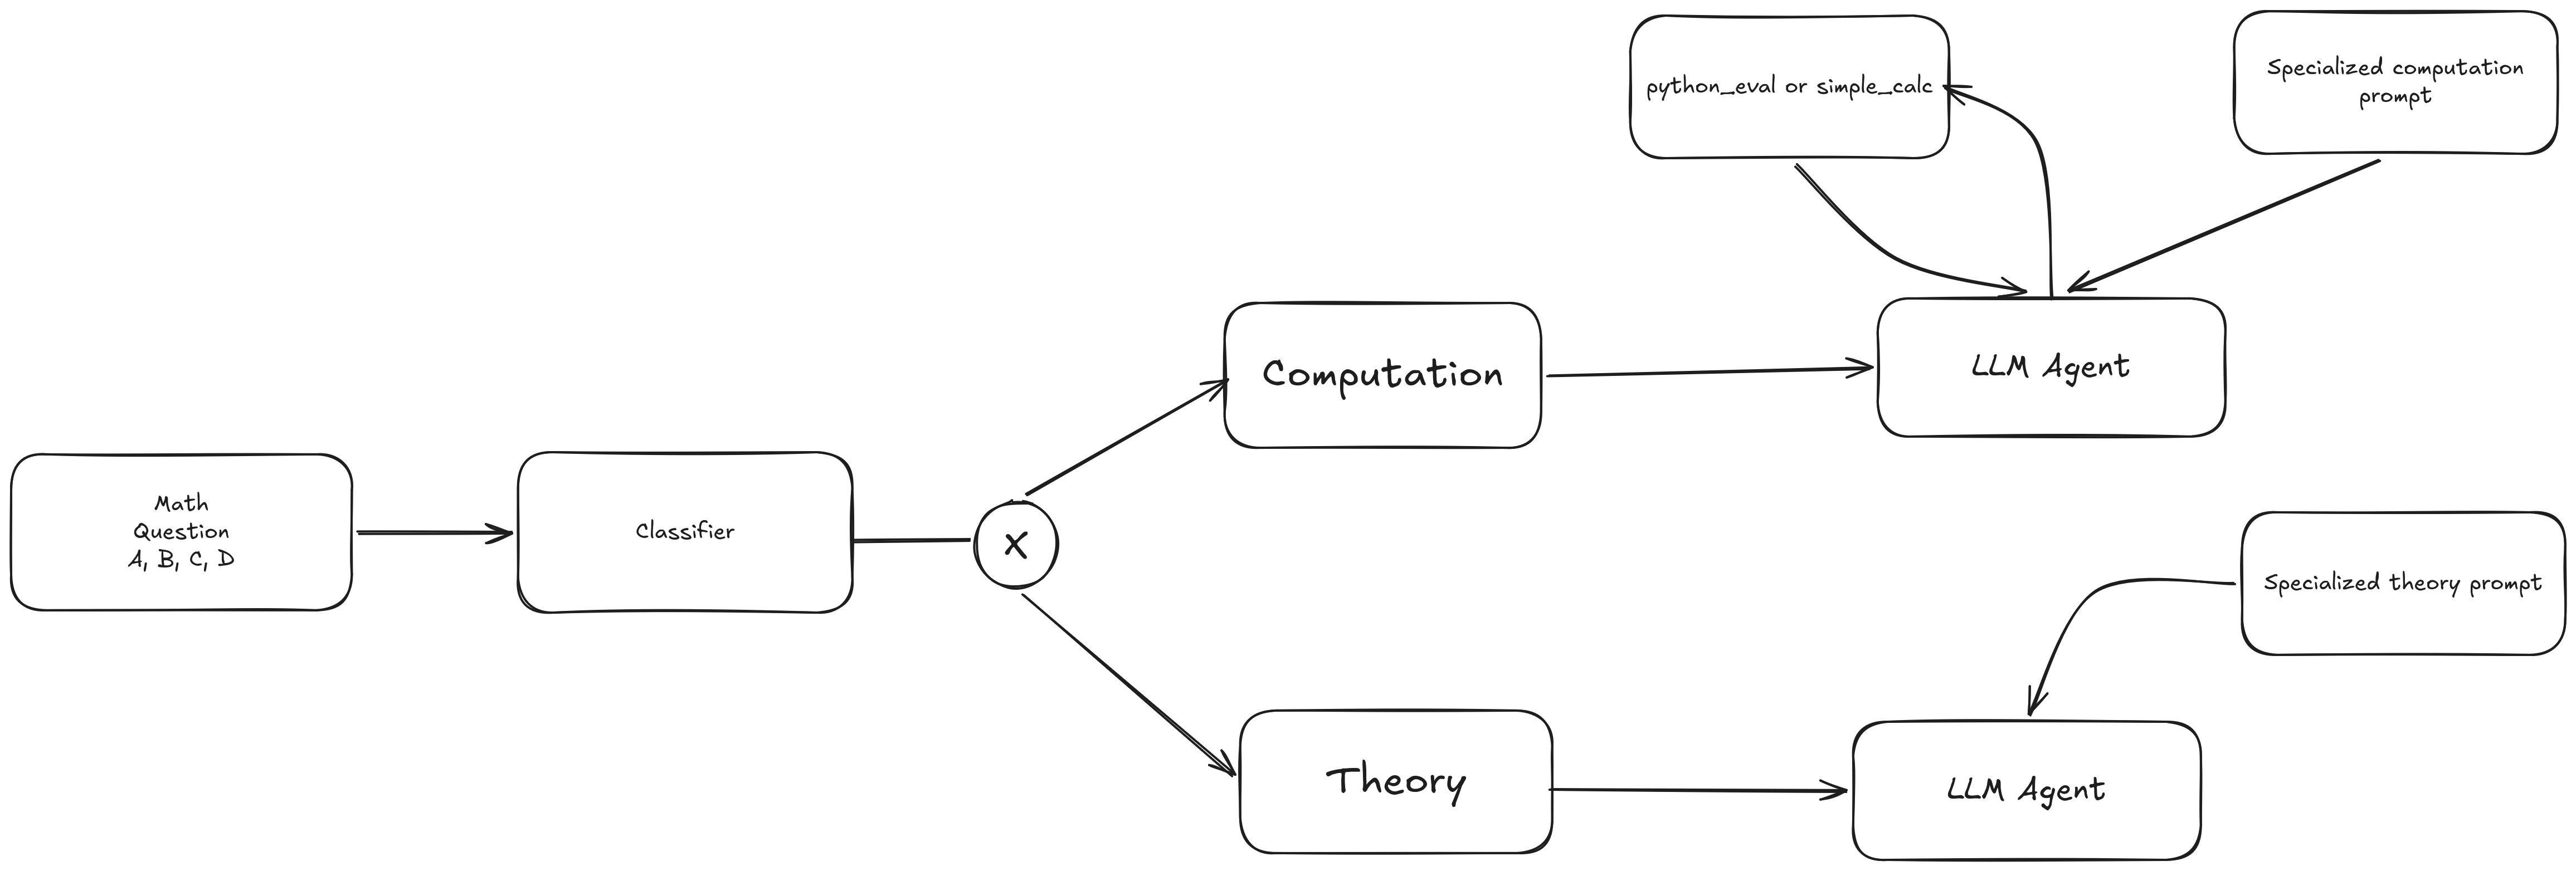

In [ ]:
# @title Architecture settings

# New Agents

SETTINGS["agents"].update(
    {
        "maths": {
            "prompt": "maths_pycalc",
            "tools": {
                "python_eval": True,
            },
            "rag": {
                "enabled": False,
            },
            "few_shots": [
                [
                    {"role": "human", "content": "Q: What is the magnitude of the vector v = (3, 4)?\n  0. 5\n  1. 7\n  2. 3\n  3. 12"},
                    {"role": "ai", "tool_calls": [{"id": "fs1", "name": "python_eval", "args": {"python_script": "import math\nprint(math.sqrt(3**2 + 4**2))"}}]},
                    {"role": "tool", "tool_call_id": "fs1", "content": "5.0"},
                    {"role": "ai", "tool_calls": [{"id": "fs2", "name": "answer_question", "args": {"answer": 0, "explanation": "Calculated using the Pythagorean theorem"}}]},
                    {"role": "tool", "tool_call_id": "fs2", "content": '{"status": "submitted", "answer": 0}'},
                ],
            ],
        },
        "maths_notools": {
            "prompt": "maths_notools",
            "tools": {
                "python_eval": False,
            },
            "rag": {
                "enabled": False,
            },
            "few_shots": [
                [
                    {"role": "human", "content": "Q: What is the magnitude of the vector v = (3, 4)?\n  0. 5\n  1. 7\n  2. 3\n  3. 12"},
                    {"role": "ai", "tool_calls": [{"id": "fs2", "name": "answer_question", "args": {"answer": 0, "explanation": "Calculated using the Pythagorean theorem"}}]},
                    {"role": "tool", "tool_call_id": "fs2", "content": '{"status": "submitted", "answer": 0}'},
                ],
            ],
        }
    }
)

# New Prompts
SETTINGS["prompts"].update(
    {
        # Math Classification prompt - Very simple as it must be used by a 0.8B non-thinking model
        "math_classify": """Classify the math problem as "Theory" or "Calculation".

Calculation: numbers are given and a number must be computed.
Theory: no computation needed, just recall a definition or property.

Use the `classify_problem` tool:
- `category`: "Theory" or "Calculation"
- `explanation`: under 10 words

Examples:
  "What is the magnitude of (5, 0, 7)?" → Calculation
  "What is the IQR given mean=640k, std=18k?" → Calculation
  "What does IQR measure?" → Theory""",
        # Math Pycalc prompt - Instructions of how to use python_eval to solve math problems
        "maths_pycalc": """You are a math solver and expert python programmer. Follow these steps exactly:

STEP 1 — COMPUTE
Run one `python_eval` call to solve the problem.
Available: math, np, sympy, statistics, cmath, random
Always print() the final result and any important intermediate values.

STEP 2 — MATCH
Compare the computed result to the 4 options (labeled 0, 1, 2, 3).
Pick the index of the matching option.

STEP 3 — ANSWER
Call `answer_question` with:
  option: <index 0–3>
  explanation: <5 words max, e.g. "Used sympy to factor polynomial">

RULES:
- Never skip python_eval. No mental math.
- One python_eval call only.
- explanation must be ≤10 words.
""",
        # Math Notools - Instructions about how to solve theory questions
        "maths_notools": """You are a theory question solver. Follow these steps exactly:

STEP 1 — REASON
Think through the question carefully.
Identify key concepts, eliminate wrong options, and determine the correct answer.

STEP 2 — MATCH
Compare your reasoning to the 4 options (labeled 0, 1, 2, 3).
Pick the index of the best answer.

STEP 3 — ANSWER
Call `answer_question` with:
  option: <index 0–3>
  explanation: <10 words max, e.g. "Mitosis produces identical daughter cells via nuclear division">

RULES:
- Always call answer_question. Never just state the answer in text.
- explanation must be ≤10 words and state the core reason.
        """,
    }
)

In [ ]:
# @title Classify Math question
class ClassifyProblemInput(BaseModel):
    category: str = Field(
        ...,
        description="Either 'Theory' or 'Calculation'.",
    )
    explanation: str = Field(
        default="",
        description="Brief reason for the classification (under 10 words).",
    )

def _classify_math_question(question: str, settings: dict, verbose: bool = False, classification_model="qwen3.5:0.8b") -> dict:
    """Use the math_classify prompt + classify_problem tool to decide Theory vs Calculation."""
    classify_result: dict = {}

    @tool("classify_problem", args_schema=ClassifyProblemInput)
    def classify_problem(category: str, explanation: str) -> str:
        """Classify a math problem as Theory or Calculation."""
        classify_result["category"] = category.strip().lower()
        classify_result["explanation"] = explanation
        return json.dumps({"status": "classified", "category": category})
    classification_settings = copy.deepcopy(settings)
    classification_settings["llm"]["model"] = classification_model
    classification_settings["llm"]["extra_body"] = {"reasoning_effort": "none"}
    classify_llm = build_llm(classification_settings)
    classify_prompt = settings["prompts"]["math_classify"]
    classify_messages = [
        SystemMessage(content=classify_prompt),
        HumanMessage(content=question),
    ]
    classify_llm_with_tools = classify_llm.bind_tools([classify_problem])

    for _ in range(3):
        response = classify_llm_with_tools.invoke(classify_messages)

        if response.tool_calls:
            for tc in response.tool_calls:
                if tc["name"] == "classify_problem":
                    classify_problem.invoke(tc["args"])
                    break
            if classify_result:
                break
        else:
            text_tc = _extract_text_tool_call(
                response.content or "", ["classify_problem"],
            )
            if text_tc:
                classify_problem.invoke(text_tc[1])
                if classify_result:
                    break
            text_lower = (response.content or "").lower()
            if "theory" in text_lower and "calculation" not in text_lower:
                classify_result["category"] = "theory"
                classify_result["explanation"] = response.content
                break
            elif "calculation" in text_lower:
                classify_result["category"] = "calculation"
                classify_result["explanation"] = response.content
                break

    return classify_result

In [ ]:
# @title Math Categorization Agent loop

def run_custom_math_categorization_loop(
    question: str,
    settings: dict,
    agent: str = "maths",
    max_iterations: int = 10,
    datasets: dict | None = None,
    verbose: bool = False,
    question_idx: str = "numbers",
) -> dict:
    """Classify a math question as Theory or Calculation, then route to the right agent.

    Step 1 – uses the ``math_classify`` prompt and a ``classify_problem`` tool to
    decide whether the problem is *theory* (no computation needed) or *calculation*
    (requires arithmetic / algebra / numerical work).

    Step 2 – delegates to :func:`run_agent_loop` with the appropriate agent:
      * Theory       → ``maths_notools``
      * Calculation  → ``maths``

    Returns:
        Same dict as ``run_agent_loop``, plus ``classification``, ``classify_explanation``,
        and ``classified_agent`` keys.
    """
    t0 = _time.perf_counter()

    classification_model = settings["llm"]["classification_model"]
    classify_result = _classify_math_question(question, settings, verbose, classification_model = classification_model)
    category = classify_result.get("category", "calculation")
    if verbose:
        print(f"  [classify] {category} — {classify_result.get('explanation', '')[:80]}")

    target_agent = "maths_notools" if category == "theory" else "maths"
    print(f"Routing to agent: {target_agent} (category: {category})")
    # Question estimation
    question = estimate_options(question)
    result = run_agent_loop(
        question=question,
        settings=settings,
        agent=target_agent,
        max_iterations=max_iterations,
        datasets=datasets,
        verbose=verbose,
        question_idx=question_idx,
    )

    result["classification"] = category
    result["classify_explanation"] = classify_result.get("explanation", "")
    result["classified_agent"] = target_agent
    result["answer_time"] = _time.perf_counter() - t0

    return result

In [ ]:
# Load and download qwen3.5:0.8b

if False:
    r = requests.post(f"http://localhost:11434/api/pull", json = {"model": "qwen3.5:0.8b"})
    !ollama run qwen3.5:0.8b "Hello"
    !ollama run {SETTINGS["llm"]["model"]} "Hello"

In [ ]:
# @title Math Question Categorization Game Experiments

SETTINGS["llm"]["classification_model"] = "qwen3.5:0.8b" # Assumes model already downloaded and loaded

for i in range(SETTINGS["polimillionaire"]["experiments"]):
  print("\n=== Starting Game ===")
  game = client.game.start(competition_id=comp_id)
  print(f"Session ID: {game.session_id}")
  print(f"Total number of questions: {game.state.competition.max_levels}")
  print()
  play_game(game, architecture=run_custom_math_categorization_loop, question_idx="letters")


##### Math Question Categorization results

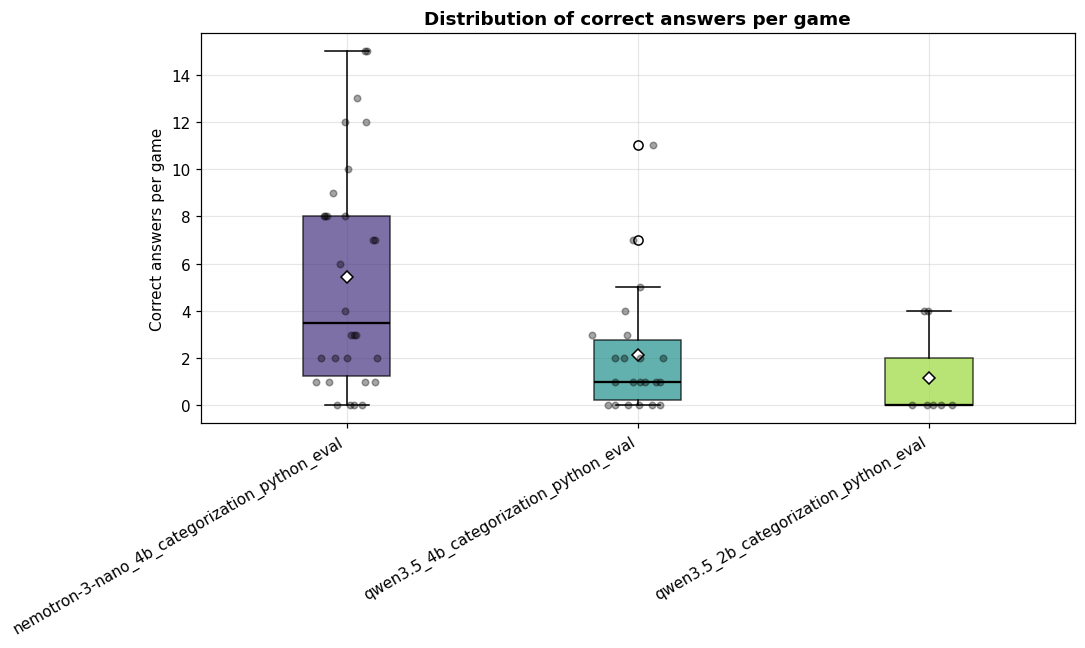

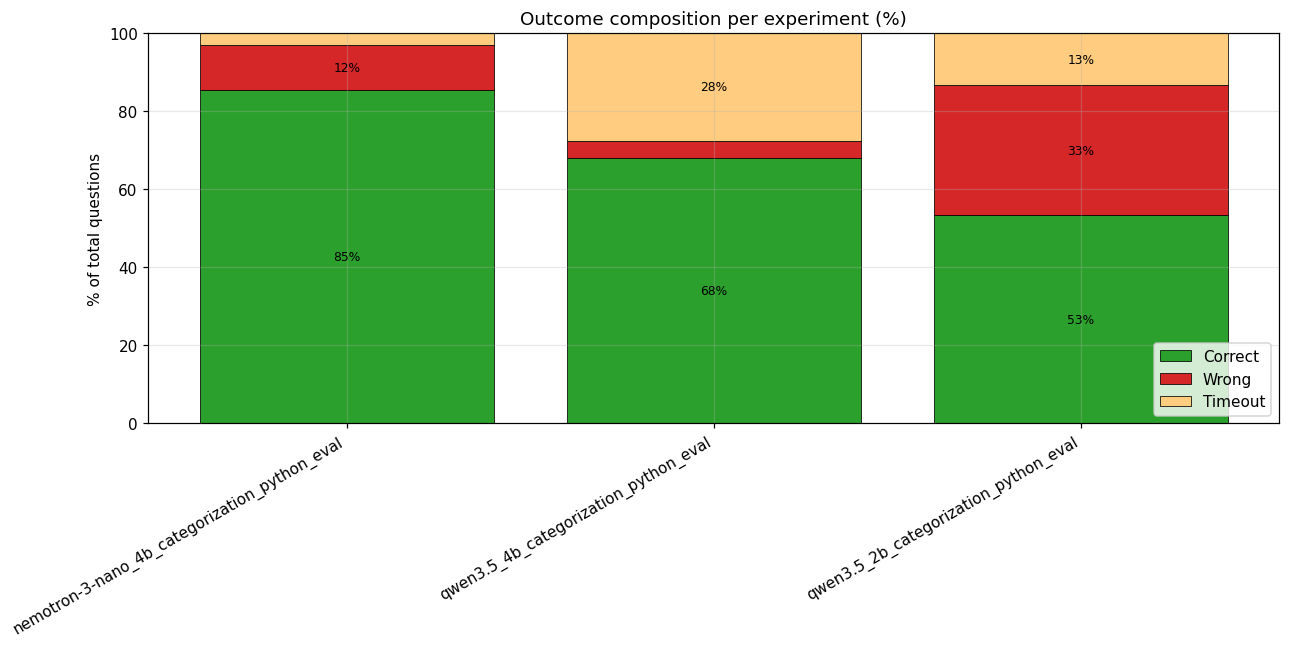

In [ ]:
experiments = ["experiments-math/*b_categorization*"]
_ = box_plot(experiments)
_ = outcomes_pct(experiments)

**Nemotron strongly benefited this architecture**, reaching performance unseen in other architectures.
On the other hand, Qwen models actually got worse.
`Qwen3.5-4B` actually got big timeouts (many more than 50s), and, even via manual inspection the reason is not very clear.

#### Answer-Then-Verify
The idea behind this architecture is to make the agent come up with a definitive answer, and if the model answer is not the same one of the calculator, continue the agent loop. Otherwise commit the answer.

1. Try to answer using answer_question
2. Make the calculation using a calculator to verify the result
3. Check if the answers are the same
    - If they are the same, answer
    - If not, continue the agent loop

In [ ]:
# @title Answer-Then-Verify agent
SETTINGS["agents"].update( {
    "math_eager": {
        "prompt": "math_eager",
        "tools": {
            "python_eval": False,
            "simple_calc": True
        },
        "rag": {
            "enabled": False,
        },
    }
})


SETTINGS["prompts"]["math_eager"] = """
You are a fast, precise math solver. You answer 4-option multiple-choice
questions and you optimize for SPEED. The clock matters more than perfection.

WORKFLOW - exactly one or two turns:

TURN 1 (mandatory). Your first response MUST call `answer_question` with your
best guess based on prior knowledge. In the SAME response, you MAY also call
`simple_calc` to verify your guess. Both tool calls go in one response.

  - Use `answer_question` for your committed answer (A-D) and a short reason.
  - Use `simple_calc` (in the same response) only if the question involves
    arithmetic, exponents, roots, trig, or logs that you want to verify.
  - For pure theory or definitional questions: only call `answer_question`,
    skip `simple_calc`.

TURN 2 (only if simple_calc disagreed). If the calculator output contradicts
the answer you submitted in turn 1, you get one chance to correct. Call
`answer_question` again with the corrected option.

RULES:
- The first response must contain an `answer_question` call. ALWAYS.
- Never write a "plan" before calling tools. Just call them.
- `simple_calc` accepts ONE arithmetic expression. Allowed: numbers; operators
  `+ - * / // % **`; parentheses; functions `sqrt, abs, log, exp, sin, cos,
  tan, floor, ceil`; constants `pi, e`. No variables, no `solve`, no `=`.
- Keep `explanation` under 10 words. Examples: "Pythagorean theorem",
  "Standard derivative", "By definition", "GUESSED".
- If you have no idea, pick the most plausible option and start the
  explanation with "GUESSED".
  """

In [ ]:
# @title Custom agent loop

# Verify calculation
def _calc_agrees_with_answer(
    calc_output: str,
    answer_idx: int,
    options_text: str,
) -> bool | None:
    """Best-effort check: does simple_calc's output match the chosen option?

    Returns True when the calculator's numeric output matches the chosen option,
    False when it matches a *different* option (clear disagreement), and None
    when we cannot decide (non-numeric option text, calculator error, calc value
    not present among the options, etc.).
    """
    m = _re.search(r"-?\d+\.?\d*", calc_output or "")
    if not m:
        return None
    try:
        calc_value = float(m.group(0))
    except ValueError:
        return None

    option_values: dict[int, float] = {}
    for line in options_text.splitlines():
        om = _re.match(r"\s*([A-Da-d])\.\s*(.+)", line)
        if not om:
            continue
        idx = letter_to_idx(om.group(1))
        nm = _re.search(r"-?\d+\.?\d*", om.group(2).strip())
        if nm:
            try:
                option_values[idx] = float(nm.group(0))
            except ValueError:
                pass

    if answer_idx not in option_values:
        return None

    chosen = option_values[answer_idx]
    tol = max(0.01, abs(chosen) * 0.01)
    if abs(calc_value - chosen) <= tol:
        return True
    for idx, val in option_values.items():
        if idx == answer_idx:
            continue
        if abs(calc_value - val) <= max(0.01, abs(val) * 0.01):
            return False
    return None


def run_agent_loop_eager(
    question: str,
    settings: dict,
    agent: str = "math",
    max_iterations: int = 10,
    datasets: dict | None = None,
    verbose: bool = False,
    check_tool: str = "simple_calc",
    question_idx: str = "numbers",
) -> dict:
    """Run a tool-calling agent loop to answer a 4-option multiple-choice question.

    Resolves the named agent's LLM, tools, RAG index, and prompt from SETTINGS,
    then runs the loop until ``answer_question`` is called or max_iterations hit.

    Args:
        question:       Full question text including the four options.
        settings:       The SETTINGS dict.
        agent:          Name of the agent to use (key in SETTINGS['agents']).
        max_iterations: Safety cap on the number of LLM calls.
        datasets:       Dataset dict (used to build RAG index on first call if needed).
        verbose:        If True, stream agent thinking, tool calls, and tool outputs
                        with formatted Markdown display.

    Returns:
        {
            "answer":      int | None,
            "explanation": str | None,
            "rag_context": list[dict],
            "messages":    list,
        }
    """
    # Question estimation
    question = estimate_options(question)
    t0 = _time.perf_counter()
    _per_turn_times: list[float] = []

    ds = datasets if datasets is not None else globals().get("datasets", {})
    runtime = get_agent_runtime(agent, settings, ds)
    output_mode = runtime["output_mode"]

    # 1. RAG context retrieval
    rag_context: list[dict] = []
    if runtime["rag_enabled"] and runtime["rag_index"] is not None:
        rag_context = runtime["rag_index"].search(
            question, topk=runtime["topk"]
        )

    # 2. Build answer tool(s) based on output_mode
    _final: dict = {}
    if question_idx == "numbers":
      schemas = [AnswerQuestionInput, AnswerOnlyInput]
    elif question_idx == "letters":
      schemas = [AnswerQuestionInputLetter, AnswerOnlyInputLetter]
    if output_mode == "tool":
        @tool("answer_question", args_schema=schemas[0])
        def answer_question(answer: int, explanation: str) -> str:
            """Submit your final answer to the multiple-choice question.
            Call this exactly once when you are confident in your choice."""
            _final["answer"] = answer
            _final["explanation"] = explanation
            return json.dumps({"status": "submitted", "answer": answer})
        answer_tool = answer_question

    elif output_mode == "tool_no_explanation":
        @tool("answer_question", args_schema=schemas[1])
        def answer_question(answer: int) -> str:
            """Submit your final answer to the multiple-choice question.
            Call this exactly once when you are confident in your choice."""
            _final["answer"] = answer
            _final["explanation"] = ""
            return json.dumps({"status": "submitted", "answer": answer})
        answer_tool = answer_question
    else:
        answer_tool = None

    if answer_tool is not None:
        all_tools = list(runtime["tools"]) + [answer_tool]
    else:
        all_tools = list(runtime["tools"])
    tool_map = {t.name: t for t in all_tools}

    # 3. Assemble chat history with RAG context
    context_block = ""
    user_message = ""
    if rag_context:
        lines = ["\n## Retrieved context\n"]
        for i, hit in enumerate(rag_context, 1):
            lines.append(
                f"### [{i}] {hit['title']}  (similarity: {hit['similarity']}%)\n"
                f"Source: {hit['url']}\n\n"
                f"{hit['text']}\n"
            )
        context_block = "\n".join(lines)
        user_message = "<context>" + context_block + "</context>\n\n"
    user_message += question

    prompt_key = runtime["prompt_key"]
    system_prompt = settings["prompts"][prompt_key]
    messages = [SystemMessage(content=system_prompt)]

    # Inject few-shot examples from config
    messages.extend(_parse_few_shot_messages(runtime["few_shots"]))

    messages.append(HumanMessage(content=user_message))

    # 4. Agent loop
    if all_tools:
        llm_with_tools = runtime["llm"].bind_tools(all_tools)
    else:
        llm_with_tools = runtime["llm"]

    for iteration in range(max_iterations):
        if verbose:
            from IPython.display import display, Markdown
            display(Markdown(f"---\n**Iteration {iteration + 1}**"))

        iteration_calc_output: str | None = None
        _turn_start = _time.perf_counter()

        if verbose:
            text_chunks = []
            reasoning_chunks = []
            tool_calls_accum = {}

            _bound_llm = getattr(llm_with_tools, 'bound', llm_with_tools)
            _tools_kwarg = getattr(llm_with_tools, 'kwargs', {}).get("tools")
            _raw_client = _bound_llm.client
            _stream_params = {
                "model": _bound_llm.model_name,
                "messages": _lc_messages_to_openai(messages),
                "stream": True,
            }
            if _tools_kwarg:
                _stream_params["tools"] = _tools_kwarg

            for raw_chunk in _raw_client.create(**_stream_params):
                if not raw_chunk.choices:
                    continue
                delta = raw_chunk.choices[0].delta

                if delta.content:
                    text_chunks.append(delta.content)

                rc = getattr(delta, 'reasoning', None) or getattr(delta, 'reasoning_content', None)
                if rc:
                    reasoning_chunks.append(rc)

                if delta.tool_calls:
                    for tc in delta.tool_calls:
                        idx = tc.index
                        if idx not in tool_calls_accum:
                            tool_calls_accum[idx] = {"id": "", "name": "", "args": ""}
                        if tc.id:
                            tool_calls_accum[idx]["id"] += tc.id
                        if tc.function:
                            if tc.function.name:
                                tool_calls_accum[idx]["name"] += tc.function.name
                            if tc.function.arguments:
                                tool_calls_accum[idx]["args"] += tc.function.arguments

            full_reasoning = "".join(reasoning_chunks).strip()
            if full_reasoning:
                _verbose_print("reasoning", full_reasoning)

            full_text = "".join(text_chunks).strip()
            if full_text:
                _verbose_print("thinking", full_text)

            parsed_tool_calls = []
            for idx in sorted(tool_calls_accum.keys()):
                tc_data = tool_calls_accum[idx]
                try:
                    args_parsed = json.loads(tc_data["args"]) if tc_data["args"] else {}
                except json.JSONDecodeError:
                    args_parsed = {}
                parsed_tool_calls.append({
                    "id": tc_data["id"],
                    "name": tc_data["name"],
                    "args": args_parsed,
                })

            _tc = parsed_tool_calls if parsed_tool_calls else []
            _ak = {"reasoning_content": full_reasoning} if full_reasoning else {}
            try:
                response = AIMessage(
                    content=full_text,
                    tool_calls=_tc,
                    additional_kwargs=_ak,
                )
            except Exception as _aim_err:
                print(f"Warning: AIMessage construction failed ({_aim_err}). Using plain text response.")
                if full_text:
                    _verbose_print("text", full_text)
                response = AIMessage(content=full_text, tool_calls=[], additional_kwargs=_ak)
        else:
            response = llm_with_tools.invoke(messages)

        _per_turn_times.append(round(_time.perf_counter() - _turn_start, 3))
        messages.append(response)
        messages[-1].additional_kwargs["__elapsed__"] = _time.perf_counter() - t0

        if verbose and isinstance(response, AIMessage):
            resp_reasoning = _extract_reasoning(response)
            if resp_reasoning and not full_reasoning:
                _verbose_print("reasoning", resp_reasoning)

        # No tool calls → check for text-embedded tool call, then final response
        if not response.tool_calls:
            _text_tc = _extract_text_tool_call(
                response.content or "", list(tool_map.keys()),
            )
            if _text_tc is not None:
                _tc_name, _tc_args = _text_tc
                if verbose:
                    _verbose_print("tool_call", json.dumps(_tc_args, indent=2), tool_name=_tc_name)
                    print(f"  [text-tool-call] Recovered {_tc_name} from plain text")
                else:
                    print(f"  [text-tool-call] {_tc_name}({_tc_args})")
                fn = tool_map.get(_tc_name)
                if fn:
                    result = fn.invoke(_tc_args)
                    messages.append(ToolMessage(
                        content=str(result),
                        tool_call_id=f"txt_{_time.perf_counter_ns()}",
                    ))
                    messages[-1].additional_kwargs["__elapsed__"] = _time.perf_counter() - t0
                if _final:
                    break
                continue

            # JSON mode: parse answer from response text
            if output_mode == "json" and not _final:
                parsed = _parse_json_answer(response.content or "")
                if parsed is not None:
                    _final["answer"] = parsed
                    _final["explanation"] = None
            break

        for tc in response.tool_calls:
            fn = tool_map.get(tc["name"])
            result = fn.invoke(tc["args"]) if fn else f"Unknown tool: {tc['name']}"

            if tc["name"] == check_tool:
                iteration_calc_output = str(result)

            if verbose:
                _verbose_print("tool_call", json.dumps(tc["args"], indent=2), tool_name=tc["name"])
                _verbose_print("tool_output", str(result)[:3000], tool_name=tc["name"])
            else:
                print(tc["name"], tc["args"])

            messages.append(ToolMessage(content=str(result), tool_call_id=tc["id"]))
            messages[-1].additional_kwargs["__elapsed__"] = _time.perf_counter() - t0

        # --- Architecture A (eager commit) short-circuit ---
        # On turn 1, if `answer_question` already fired, exit immediately unless
        # `simple_calc` ran AND its output points at a *different* option.
        if _final and iteration == 0:
            if iteration_calc_output is None:
                break  # eager answer, no verification requested
            agreement = _calc_agrees_with_answer(
                iteration_calc_output, _final["answer"], question,
            )
            if agreement is True or agreement is None:
                break  # confirmed, or inconclusive -> accept (chosen: eager)
            # agreement is False -> fall through; next iteration is correction

        # Turn-2 guard: never spend more than two LLM generations.
        if iteration >= 1 and _final:
            break

        if _final:
            break

    elapsed = _time.perf_counter() - t0
    tools_used = [
        tc["name"]
        for m in messages
        if getattr(m, "tool_calls", None)
        for tc in m.tool_calls
    ]

    architecture = (
        settings.get("agents", {}).get(agent, {}).get("architecture", "deliberative")
    )
    if question_idx == "letters":
          _final["answer"] = letter_to_idx(_final.get("answer"))
    return {
        "answer": _final.get("answer"),
        "explanation": _final.get("explanation"),
        "rag_context": rag_context,
        "messages": messages,
        "answer_time": elapsed,
        "tools_used": tools_used,
        "per_turn_times": _per_turn_times,
        "architecture": architecture,
    }

In [ ]:
# @title Math Answer-Then-Verify experiments
SETTINGS["competition_to_agent"][3] = "math_eager"

for i in range(SETTINGS["polimillionaire"]["experiments"]):
  print(f"\n=== Starting Game {i} ===")
  game = client.game.start(competition_id=comp_id)
  print(f"Session ID: {game.session_id}")
  print(f"Total number of questions: {game.state.competition.max_levels}")
  print()
  play_game(game,  architecture=run_agent_loop_eager, question_idx="letters")

##### Math Answer-Than-Verify results

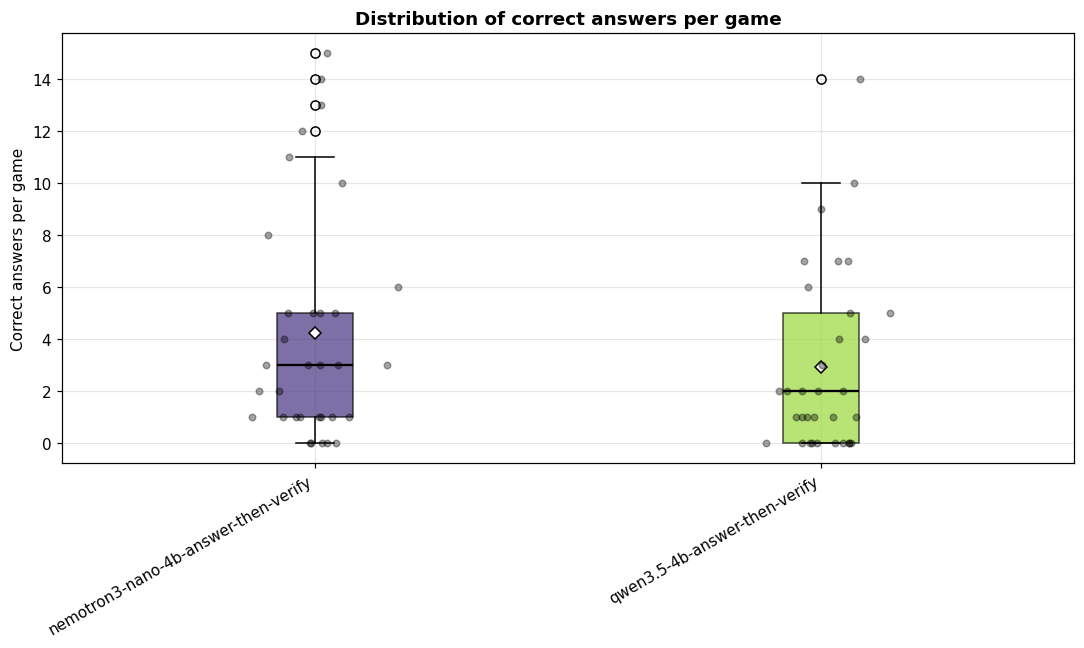

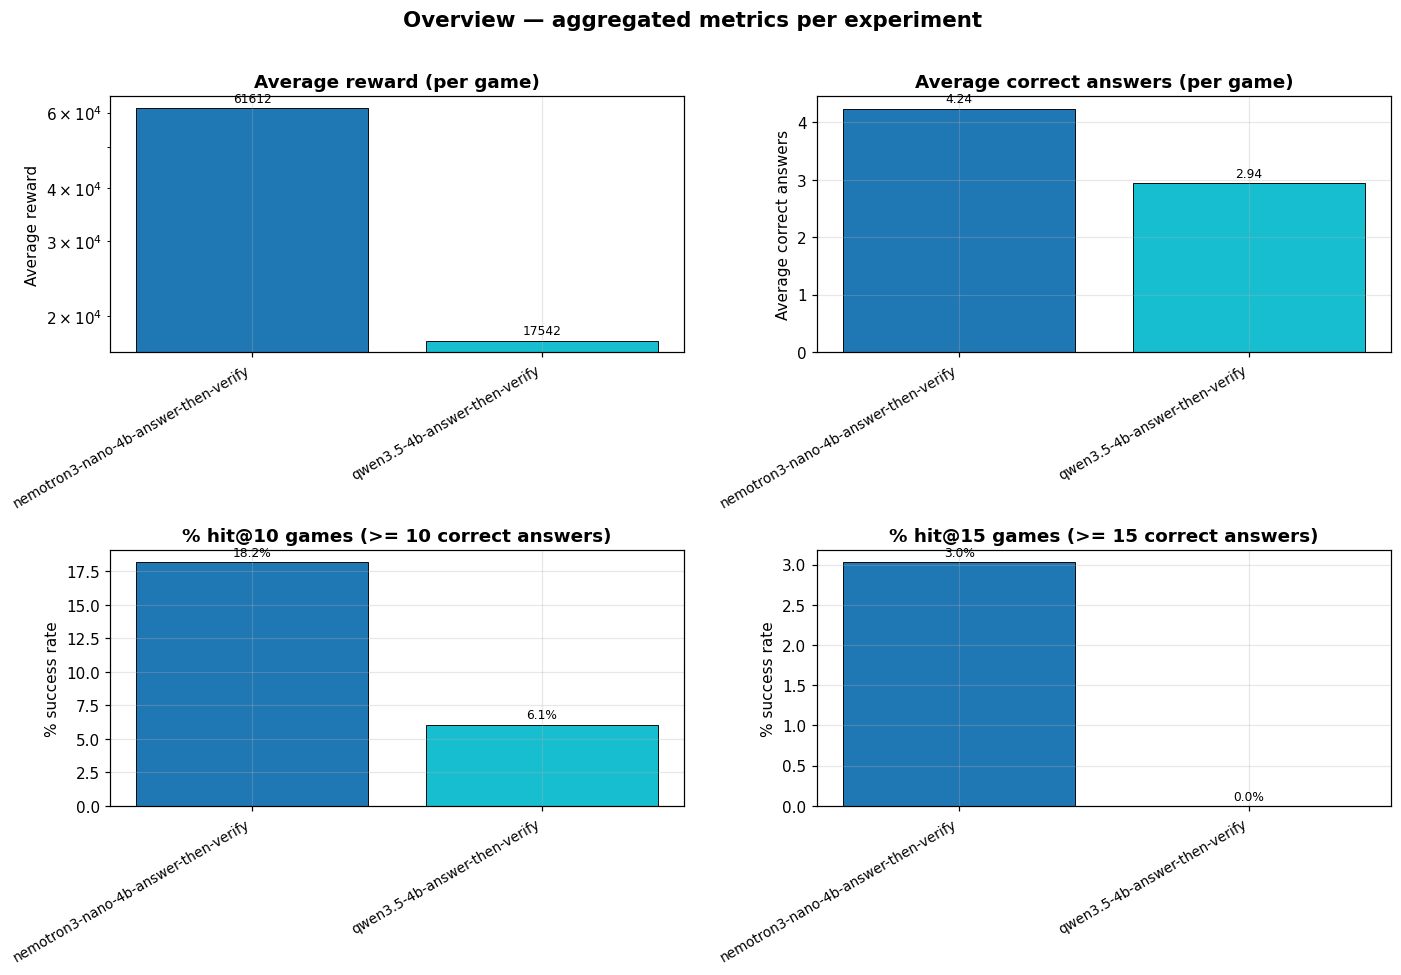

In [ ]:
_ = box_plot(["experiments-math/*answer-then*"])
_ = overview(["experiments-math/*answer-then*"])

Also in this architecture we notice that Nemotron actually results in better performance compared to qwen.

#### Hybrid Categorization + Answer-Then-Verify
This is an hybrid architecture joining the two architectures above.

In [ ]:
# @title Hybrid agent loop

def run_custom_math_categorization_loop_eager(
    question: str,
    settings: dict,
    agent: str = "maths",
    max_iterations: int = 10,
    datasets: dict | None = None,
    verbose: bool = False,
    question_idx: str = "numbers",
) -> dict:
    """Classify a math question as Theory or Calculation, then route to the right agent.

    Step 1 – uses the ``math_classify`` prompt and a ``classify_problem`` tool to
    decide whether the problem is *theory* (no computation needed) or *calculation*
    (requires arithmetic / algebra / numerical work).

    Step 2 – delegates to :func:`run_agent_loop` with the appropriate agent:
      * Theory       → ``maths_notools``
      * Calculation  → ``maths``

    Returns:
        Same dict as ``run_agent_loop``, plus ``classification``, ``classify_explanation``,
        and ``classified_agent`` keys.
    """
    t0 = _time.perf_counter()

    classification_model = settings["llm"]["classification_model"]
    classify_result = _classify_math_question(question, settings, verbose, classification_model = classification_model)
    category = classify_result.get("category", "calculation")
    if verbose:
        print(f"  [classify] {category} — {classify_result.get('explanation', '')[:80]}")

    target_agent = "maths_notools" if category == "theory" else "math_eager"
    architecture = run_agent_loop if category == "theory" else run_agent_loop_eager
    print(f"Routing to agent: {target_agent} (category: {category})")

    # Question estimation
    question = estimate_options(question)
    result = architecture(
        question=question,
        settings=settings,
        agent=target_agent,
        max_iterations=max_iterations,
        datasets=datasets,
        verbose=verbose,
        question_idx=question_idx,
    )

    result["classification"] = category
    result["classify_explanation"] = classify_result.get("explanation", "")
    result["classified_agent"] = target_agent
    result["answer_time"] = _time.perf_counter() - t0

    return result

In [ ]:
# @title Hybrid Game Experiments
for i in range(SETTINGS["polimillionaire"]["experiments"]):
  print(f"\n=== Starting Game {i} ===")
  game = client.game.start(competition_id=comp_id)
  print(f"Session ID: {game.session_id}")
  print(f"Total number of questions: {game.state.competition.max_levels}")
  print()
  play_game(game,  architecture=run_custom_math_categorization_loop_eager, question_idx="letters")

##### Hybrid architecture results

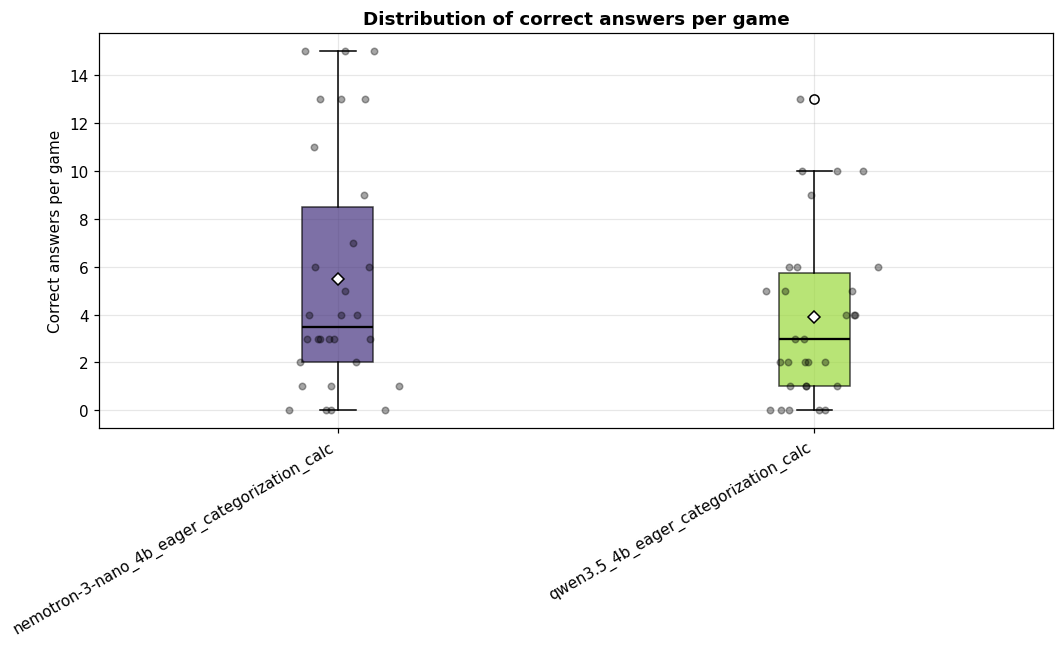

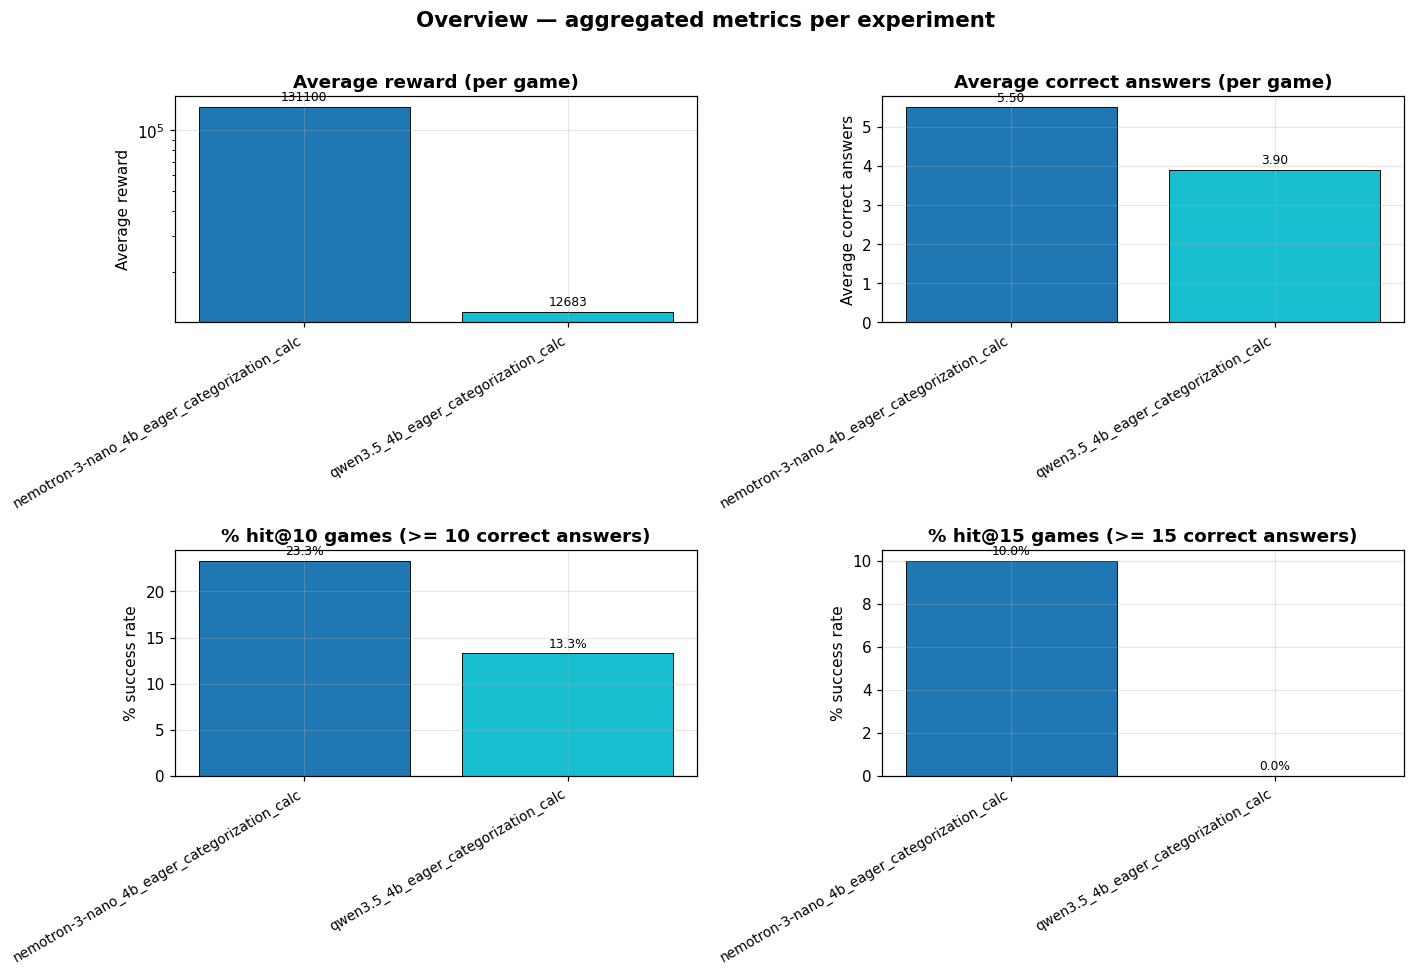

In [ ]:
_ = box_plot(["experiments-math/*eager*"])
_ = overview(["experiments-math/*eager*"])


With the hybrid architecture, both models acutally perform better.

#### Final Math Results

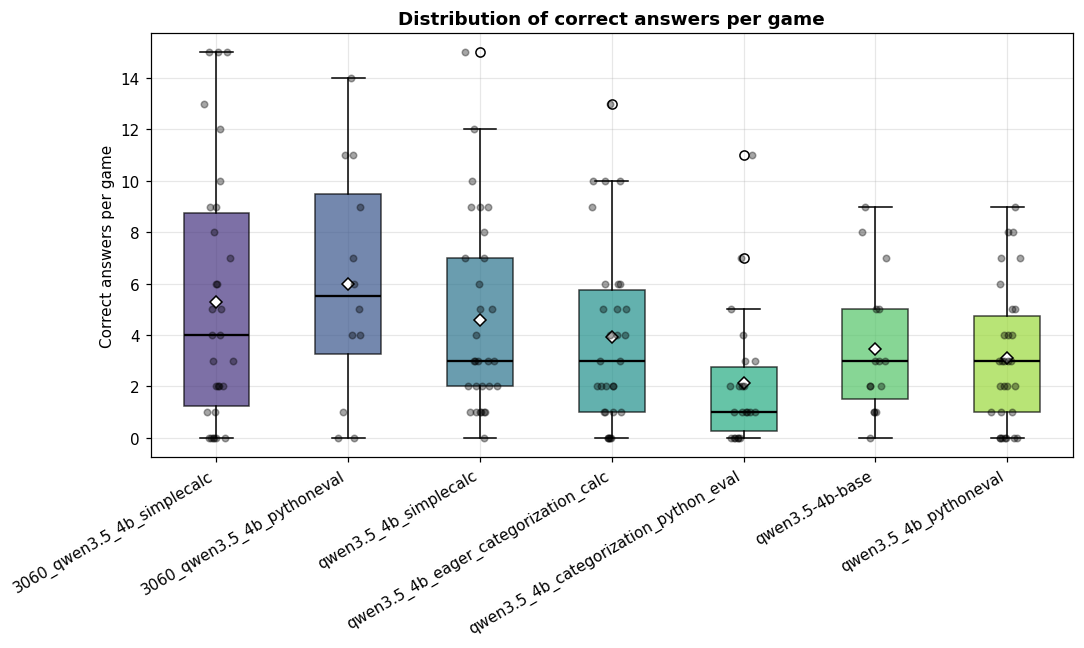

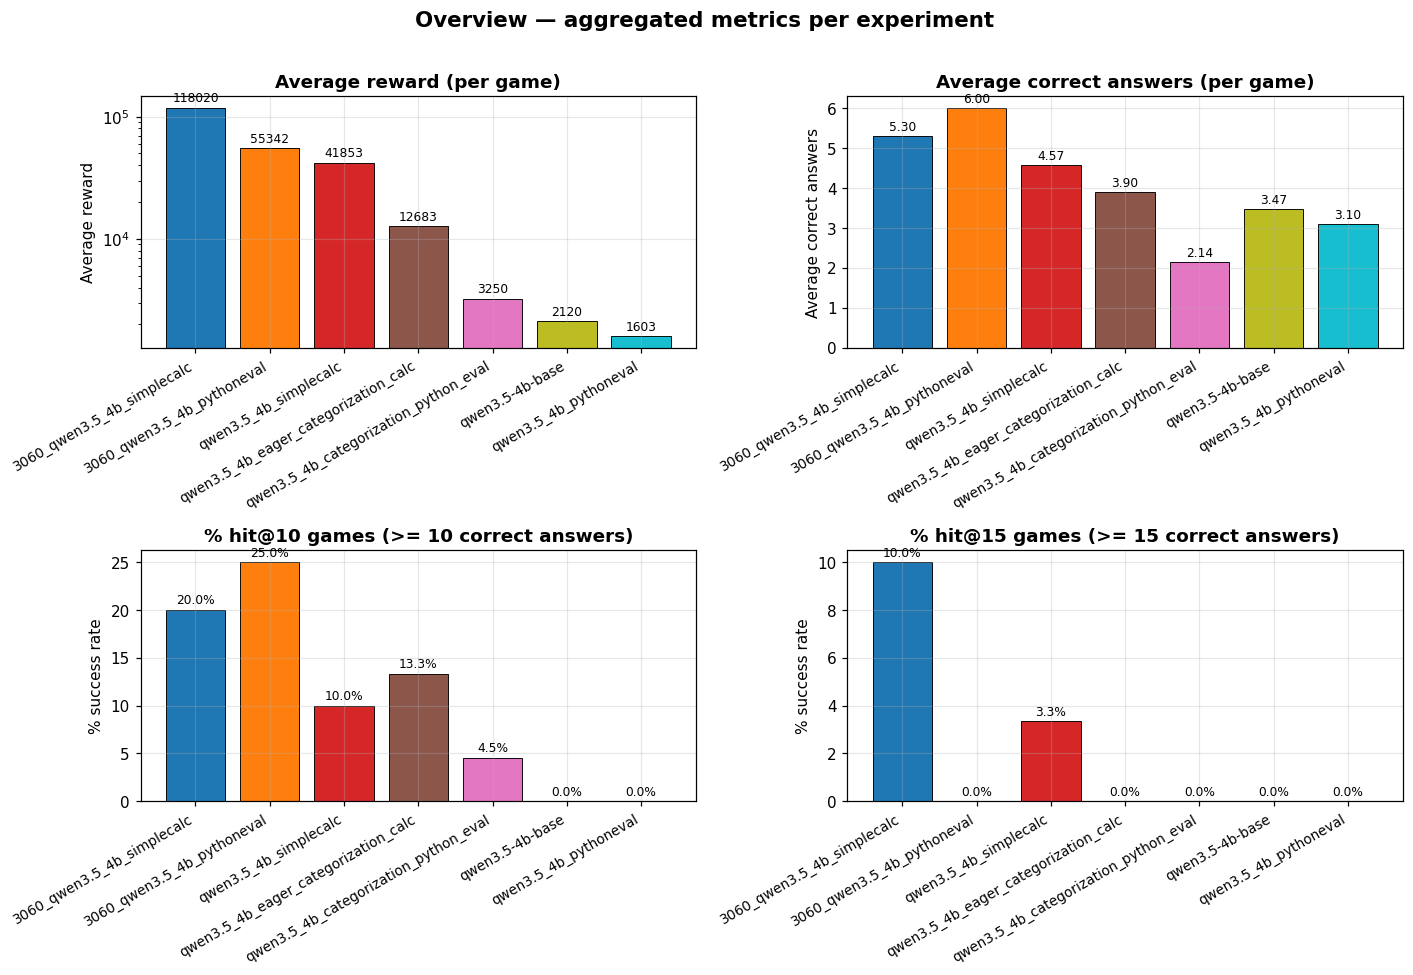

In [ ]:
# @title Qwen3.5 4B Math Results
experiments = ["experiments-math/qwen3.5_4b*", "experiments-math/qwen3.5-4b-base.json"]
_ = box_plot(experiments)
_ = overview(experiments)

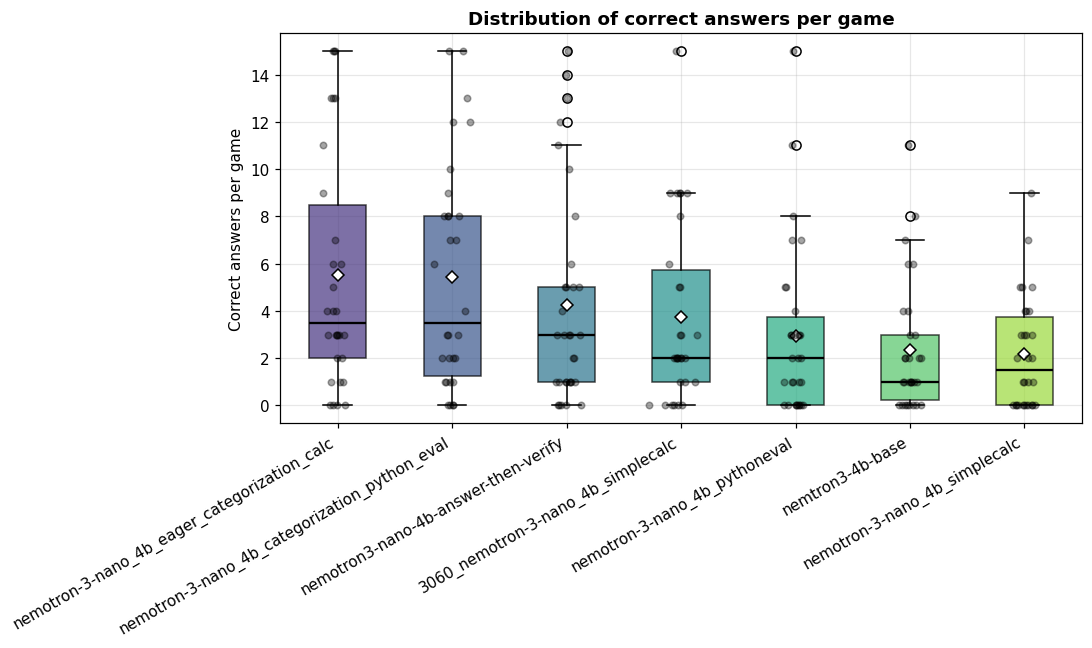

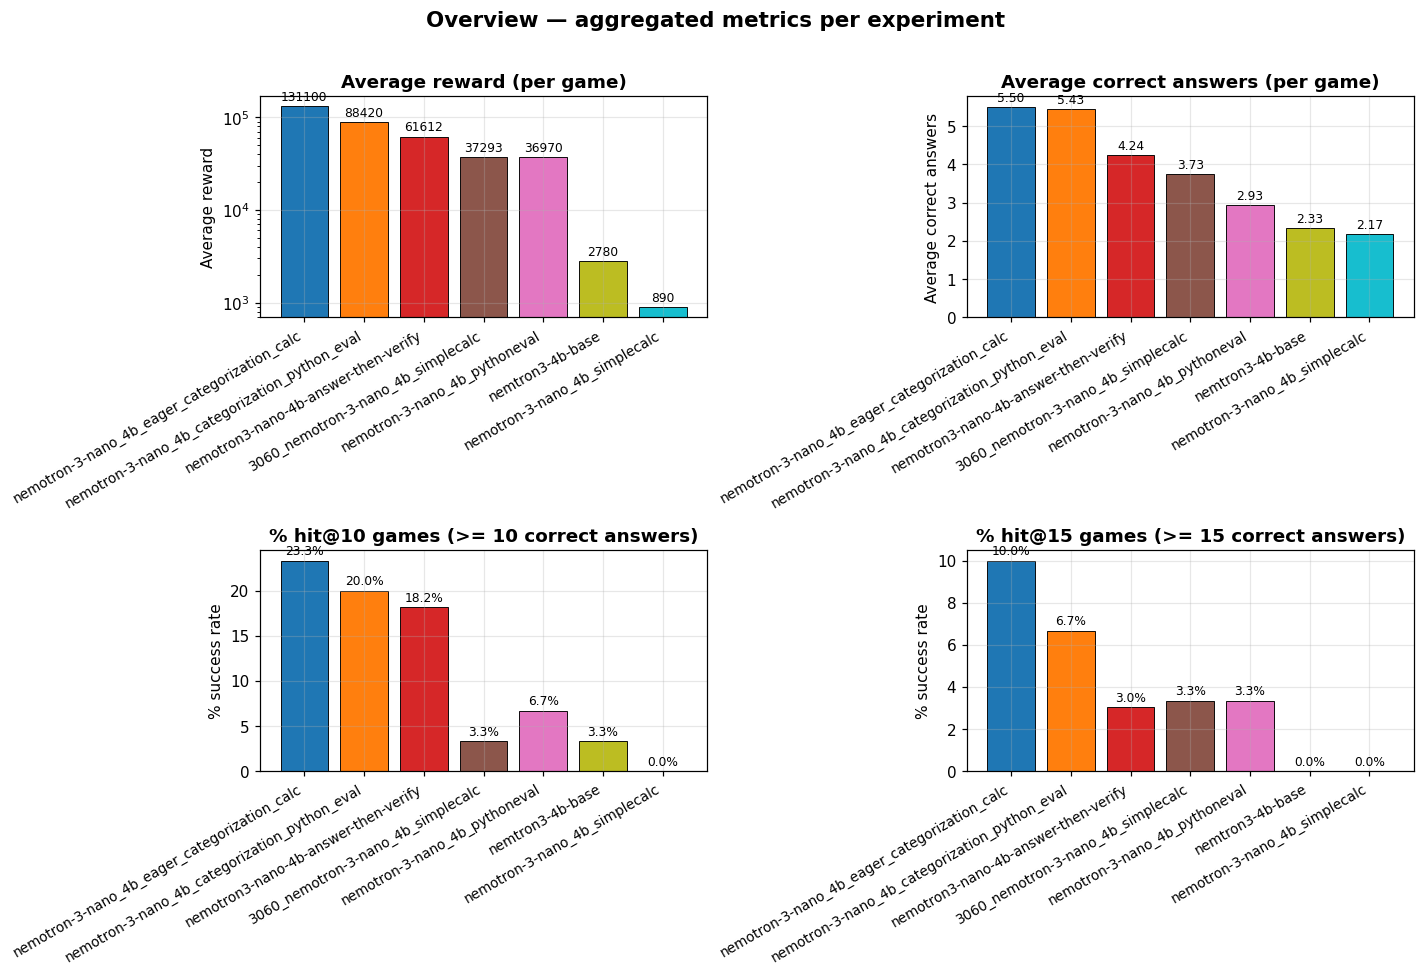

In [ ]:
# @title Nemotron Math Results
experiments = ["experiments-math/nemotron*", "experiments-math/nemtron*"]
_ = box_plot(experiments)
_ = overview(experiments)

This section visualizes experiment logs with boxplots. Each experiment file is converted into a distribution of correct answers per game session, allowing us to compare architectures by median performance, spread, and outliers.

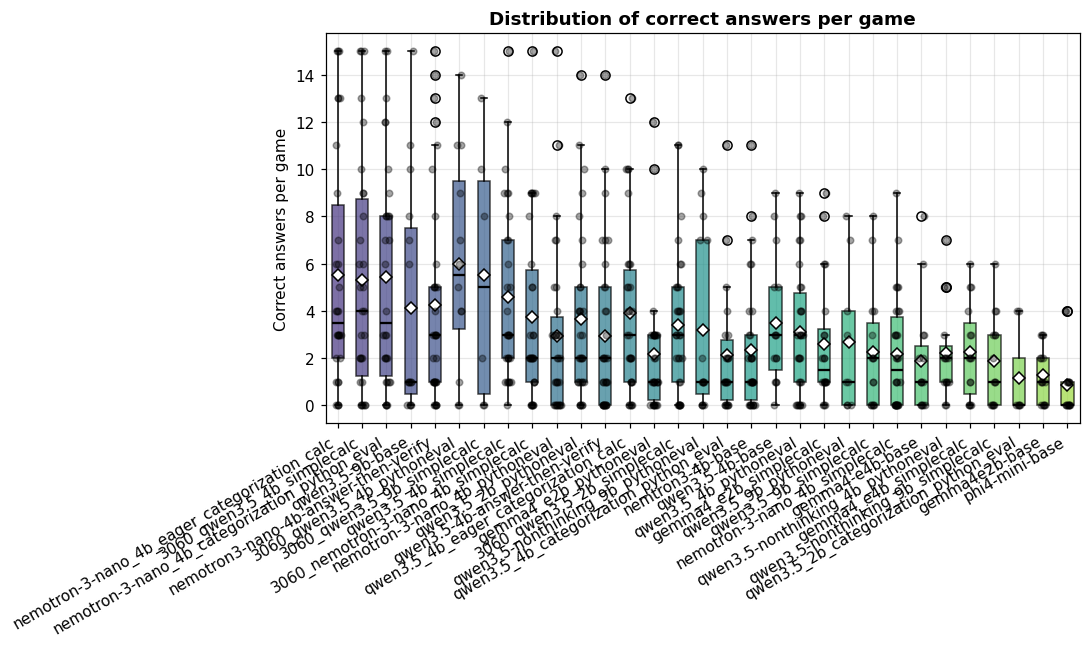

In [ ]:
# @title All maths results
r = os.listdir("logs/experiments-math")

_ = box_plot(["experiments-math/" + e for e in r if e.endswith("json")])

## Ancient

In [ ]:
# @title Ancient experiments selection

import re
import os

MATCH_BASE_PATH = SETTINGS["notebook_settings"]["project_folder"] + "/logs/experiments/ancient/"
EXPERIMENTS = ["*.json"]

def model_label(exp):
    return (
        exp.get("experiment_name")
        or exp.get("settings", {}).get("experiment_name")
        or exp.get("settings", {}).get("llm", {}).get("model")
        or "unknown"
    )

reset_cache()

matched = match_files(EXPERIMENTS, force=True)
print(f"MATCHED {len(matched)} ancient experiment file(s):")
for path in matched:
    print(f"  - {path}")

MATCHED 5 ancient experiment file(s):
  - ancient_gemma4e-2b_prompt1.json
  - ancient_gemma4e-2b_prompt2_websearch.json
  - ancient_gemma4e-4b_prompt.json
  - ancient_qwen3.5-2b_prompt1.json
  - ancient_qwen3.5-2b_prompt2_websearch.json


#### Ancient results comment

Ancient History questions are strongly knowledge-based and often require precise facts about civilizations, rulers, events, places, dates, and cultural practices. For this reason, we tested different model sizes, prompting strategies, and configurations.

The best setup was **`ancient_gemma4-e2b_prompt2_websearch`**. It was the most balanced configuration, performing better both in average correctness and in reaching deeper stages of the game. This suggests that the improved prompt and web search helped the model recover specific historical information that was not always available from memory alone.

The Gemma-based configurations were generally stronger than the Qwen-based ones. Interestingly, the larger Gemma4-e4B model was not always more consistent: it sometimes reached high-reward stages, but the smaller Gemma4-e2B with web search was more reliable overall.

The Qwen configurations struggled more in this category, especially on deeper questions. They also showed more instability, including more timeouts in some runs.

Overall, the experiments suggest that **Gemma4-e2B with prompt2 and web search is the best architecture for Ancient History**. Web search was particularly useful here because many Ancient History questions depend on narrow factual knowledge that small models may not memorize reliably.

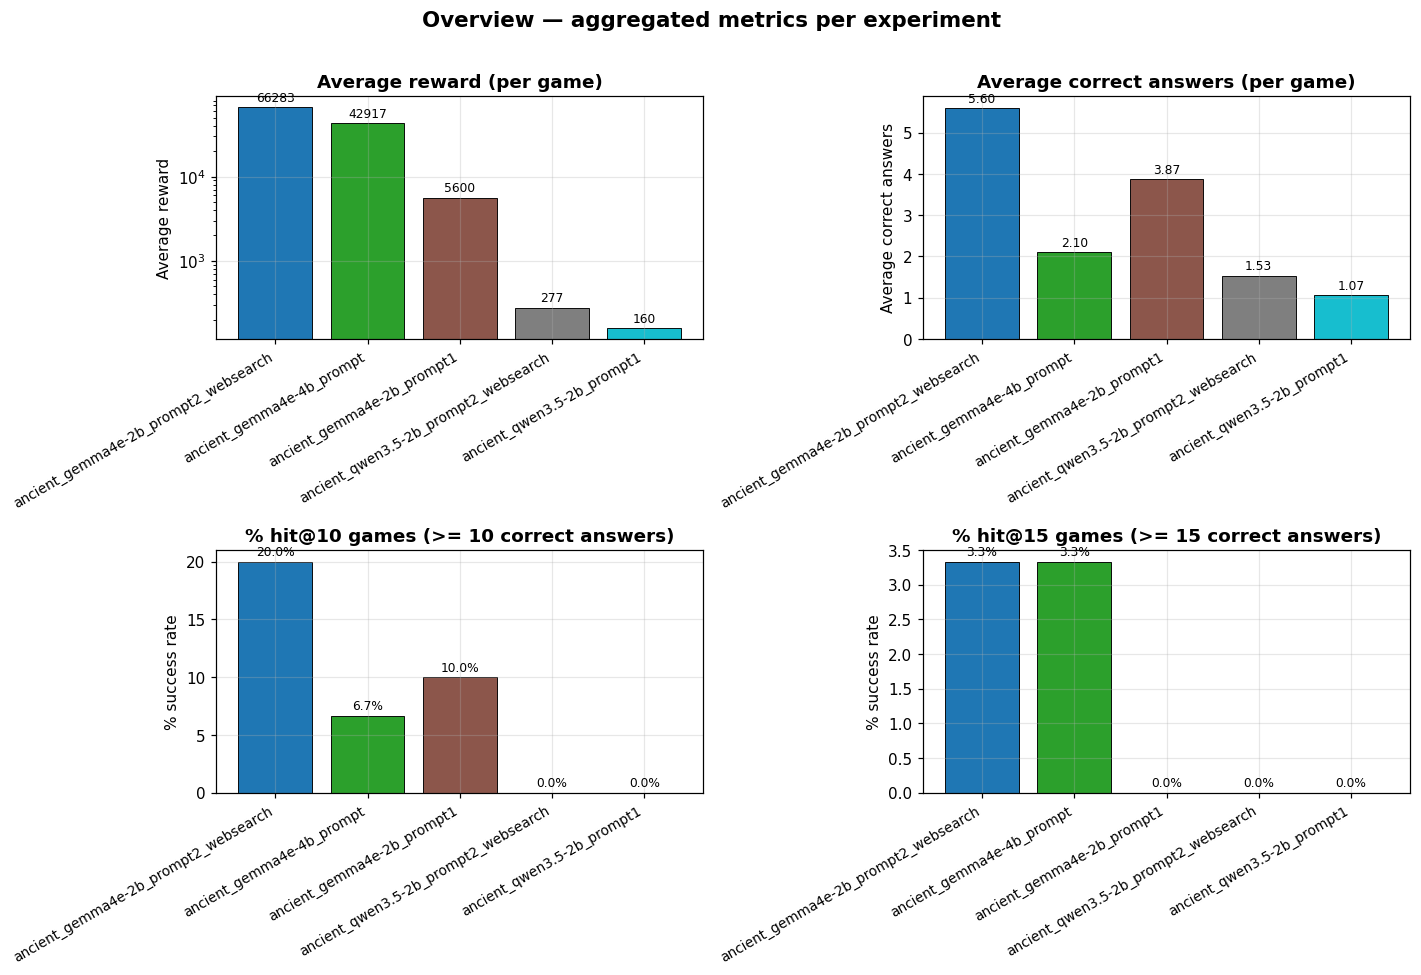

,model,n_runs,avg_reward,avg_correct,tot_correct,tot_wrong,tot_timeout,hit@10,hit@15
0,ancient_gemma4e-2b_prompt2_websearch.json,30,66283.333333,5.600000,168,25,4,20.000000,3.333333
1,ancient_gemma4e-4b_prompt.json,30,42916.666667,2.100000,63,22,7,6.666667,3.333333
2,ancient_gemma4e-2b_prompt1.json,30,5600.000000,3.866667,116,29,1,10.000000,0.000000
3,ancient_qwen3.5-2b_prompt2_websearch.json,30,276.666667,1.533333,46,19,11,0.000000,0.000000
4,ancient_qwen3.5-2b_prompt1.json,30,160.000000,1.066667,32,9,21,0.000000,0.000000


In [ ]:
# @title Ancient overview

overview(EXPERIMENTS)

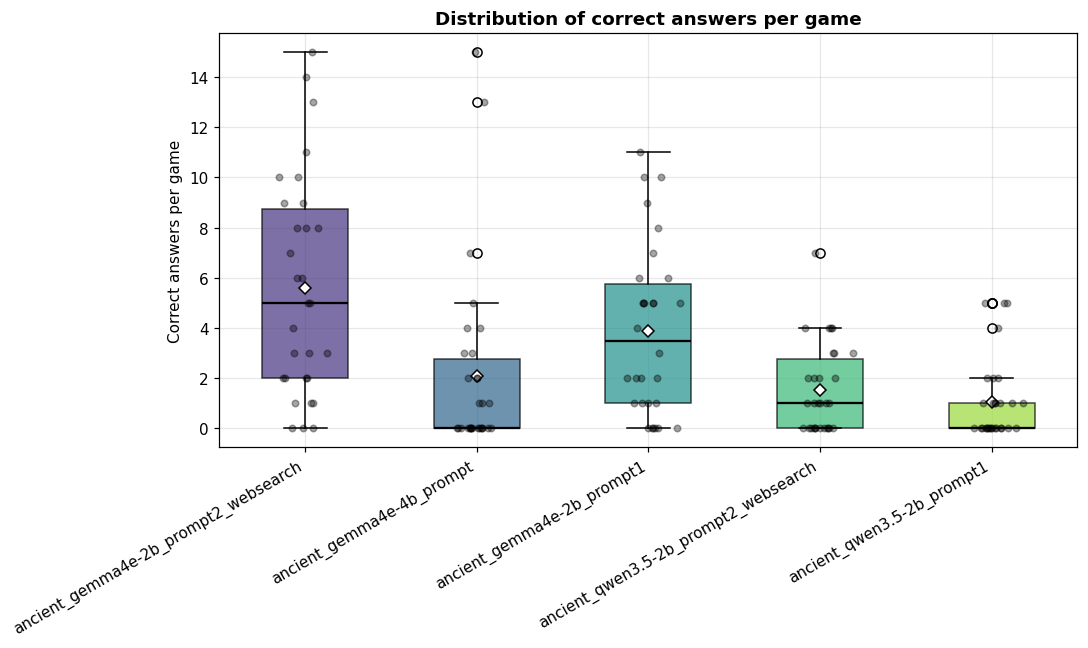

,file,model,session_idx,reward,n_questions,n_correct,n_wrong,n_timeout
0,ancient_gemma4e-2b_prompt1.json,ancient_gemma4e-2b_prompt1.json,0,0,1,0,1,0
1,ancient_gemma4e-2b_prompt1.json,ancient_gemma4e-2b_prompt1.json,1,100,2,1,1,0
2,ancient_gemma4e-2b_prompt1.json,ancient_gemma4e-2b_prompt1.json,2,0,1,0,1,0
3,ancient_gemma4e-2b_prompt1.json,ancient_gemma4e-2b_prompt1.json,3,0,1,0,1,0
4,ancient_gemma4e-2b_prompt1.json,ancient_gemma4e-2b_prompt1.json,4,300,4,3,1,0
...,...,...,...,...,...,...,...,...
145,ancient_qwen3.5-2b_prompt2_websearch.json,ancient_qwen3.5-2b_prompt2_websearch.json,25,0,1,0,0,1
146,ancient_qwen3.5-2b_prompt2_websearch.json,ancient_qwen3.5-2b_prompt2_websearch.json,26,500,5,4,1,0
147,ancient_qwen3.5-2b_prompt2_websearch.json,ancient_qwen3.5-2b_prompt2_websearch.json,27,200,3,2,1,0
148,ancient_qwen3.5-2b_prompt2_websearch.json,ancient_qwen3.5-2b_prompt2_websearch.json,28,0,1,0,0,1


In [ ]:
# @title Ancient boxplot

box_plot(EXPERIMENTS)

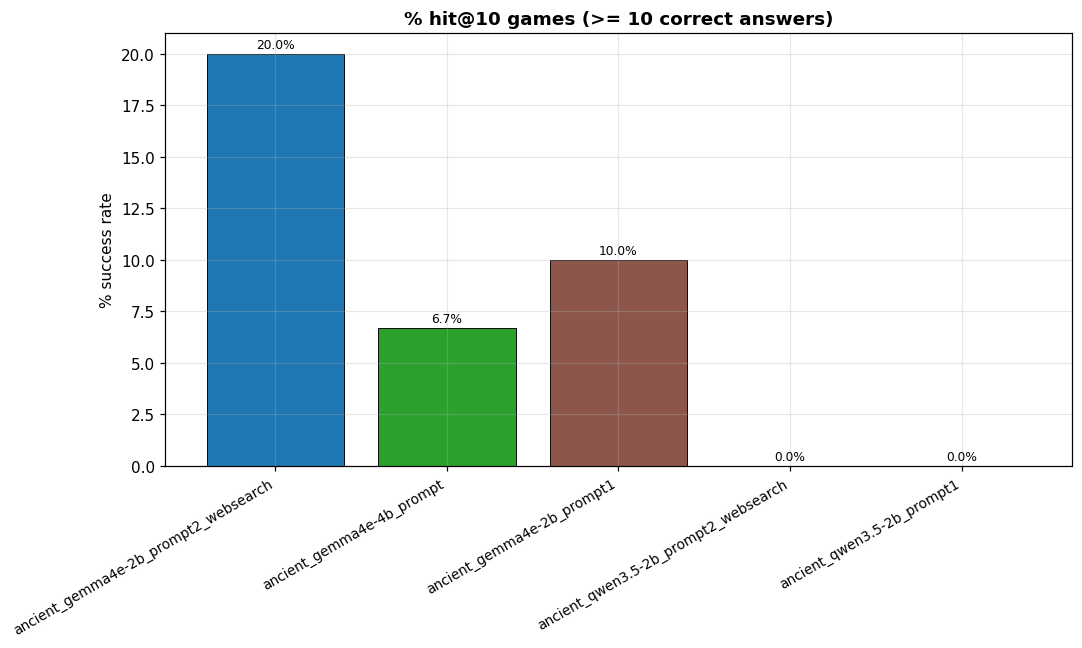

,model,hit@10
0,ancient_gemma4e-2b_prompt2_websearch.json,20.000000
1,ancient_gemma4e-4b_prompt.json,6.666667
2,ancient_gemma4e-2b_prompt1.json,10.000000
3,ancient_qwen3.5-2b_prompt2_websearch.json,0.000000
4,ancient_qwen3.5-2b_prompt1.json,0.000000


In [ ]:
# @title Ancient Hit@10

hit_at(10, EXPERIMENTS)

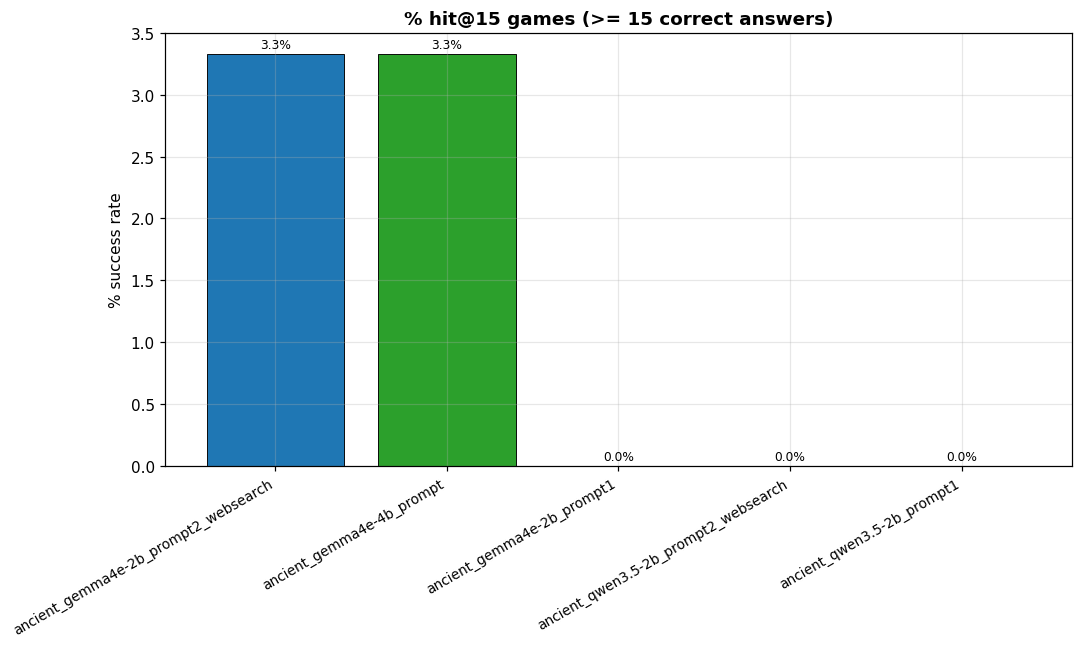

,model,hit@15
0,ancient_gemma4e-2b_prompt2_websearch.json,3.333333
1,ancient_gemma4e-4b_prompt.json,3.333333
2,ancient_gemma4e-2b_prompt1.json,0.000000
3,ancient_qwen3.5-2b_prompt2_websearch.json,0.000000
4,ancient_qwen3.5-2b_prompt1.json,0.000000


In [ ]:
# @title Ancient Hit@15

hit_at(15, EXPERIMENTS)

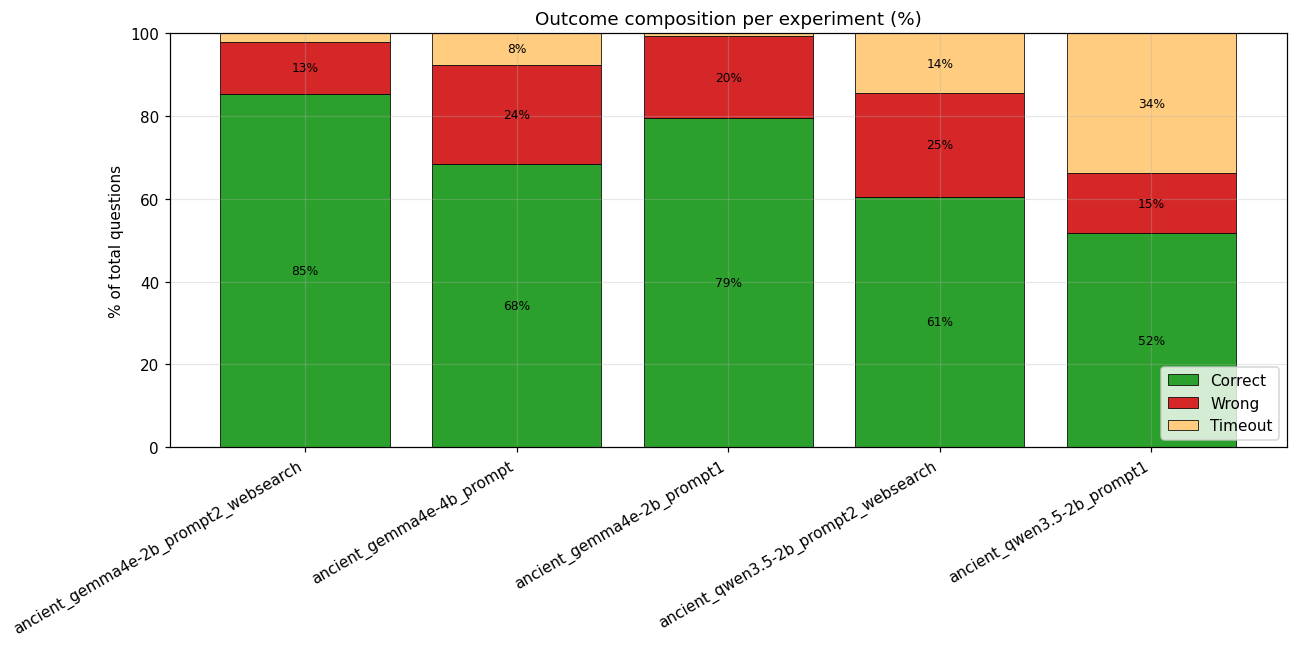

,model,tot_correct,tot_wrong,tot_timeout
0,ancient_gemma4e-2b_prompt2_websearch.json,168,25,4
1,ancient_gemma4e-4b_prompt.json,63,22,7
2,ancient_gemma4e-2b_prompt1.json,116,29,1
3,ancient_qwen3.5-2b_prompt2_websearch.json,46,19,11
4,ancient_qwen3.5-2b_prompt1.json,32,9,21


In [ ]:
# @title Ancient outcomes distribution %

outcomes_pct(EXPERIMENTS)

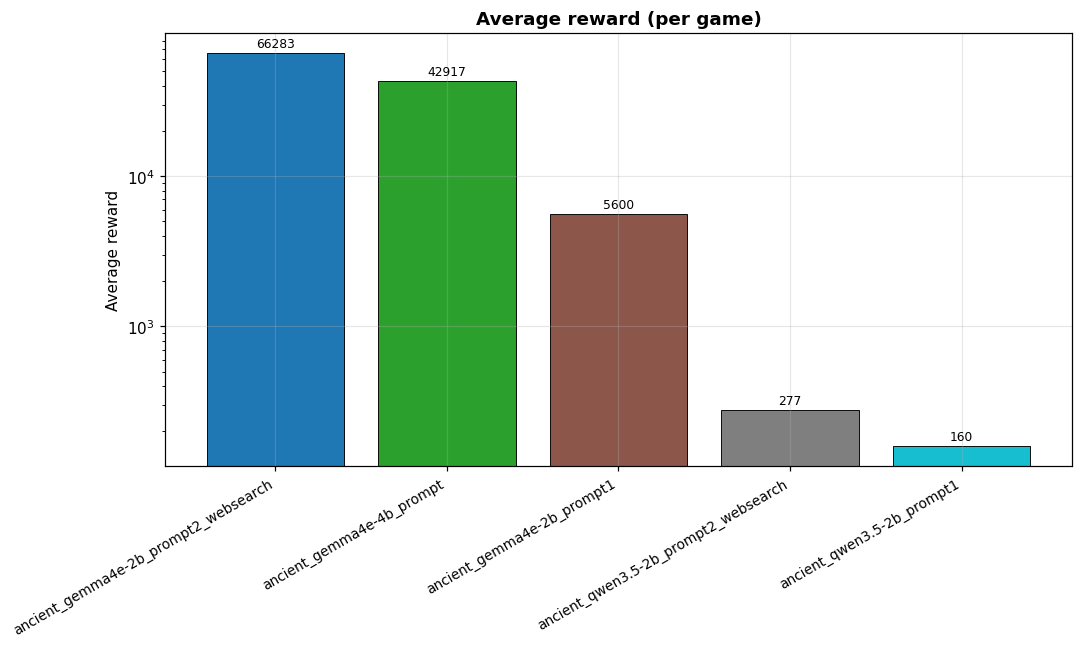

,model,avg_reward
0,ancient_gemma4e-2b_prompt2_websearch.json,66283.333333
1,ancient_gemma4e-4b_prompt.json,42916.666667
2,ancient_gemma4e-2b_prompt1.json,5600.000000
3,ancient_qwen3.5-2b_prompt2_websearch.json,276.666667
4,ancient_qwen3.5-2b_prompt1.json,160.000000


In [ ]:
# @title Ancient average reward

avg_reward(EXPERIMENTS)

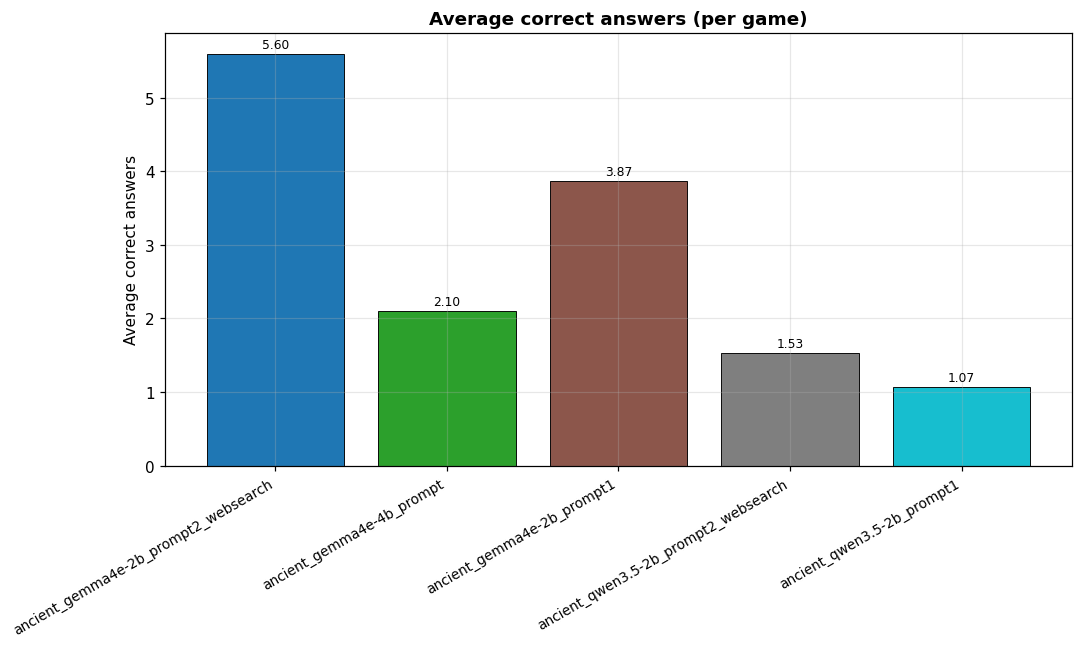

,model,avg_correct
0,ancient_gemma4e-2b_prompt2_websearch.json,5.600000
1,ancient_gemma4e-4b_prompt.json,2.100000
2,ancient_gemma4e-2b_prompt1.json,3.866667
3,ancient_qwen3.5-2b_prompt2_websearch.json,1.533333
4,ancient_qwen3.5-2b_prompt1.json,1.066667


In [ ]:
# @title Ancient average correct answers

avg_question(EXPERIMENTS)

## Entertainment

Entertainment questions **naturally fit a Retrieval-Augmented Generation (RAG) approach**, as most of the required knowledge consists of factual information about movies, television, music, celebrities, books, video games, and popular culture.

During our experiments, we observed that:

- Domain-specific retrieval was highly effective. Many questions required recalling specific entities, titles, dates, awards, characters, or relationships that are difficult for small models to memorize reliably.

- Different models reacted differently to retrieved context. Some models benefited greatly from additional knowledge, while others struggled to correctly identify the most relevant information among the retrieved passages.

We experimented with **different prompting strategies**, **multiple LLMs**, and **various retrieval configurations**. We also evaluated the integration of **web search** to complement the knowledge base when the retrieved context was insufficient or when broader coverage was required.

Overall, the combination of a domain-specific Wikipedia-based RAG system and targeted web search proved to be the most effective approach for entertainment-related questions, in fact also for this category the best combo is **gemma4-e2b with websearch**

In [ ]:
# @title Entertainment experiments selection

import glob

EXPERIMENTS = sorted(glob.glob("logs/experiments/entertainment/*.json"))

print(f"Found {len(EXPERIMENTS)} entertainment experiment file(s):")
for path in EXPERIMENTS:
    print(path)

Found 9 entertainment experiment file(s):
logs/experiments/entertainment/ent_p0_gemma-4b_web.json
logs/experiments/entertainment/ent_p0_gemma2b.json
logs/experiments/entertainment/ent_p0_qwen3.5-2b.json
logs/experiments/entertainment/ent_p1_gemma-4b_no_rag_no_web.json
logs/experiments/entertainment/ent_p1_gemma-4b_web.json
logs/experiments/entertainment/ent_p1_gemma4e-2b.json
logs/experiments/entertainment/ent_p1_gemma4e-2b_web.json
logs/experiments/entertainment/ent_p1_qwen3.5-2b.json
logs/experiments/entertainment/ent_p1_qwen3.5-2b_web.json


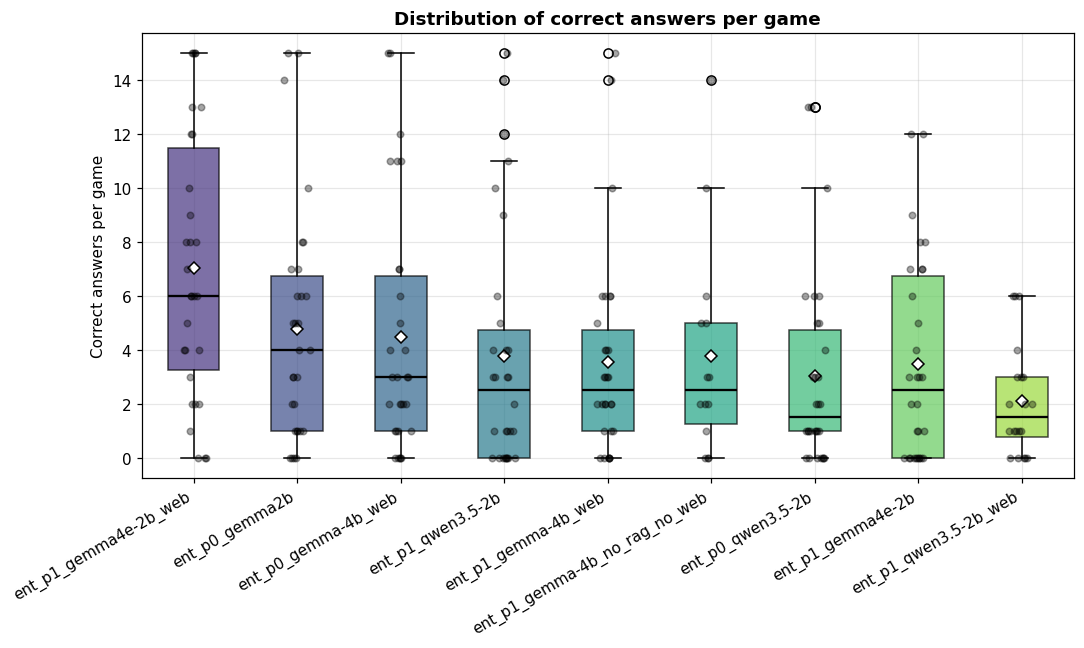

,file,model,session_idx,reward,n_questions,n_correct,n_wrong,n_timeout
0,experiments/entertainment/ent_p0_gemma-4b_web....,experiments/entertainment/ent_p0_gemma-4b_web....,0,200,3,2,1,0
1,experiments/entertainment/ent_p0_gemma-4b_web....,experiments/entertainment/ent_p0_gemma-4b_web....,1,0,1,0,1,0
2,experiments/entertainment/ent_p0_gemma-4b_web....,experiments/entertainment/ent_p0_gemma-4b_web....,2,1024000,15,15,0,0
3,experiments/entertainment/ent_p0_gemma-4b_web....,experiments/entertainment/ent_p0_gemma-4b_web....,3,100,2,1,0,1
4,experiments/entertainment/ent_p0_gemma-4b_web....,experiments/entertainment/ent_p0_gemma-4b_web....,4,1000,6,5,0,1
...,...,...,...,...,...,...,...,...
239,experiments/entertainment/ent_p1_qwen3.5-2b_we...,experiments/entertainment/ent_p1_qwen3.5-2b_we...,15,2000,7,6,1,0
240,experiments/entertainment/ent_p1_qwen3.5-2b_we...,experiments/entertainment/ent_p1_qwen3.5-2b_we...,16,0,1,0,1,0
241,experiments/entertainment/ent_p1_qwen3.5-2b_we...,experiments/entertainment/ent_p1_qwen3.5-2b_we...,17,200,3,2,1,0
242,experiments/entertainment/ent_p1_qwen3.5-2b_we...,experiments/entertainment/ent_p1_qwen3.5-2b_we...,18,500,5,4,1,0


In [ ]:
# @title Entertainment boxplot
import fnmatch
import re
MATCH_BASE_PATH = "logs"


box_plot(EXPERIMENTS)

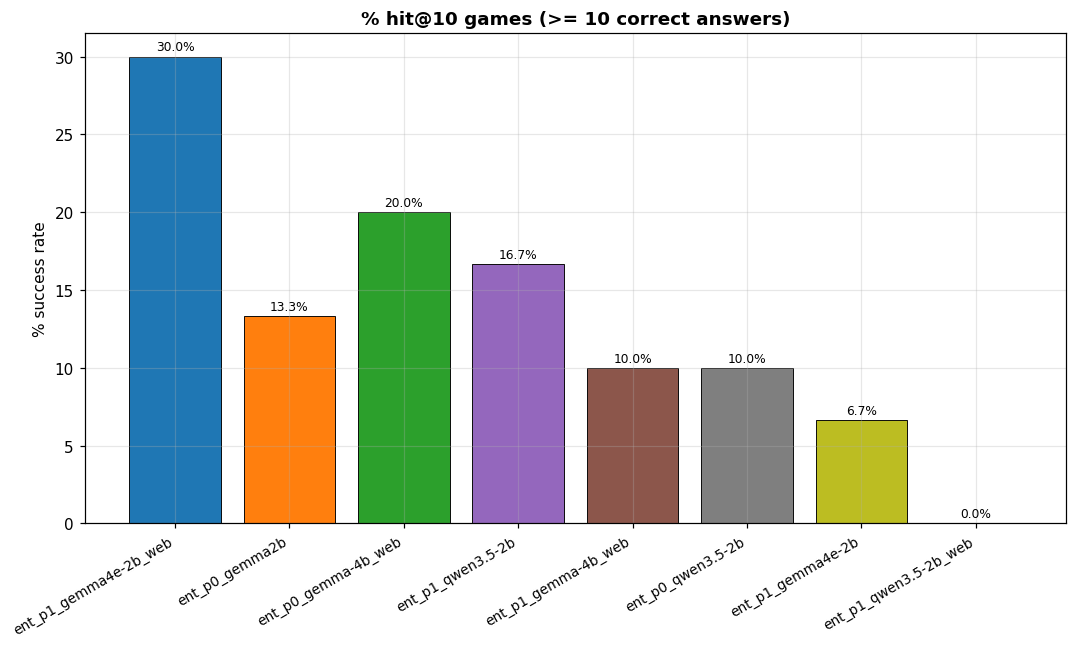

,model,hit@10
0,experiments/entertainment/ent_p1_gemma4e-2b_we...,30.000000
1,experiments/entertainment/ent_p0_gemma2b.json,13.333333
2,experiments/entertainment/ent_p0_gemma-4b_web....,20.000000
3,experiments/entertainment/ent_p1_qwen3.5-2b.json,16.666667
4,experiments/entertainment/ent_p1_gemma-4b_web....,10.000000
5,experiments/entertainment/ent_p0_qwen3.5-2b.json,10.000000
6,experiments/entertainment/ent_p1_gemma4e-2b.json,6.666667
7,experiments/entertainment/ent_p1_qwen3.5-2b_we...,0.000000


In [ ]:
# @title Entertainment Hit@10

hit_at(10, EXPERIMENTS)

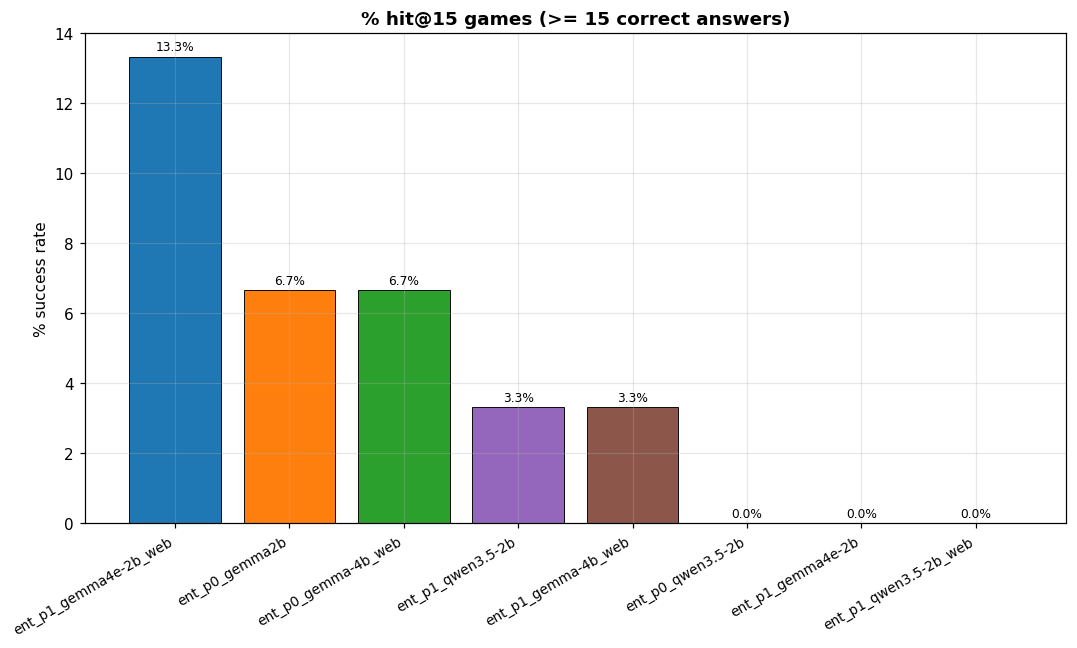

,model,hit@15
0,experiments/entertainment/ent_p1_gemma4e-2b_we...,13.333333
1,experiments/entertainment/ent_p0_gemma2b.json,6.666667
2,experiments/entertainment/ent_p0_gemma-4b_web....,6.666667
3,experiments/entertainment/ent_p1_qwen3.5-2b.json,3.333333
4,experiments/entertainment/ent_p1_gemma-4b_web....,3.333333
5,experiments/entertainment/ent_p0_qwen3.5-2b.json,0.000000
6,experiments/entertainment/ent_p1_gemma4e-2b.json,0.000000
7,experiments/entertainment/ent_p1_qwen3.5-2b_we...,0.000000


In [ ]:
# @title Entertainment Hit@15

hit_at(15, EXPERIMENTS)

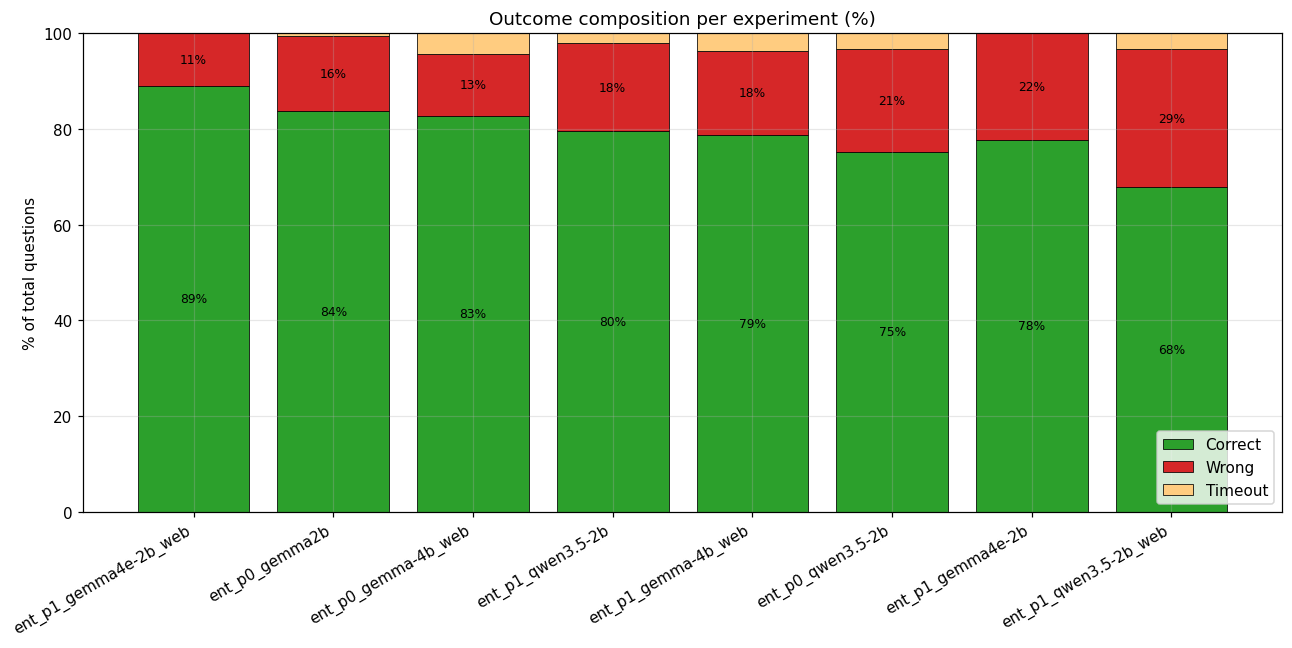

,model,tot_correct,tot_wrong,tot_timeout
0,experiments/entertainment/ent_p1_gemma4e-2b_we...,211,26,0
1,experiments/entertainment/ent_p0_gemma2b.json,143,27,1
2,experiments/entertainment/ent_p0_gemma-4b_web....,134,21,7
3,experiments/entertainment/ent_p1_qwen3.5-2b.json,113,26,3
4,experiments/entertainment/ent_p1_gemma-4b_web....,107,24,5
5,experiments/entertainment/ent_p0_qwen3.5-2b.json,91,26,4
6,experiments/entertainment/ent_p1_gemma4e-2b.json,104,30,0
7,experiments/entertainment/ent_p1_qwen3.5-2b_we...,42,18,2


In [ ]:
# @title Entertainment outcomes distribution %

outcomes_pct(EXPERIMENTS)

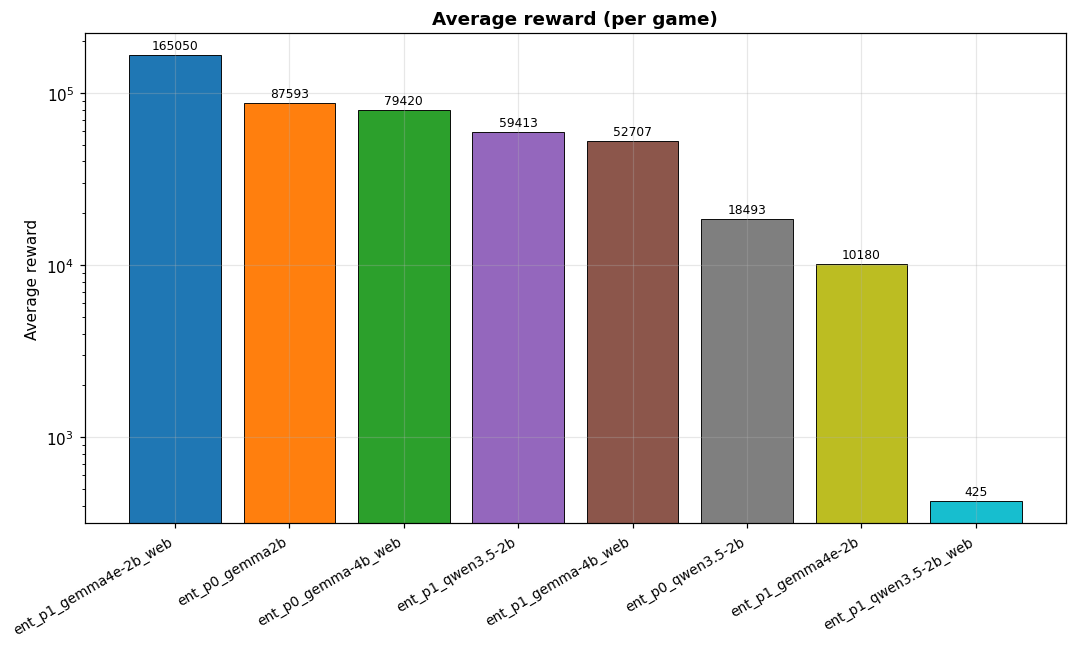

,model,avg_reward
0,experiments/entertainment/ent_p1_gemma4e-2b_we...,165050.000000
1,experiments/entertainment/ent_p0_gemma2b.json,87593.333333
2,experiments/entertainment/ent_p0_gemma-4b_web....,79420.000000
3,experiments/entertainment/ent_p1_qwen3.5-2b.json,59413.333333
4,experiments/entertainment/ent_p1_gemma-4b_web....,52706.666667
5,experiments/entertainment/ent_p0_qwen3.5-2b.json,18493.333333
6,experiments/entertainment/ent_p1_gemma4e-2b.json,10180.000000
7,experiments/entertainment/ent_p1_qwen3.5-2b_we...,425.000000


In [ ]:
# @title Entertainment average reward

avg_reward(EXPERIMENTS)

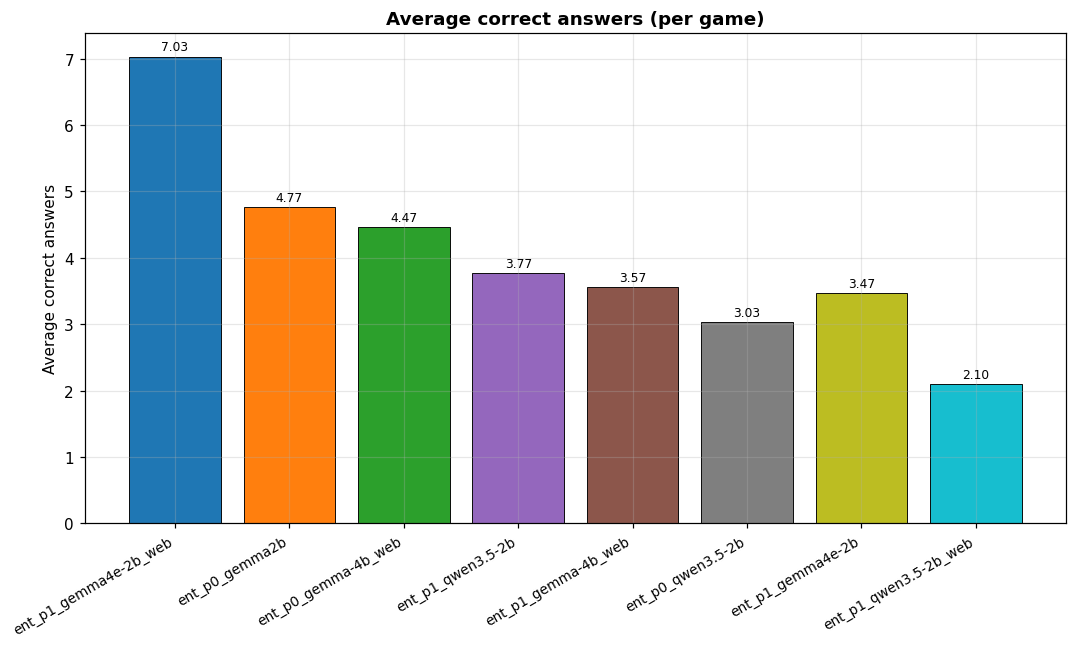

,model,avg_correct
0,experiments/entertainment/ent_p1_gemma4e-2b_we...,7.033333
1,experiments/entertainment/ent_p0_gemma2b.json,4.766667
2,experiments/entertainment/ent_p0_gemma-4b_web....,4.466667
3,experiments/entertainment/ent_p1_qwen3.5-2b.json,3.766667
4,experiments/entertainment/ent_p1_gemma-4b_web....,3.566667
5,experiments/entertainment/ent_p0_qwen3.5-2b.json,3.033333
6,experiments/entertainment/ent_p1_gemma4e-2b.json,3.466667
7,experiments/entertainment/ent_p1_qwen3.5-2b_we...,2.100000


In [ ]:
# @title Entertainment average correct answers

avg_question(EXPERIMENTS)

## Science and Nature

In [ ]:
# @title Science and Nature experiments selection

import re
import os

MATCH_BASE_PATH = SETTINGS["notebook_settings"]["project_folder"] + "/logs/experiments/science_nature/"
EXPERIMENTS = ["*.json"]

def model_label(exp):
    return (
        exp.get("experiment_name")
        or exp.get("settings", {}).get("experiment_name")
        or exp.get("settings", {}).get("llm", {}).get("model")
        or "unknown"
    )

reset_cache()

matched = match_files(EXPERIMENTS, force=True)
print(f"MATCHED {len(matched)} science and nature experiment file(s):")
for path in matched:
    print(f"  - {path}")

MATCHED 10 science and nature experiment file(s):
  - science_nature_gemma4e-2b_prompt1_sciq.json
  - science_nature_gemma4e-2b_prompt1_wiki.json
  - science_nature_gemma4e-2b_prompt2_websearch_sciq.json
  - science_nature_gemma4e-2b_prompt2_websearch_wiki.json
  - science_nature_gemma4e-4b_prompt1_sciq.json
  - science_nature_gemma4e-4b_prompt1_wiki.json
  - science_nature_qwen3.5-2b_prompt1_sciq.json
  - science_nature_qwen3.5-2b_prompt1_wiki.json
  - science_nature_qwen3.5-2b_prompt2_websearch_sciq.json
  - science_nature_qwen3.5-2b_prompt2_websearch_wiki.json


#### Science and Nature results comment

Science and Nature questions are mostly factual, but they cover a very broad range of topics: biology, physics, chemistry, astronomy, medicine, animals, and general scientific knowledge. For this reason, we tested different models, prompts, retrieval sources, and web search configurations.

The strongest results came from **Gemma4e-2B combined with Wikipedia-based retrieval**. In particular, the best setup was **`science_nature_gemma4e-2b_prompt1_wiki`**, which performed well both in average correctness and in reaching the later, higher-reward stages of the game.

We also tested SciQ-based retrieval. These runs were competitive, especially when combined with web search, but overall they were less stable than the Wikipedia-based configurations. This suggests that SciQ is useful for scientific question answering, but Wikipedia gives broader coverage for the mixed and general nature of the Polimillionaire questions.

Web search helped in some cases, especially when the retrieved context was not enough or when the question required a very specific fact. However, it did not always improve the results over the simpler Wiki-based pipeline.

The Qwen-based models performed reasonably in some runs, but they were generally less effective than Gemma4e-2B, especially when considering reward and late-game performance.

Overall, the best architecture for Science and Nature was **Gemma4e-2B with prompt1 and Wikipedia context**. The experiments suggest that, for this category, broad and reliable retrieval is more important than adding more complex search strategies in every question.

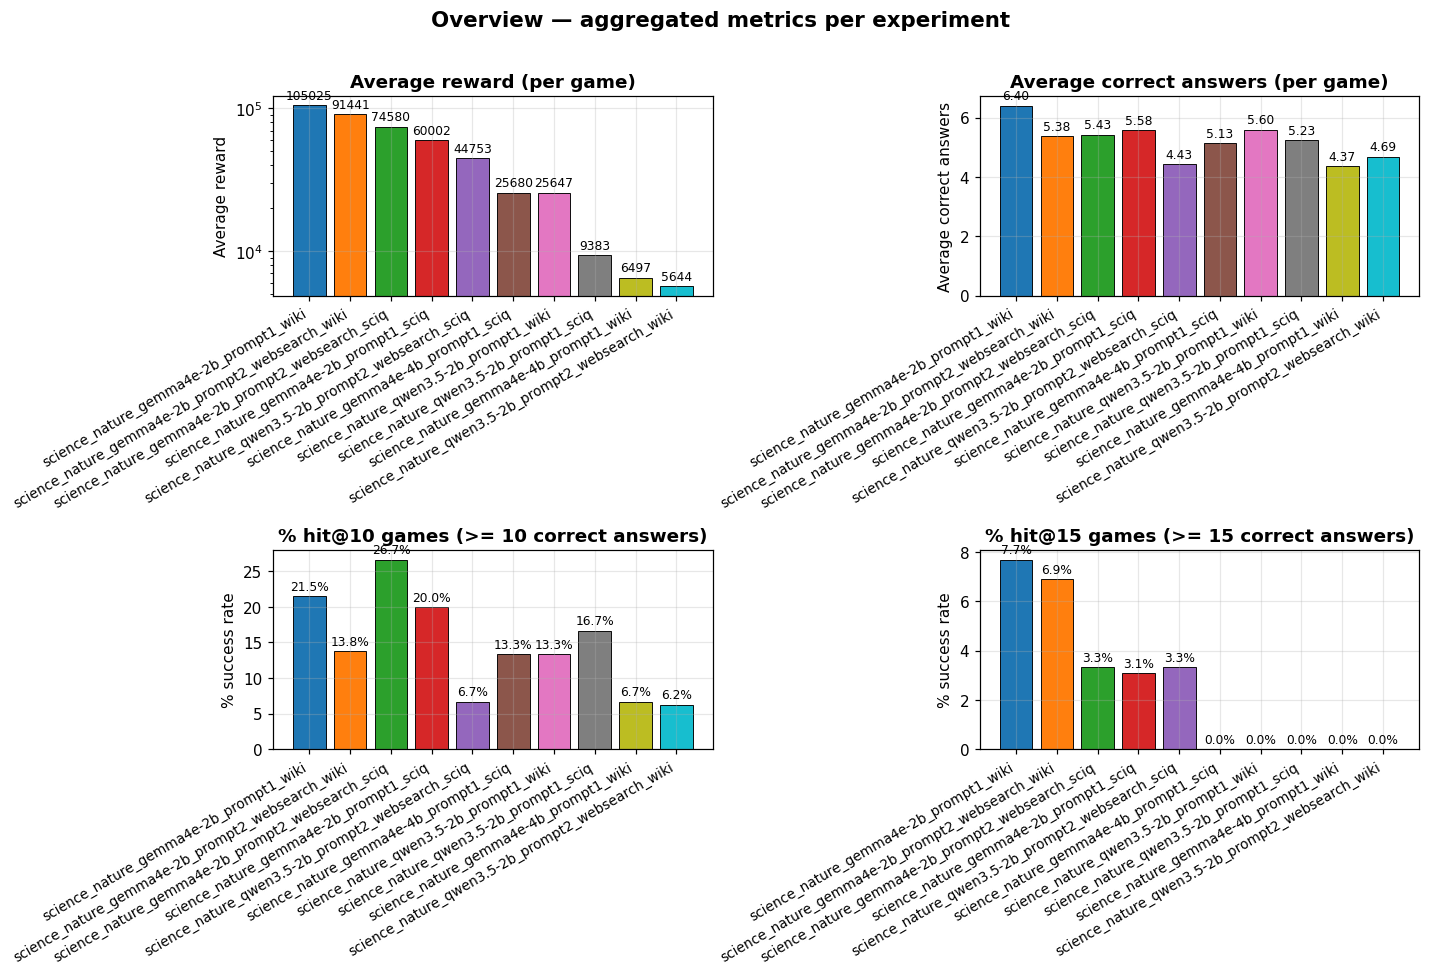

,model,n_runs,avg_reward,avg_correct,tot_correct,tot_wrong,tot_timeout,hit@10,hit@15
0,science_nature_gemma4e-2b_prompt1_wiki.json,65,105024.615385,6.400000,416,56,0,21.538462,7.692308
1,science_nature_gemma4e-2b_prompt2_websearch_wi...,29,91441.379310,5.379310,156,25,2,13.793103,6.896552
2,science_nature_gemma4e-2b_prompt2_websearch_sc...,30,74580.000000,5.433333,163,26,3,26.666667,3.333333
3,science_nature_gemma4e-2b_prompt1_sciq.json,65,60001.538462,5.584615,363,63,0,20.000000,3.076923
4,science_nature_qwen3.5-2b_prompt2_websearch_sc...,30,44753.333333,4.433333,133,20,9,6.666667,3.333333
5,science_nature_gemma4e-4b_prompt1_sciq.json,30,25680.000000,5.133333,154,15,15,13.333333,0.000000
6,science_nature_qwen3.5-2b_prompt1_wiki.json,30,25646.666667,5.600000,168,21,9,13.333333,0.000000
7,science_nature_qwen3.5-2b_prompt1_sciq.json,30,9383.333333,5.233333,157,22,8,16.666667,0.000000
8,science_nature_gemma4e-4b_prompt1_wiki.json,30,6496.666667,4.366667,131,10,20,6.666667,0.000000
9,science_nature_qwen3.5-2b_prompt2_websearch_wi...,16,5643.750000,4.687500,75,6,10,6.250000,0.000000


In [ ]:
# @title Science and Nature overview

overview(EXPERIMENTS)

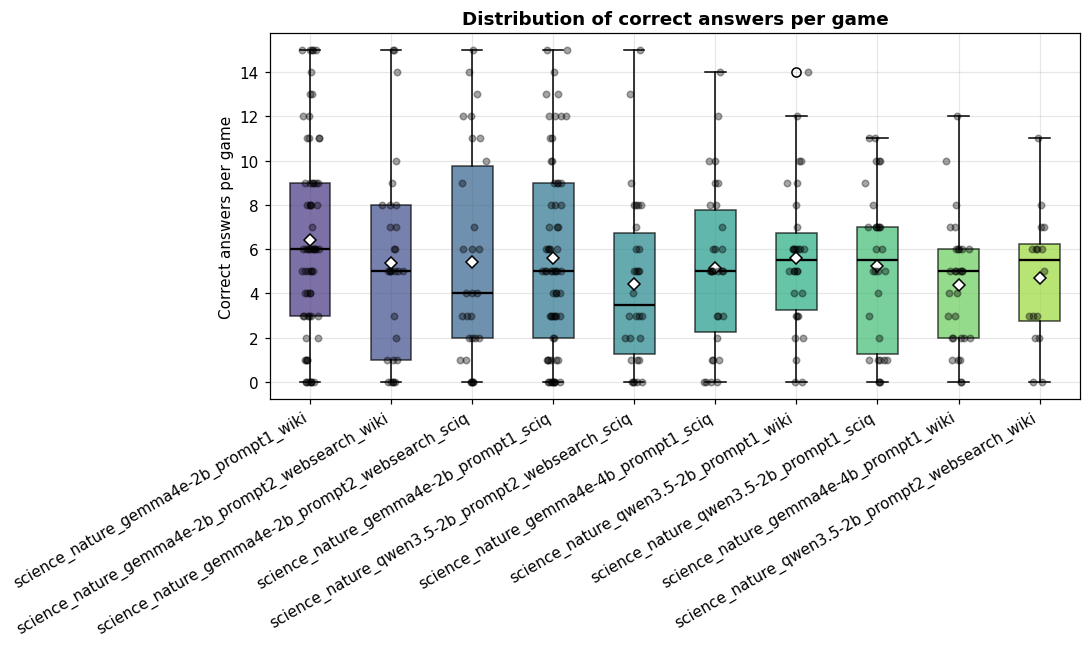

,file,model,session_idx,reward,n_questions,n_correct,n_wrong,n_timeout
0,science_nature_gemma4e-2b_prompt1_sciq.json,science_nature_gemma4e-2b_prompt1_sciq.json,0,1024000,15,15,0,0
1,science_nature_gemma4e-2b_prompt1_sciq.json,science_nature_gemma4e-2b_prompt1_sciq.json,1,100,2,1,1,0
2,science_nature_gemma4e-2b_prompt1_sciq.json,science_nature_gemma4e-2b_prompt1_sciq.json,2,0,1,0,1,0
3,science_nature_gemma4e-2b_prompt1_sciq.json,science_nature_gemma4e-2b_prompt1_sciq.json,3,0,1,0,1,0
4,science_nature_gemma4e-2b_prompt1_sciq.json,science_nature_gemma4e-2b_prompt1_sciq.json,4,1000,6,5,1,0
...,...,...,...,...,...,...,...,...
350,science_nature_qwen3.5-2b_prompt2_websearch_wi...,science_nature_qwen3.5-2b_prompt2_websearch_wi...,11,300,4,3,0,1
351,science_nature_qwen3.5-2b_prompt2_websearch_wi...,science_nature_qwen3.5-2b_prompt2_websearch_wi...,12,4000,8,7,1,0
352,science_nature_qwen3.5-2b_prompt2_websearch_wi...,science_nature_qwen3.5-2b_prompt2_websearch_wi...,13,2000,7,6,0,1
353,science_nature_qwen3.5-2b_prompt2_websearch_wi...,science_nature_qwen3.5-2b_prompt2_websearch_wi...,14,2000,7,6,0,1


In [ ]:
# @title Science and Nature boxplot

box_plot(EXPERIMENTS)

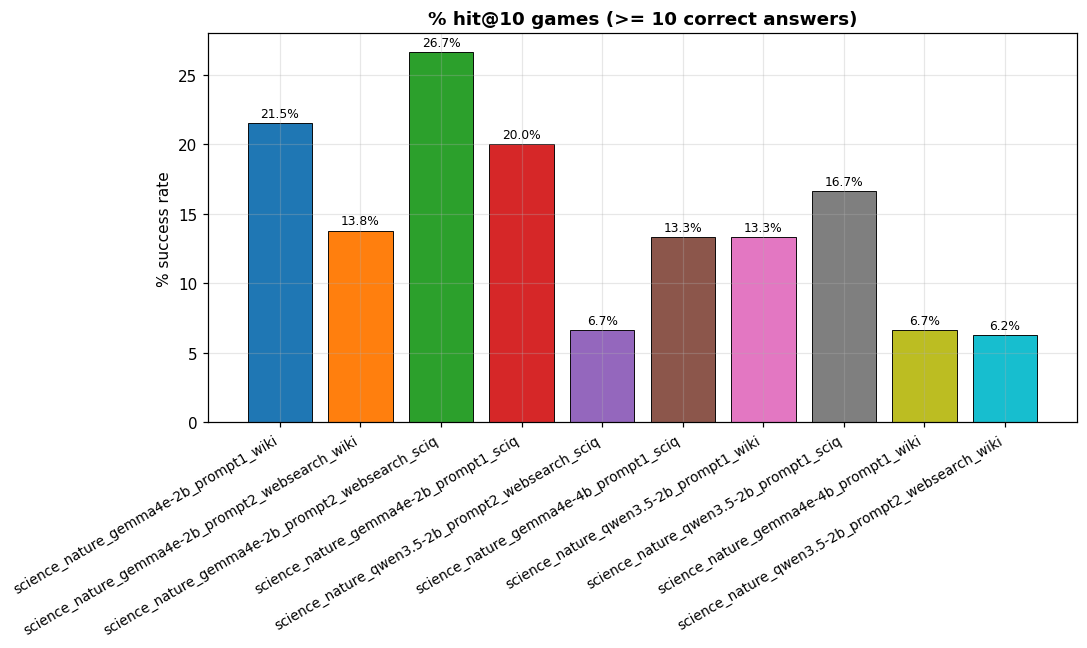

,model,hit@10
0,science_nature_gemma4e-2b_prompt1_wiki.json,21.538462
1,science_nature_gemma4e-2b_prompt2_websearch_wi...,13.793103
2,science_nature_gemma4e-2b_prompt2_websearch_sc...,26.666667
3,science_nature_gemma4e-2b_prompt1_sciq.json,20.000000
4,science_nature_qwen3.5-2b_prompt2_websearch_sc...,6.666667
5,science_nature_gemma4e-4b_prompt1_sciq.json,13.333333
6,science_nature_qwen3.5-2b_prompt1_wiki.json,13.333333
7,science_nature_qwen3.5-2b_prompt1_sciq.json,16.666667
8,science_nature_gemma4e-4b_prompt1_wiki.json,6.666667
9,science_nature_qwen3.5-2b_prompt2_websearch_wi...,6.250000


In [ ]:
# @title Science and Nature Hit@10

hit_at(10, EXPERIMENTS)

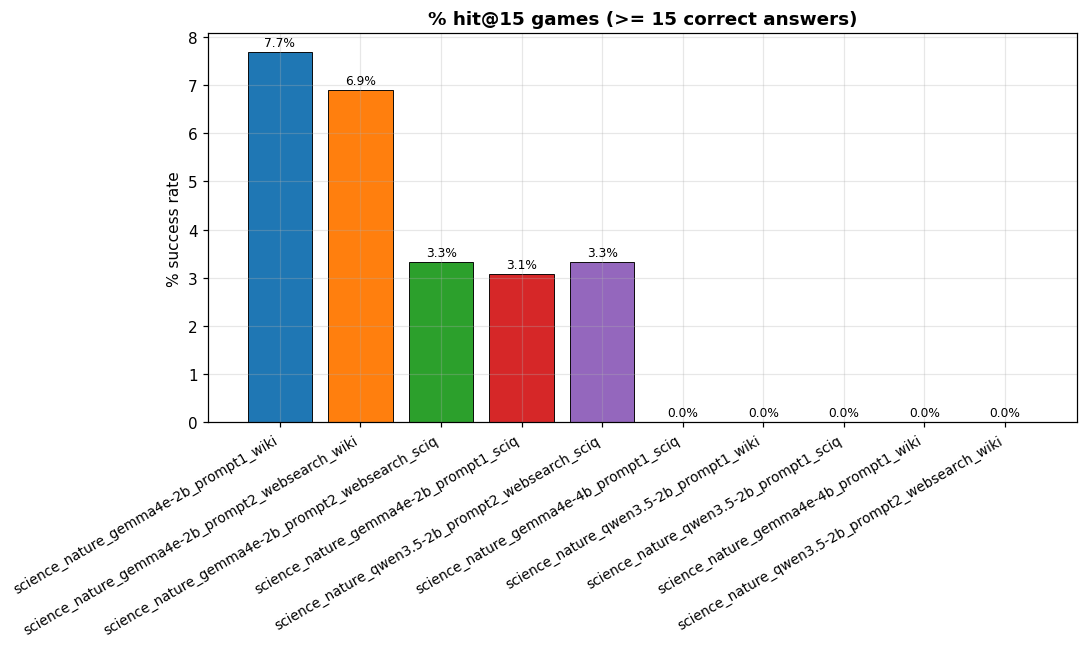

,model,hit@15
0,science_nature_gemma4e-2b_prompt1_wiki.json,7.692308
1,science_nature_gemma4e-2b_prompt2_websearch_wi...,6.896552
2,science_nature_gemma4e-2b_prompt2_websearch_sc...,3.333333
3,science_nature_gemma4e-2b_prompt1_sciq.json,3.076923
4,science_nature_qwen3.5-2b_prompt2_websearch_sc...,3.333333
5,science_nature_gemma4e-4b_prompt1_sciq.json,0.000000
6,science_nature_qwen3.5-2b_prompt1_wiki.json,0.000000
7,science_nature_qwen3.5-2b_prompt1_sciq.json,0.000000
8,science_nature_gemma4e-4b_prompt1_wiki.json,0.000000
9,science_nature_qwen3.5-2b_prompt2_websearch_wi...,0.000000


In [ ]:
# @title Science and Nature Hit@15

hit_at(15, EXPERIMENTS)

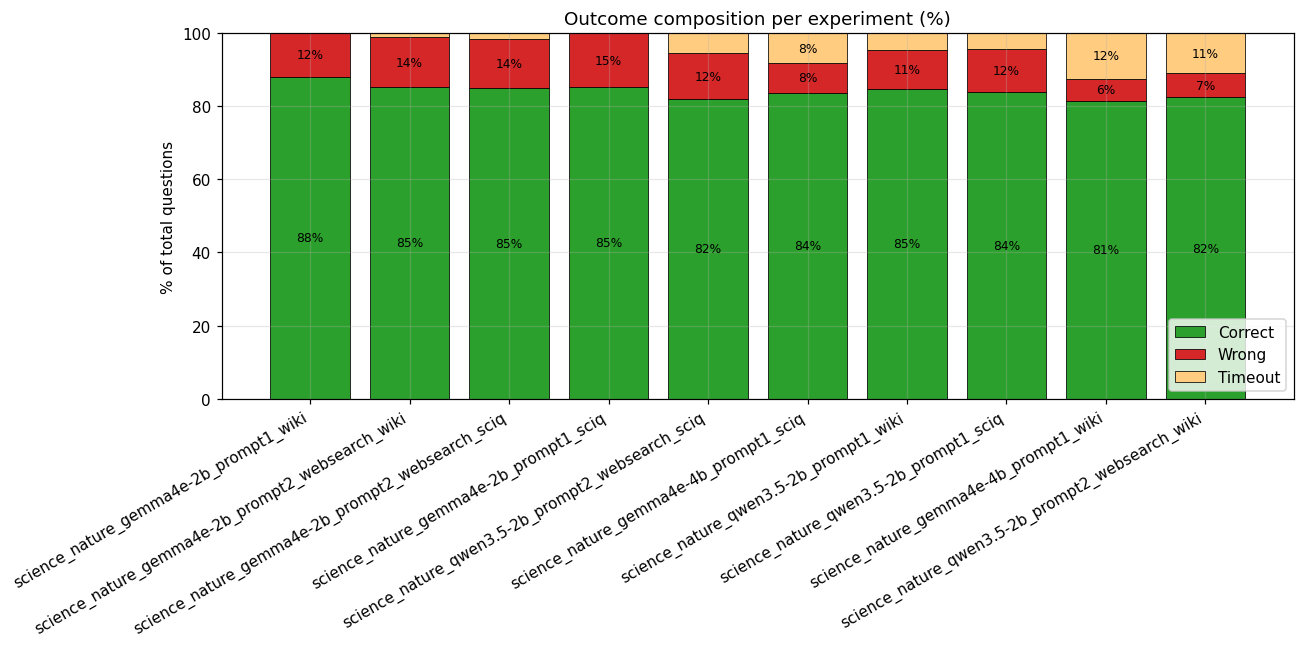

,model,tot_correct,tot_wrong,tot_timeout
0,science_nature_gemma4e-2b_prompt1_wiki.json,416,56,0
1,science_nature_gemma4e-2b_prompt2_websearch_wi...,156,25,2
2,science_nature_gemma4e-2b_prompt2_websearch_sc...,163,26,3
3,science_nature_gemma4e-2b_prompt1_sciq.json,363,63,0
4,science_nature_qwen3.5-2b_prompt2_websearch_sc...,133,20,9
5,science_nature_gemma4e-4b_prompt1_sciq.json,154,15,15
6,science_nature_qwen3.5-2b_prompt1_wiki.json,168,21,9
7,science_nature_qwen3.5-2b_prompt1_sciq.json,157,22,8
8,science_nature_gemma4e-4b_prompt1_wiki.json,131,10,20
9,science_nature_qwen3.5-2b_prompt2_websearch_wi...,75,6,10


In [ ]:
# @title Science and Nature outcomes distribution %

outcomes_pct(EXPERIMENTS)

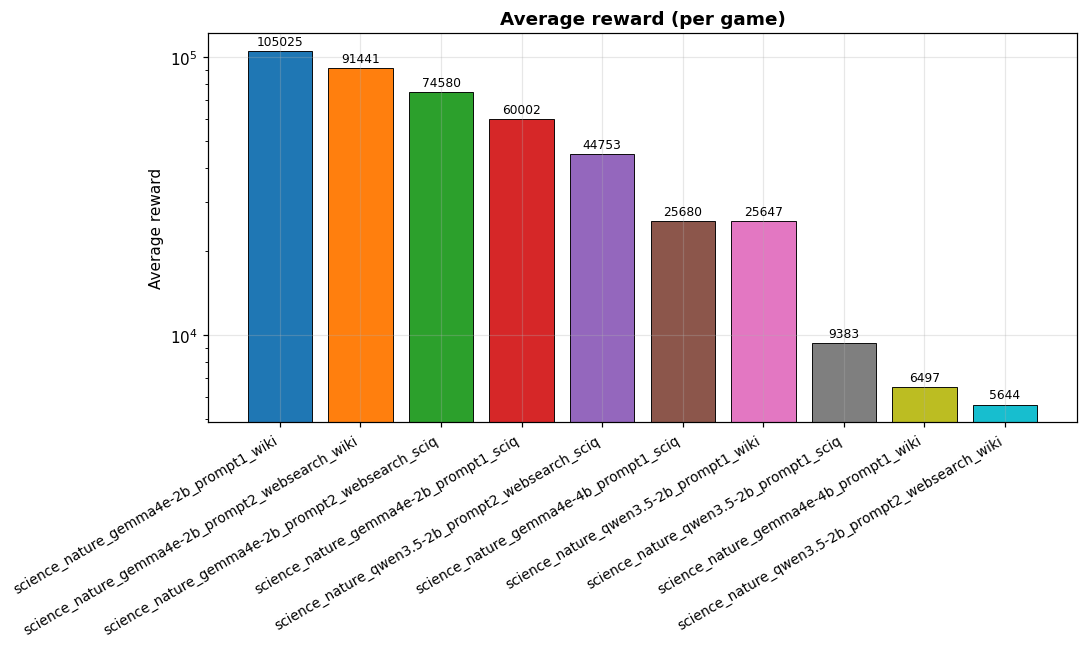

,model,avg_reward
0,science_nature_gemma4e-2b_prompt1_wiki.json,105024.615385
1,science_nature_gemma4e-2b_prompt2_websearch_wi...,91441.379310
2,science_nature_gemma4e-2b_prompt2_websearch_sc...,74580.000000
3,science_nature_gemma4e-2b_prompt1_sciq.json,60001.538462
4,science_nature_qwen3.5-2b_prompt2_websearch_sc...,44753.333333
5,science_nature_gemma4e-4b_prompt1_sciq.json,25680.000000
6,science_nature_qwen3.5-2b_prompt1_wiki.json,25646.666667
7,science_nature_qwen3.5-2b_prompt1_sciq.json,9383.333333
8,science_nature_gemma4e-4b_prompt1_wiki.json,6496.666667
9,science_nature_qwen3.5-2b_prompt2_websearch_wi...,5643.750000


In [ ]:
# @title Science and Nature average reward

avg_reward(EXPERIMENTS)

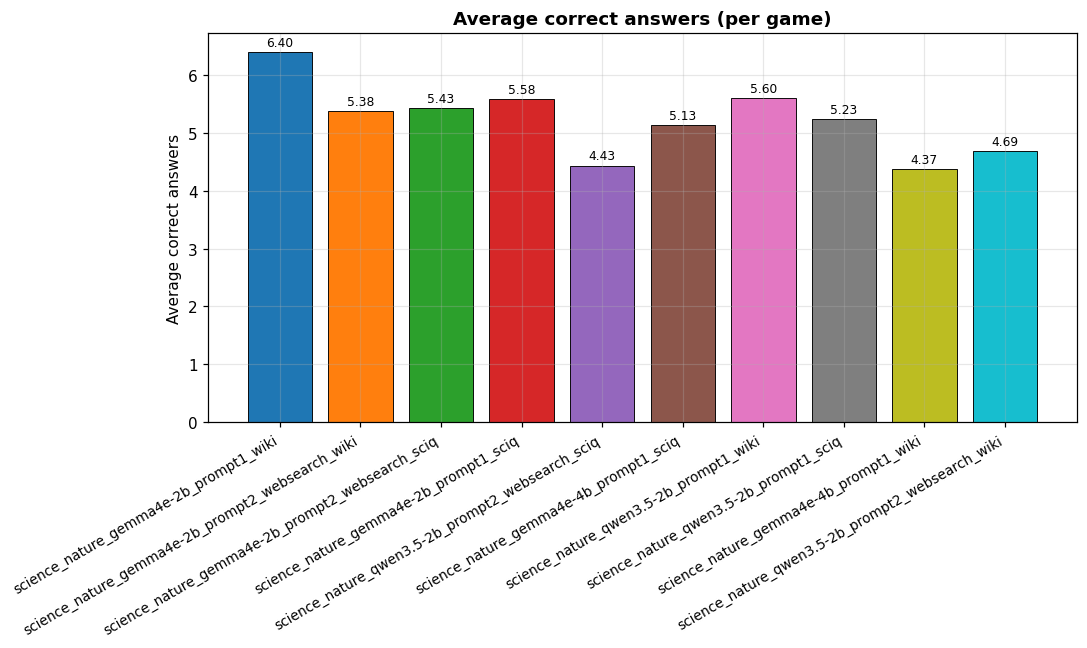

,model,avg_correct
0,science_nature_gemma4e-2b_prompt1_wiki.json,6.400000
1,science_nature_gemma4e-2b_prompt2_websearch_wi...,5.379310
2,science_nature_gemma4e-2b_prompt2_websearch_sc...,5.433333
3,science_nature_gemma4e-2b_prompt1_sciq.json,5.584615
4,science_nature_qwen3.5-2b_prompt2_websearch_sc...,4.433333
5,science_nature_gemma4e-4b_prompt1_sciq.json,5.133333
6,science_nature_qwen3.5-2b_prompt1_wiki.json,5.600000
7,science_nature_qwen3.5-2b_prompt1_sciq.json,5.233333
8,science_nature_gemma4e-4b_prompt1_wiki.json,4.366667
9,science_nature_qwen3.5-2b_prompt2_websearch_wi...,4.687500


In [ ]:
# @title Science and Nature average correct answers

avg_question(EXPERIMENTS)

## Philosophy and psicology


In [ ]:
# @title Philosophy and Psychology experiments selection

import re
import os

PROJECT_FOLDER = SETTINGS["notebook_settings"]["project_folder"]

candidate_dirs = [
    "logs/experiments/philosophy_psychology",
    "logs/experiments/philosophy_and_psychology",
    "logs/experiments/philosophy",
    "logs/experiments/psychology",
    "logs/experiments/psicology",
]

existing_dirs = [
    d for d in candidate_dirs
    if os.path.isdir(os.path.join(PROJECT_FOLDER, d))
]

if existing_dirs:
    MATCH_BASE_PATH = os.path.join(PROJECT_FOLDER, existing_dirs[0]) + "/"
    EXPERIMENTS = ["*.json"]
else:
    MATCH_BASE_PATH = os.path.join(PROJECT_FOLDER, "logs/experiments") + "/"
    EXPERIMENTS = [
        "*phil*.json",
        "*psy*.json",
        "*psic*.json",
    ]

reset_cache()

matched = match_files(EXPERIMENTS, force=True)
print(f"MATCHED {len(matched)} philosophy/psychology experiment file(s):")
for path in matched:
    print(f"  - {path}")

MATCHED 5 philosophy/psychology experiment file(s):
  - philosophy_psicology/philosophy_gemma4e-2b_prompt1.json
  - philosophy_psicology/philosophy_gemma4e-2b_prompt2_websearch.json
  - philosophy_psicology/philosophy_gemma4e-4b_prompt1.json
  - philosophy_psicology/philosophy_qwen3.5-2b_prompt1.json
  - philosophy_psicology/philosophy_qwen3.5-2b_prompt2_websearch.json


#### Philosophy and Psychology results comment

Philosophy and Psychology questions are mostly conceptual and definitional. They often require recognizing thinkers, schools of thought, psychological concepts, political theories, ethical positions, and subtle distinctions between similar ideas. For this reason, we tested different prompts, models, and configurations.

The best setup was **`philosophy_gemma4-e2b_prompt2_websearch`**. It was clearly the most reliable configuration, not only answering more questions correctly on average, but also reaching the later and higher-reward stages much more often. This suggests that the improved prompt and web search were especially useful for checking precise concepts and avoiding vague associations.

The base **Gemma4-e2B** configuration was also strong, showing that this model already works well for this category. However, adding web search produced a clear improvement, especially on harder questions where external confirmation helped.

The Qwen-based configurations were less competitive overall. They could answer some questions correctly, but they struggled more with consistency and rarely reached the deepest stages. The Qwen web-search variant did not improve enough to compensate for this gap.

The larger Gemma4-e4B setup also did not outperform Gemma4-e2B, which suggests that in this category the prompt and access to reliable external knowledge mattered more than model size alone.

Overall, the experiments show that **Gemma4-e2B with prompt2 and web search is the best architecture for Philosophy and Psychology**. Web search was particularly useful because many questions depend on precise definitions, authors, doctrines, and conceptual distinctions that are easy to confuse without external verification.

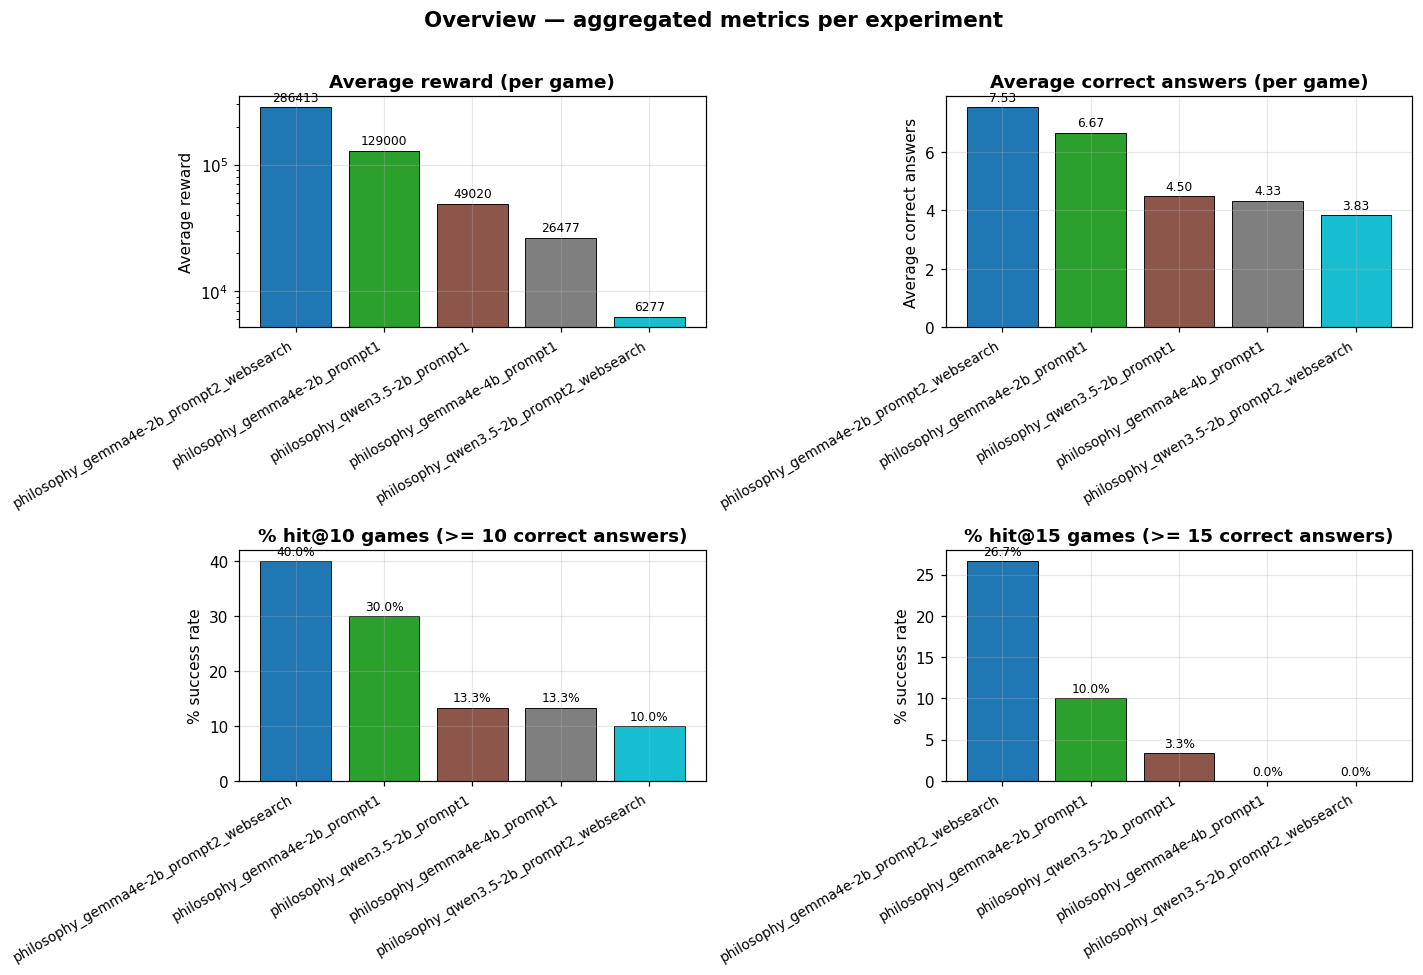

,model,n_runs,avg_reward,avg_correct,tot_correct,tot_wrong,tot_timeout,hit@10,hit@15
0,philosophy_psicology/philosophy_gemma4e-2b_pro...,30,286413.333333,7.533333,226,20,2,40.000000,26.666667
1,philosophy_psicology/philosophy_gemma4e-2b_pro...,30,129000.000000,6.666667,200,26,1,30.000000,10.000000
2,philosophy_psicology/philosophy_qwen3.5-2b_pro...,30,49020.000000,4.500000,135,20,9,13.333333,3.333333
3,philosophy_psicology/philosophy_gemma4e-4b_pro...,30,26476.666667,4.333333,130,8,22,13.333333,0.000000
4,philosophy_psicology/philosophy_qwen3.5-2b_pro...,30,6276.666667,3.833333,115,11,19,10.000000,0.000000


In [ ]:
# @title Philosophy and Psychology overview

overview(EXPERIMENTS)

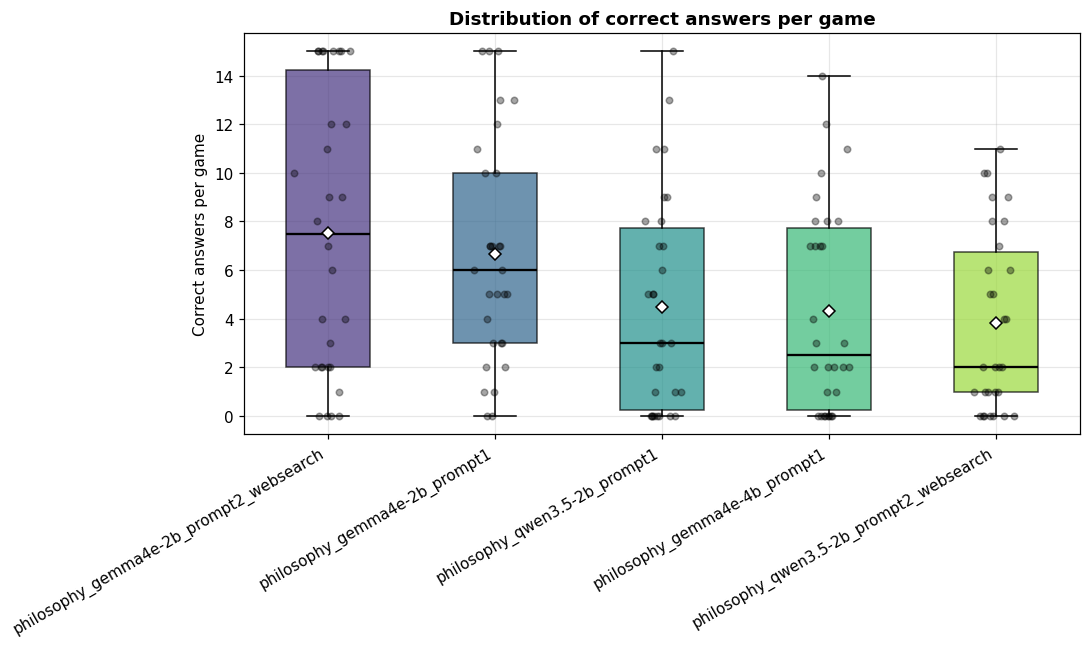

,file,model,session_idx,reward,n_questions,n_correct,n_wrong,n_timeout
0,philosophy_psicology/philosophy_gemma4e-2b_pro...,philosophy_psicology/philosophy_gemma4e-2b_pro...,0,0,1,0,0,1
1,philosophy_psicology/philosophy_gemma4e-2b_pro...,philosophy_psicology/philosophy_gemma4e-2b_pro...,1,300,4,3,1,0
2,philosophy_psicology/philosophy_gemma4e-2b_pro...,philosophy_psicology/philosophy_gemma4e-2b_pro...,2,200,3,2,1,0
3,philosophy_psicology/philosophy_gemma4e-2b_pro...,philosophy_psicology/philosophy_gemma4e-2b_pro...,3,4000,8,7,1,0
4,philosophy_psicology/philosophy_gemma4e-2b_pro...,philosophy_psicology/philosophy_gemma4e-2b_pro...,4,1024000,15,15,0,0
...,...,...,...,...,...,...,...,...
145,philosophy_psicology/philosophy_qwen3.5-2b_pro...,philosophy_psicology/philosophy_qwen3.5-2b_pro...,25,16000,10,9,1,0
146,philosophy_psicology/philosophy_qwen3.5-2b_pro...,philosophy_psicology/philosophy_qwen3.5-2b_pro...,26,2000,7,6,1,0
147,philosophy_psicology/philosophy_qwen3.5-2b_pro...,philosophy_psicology/philosophy_qwen3.5-2b_pro...,27,0,1,0,1,0
148,philosophy_psicology/philosophy_qwen3.5-2b_pro...,philosophy_psicology/philosophy_qwen3.5-2b_pro...,28,32000,11,10,0,1


In [ ]:
# @title Philosophy and Psychology boxplot

box_plot(EXPERIMENTS)

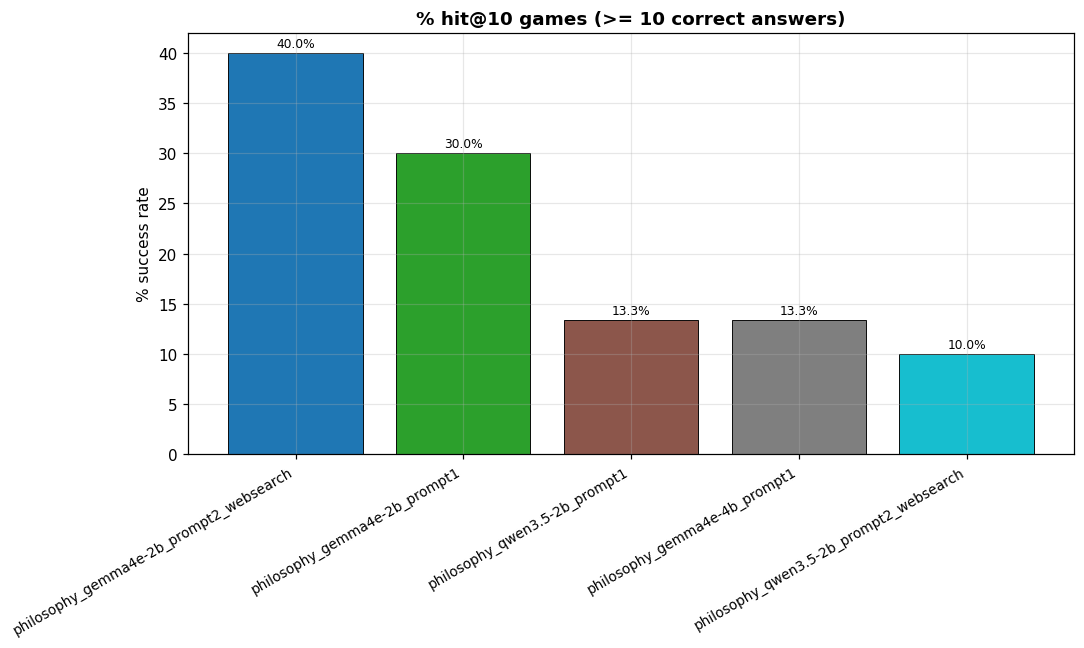

,model,hit@10
0,philosophy_psicology/philosophy_gemma4e-2b_pro...,40.000000
1,philosophy_psicology/philosophy_gemma4e-2b_pro...,30.000000
2,philosophy_psicology/philosophy_qwen3.5-2b_pro...,13.333333
3,philosophy_psicology/philosophy_gemma4e-4b_pro...,13.333333
4,philosophy_psicology/philosophy_qwen3.5-2b_pro...,10.000000


In [ ]:
# @title Philosophy and Psychology Hit@10

hit_at(10, EXPERIMENTS)

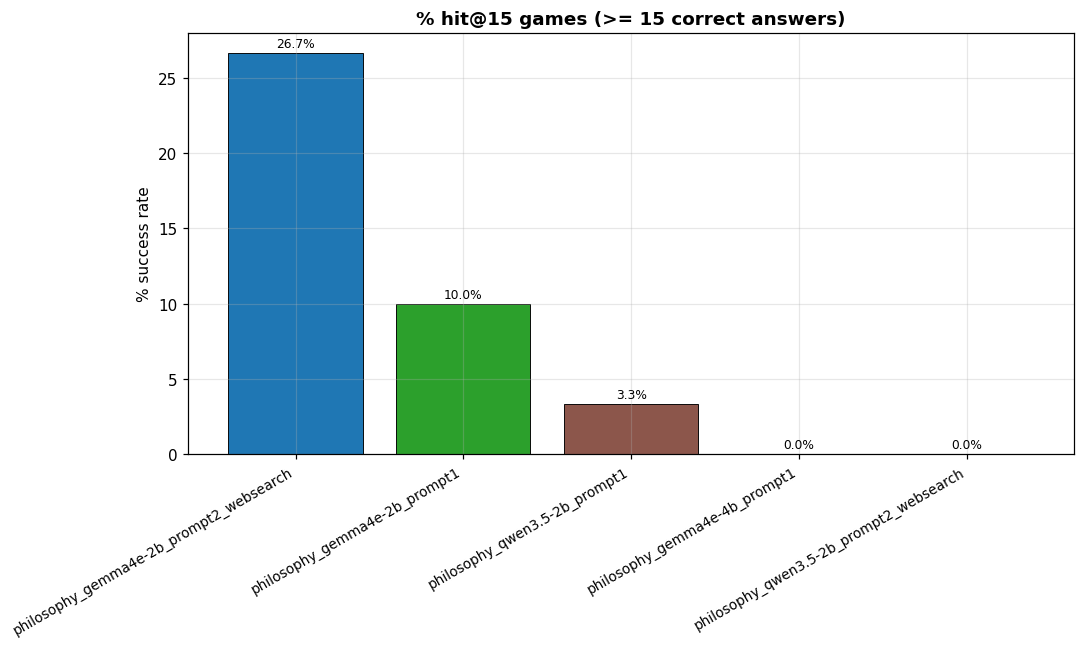

,model,hit@15
0,philosophy_psicology/philosophy_gemma4e-2b_pro...,26.666667
1,philosophy_psicology/philosophy_gemma4e-2b_pro...,10.000000
2,philosophy_psicology/philosophy_qwen3.5-2b_pro...,3.333333
3,philosophy_psicology/philosophy_gemma4e-4b_pro...,0.000000
4,philosophy_psicology/philosophy_qwen3.5-2b_pro...,0.000000


In [ ]:
# @title Philosophy and Psychology Hit@15

hit_at(15, EXPERIMENTS)

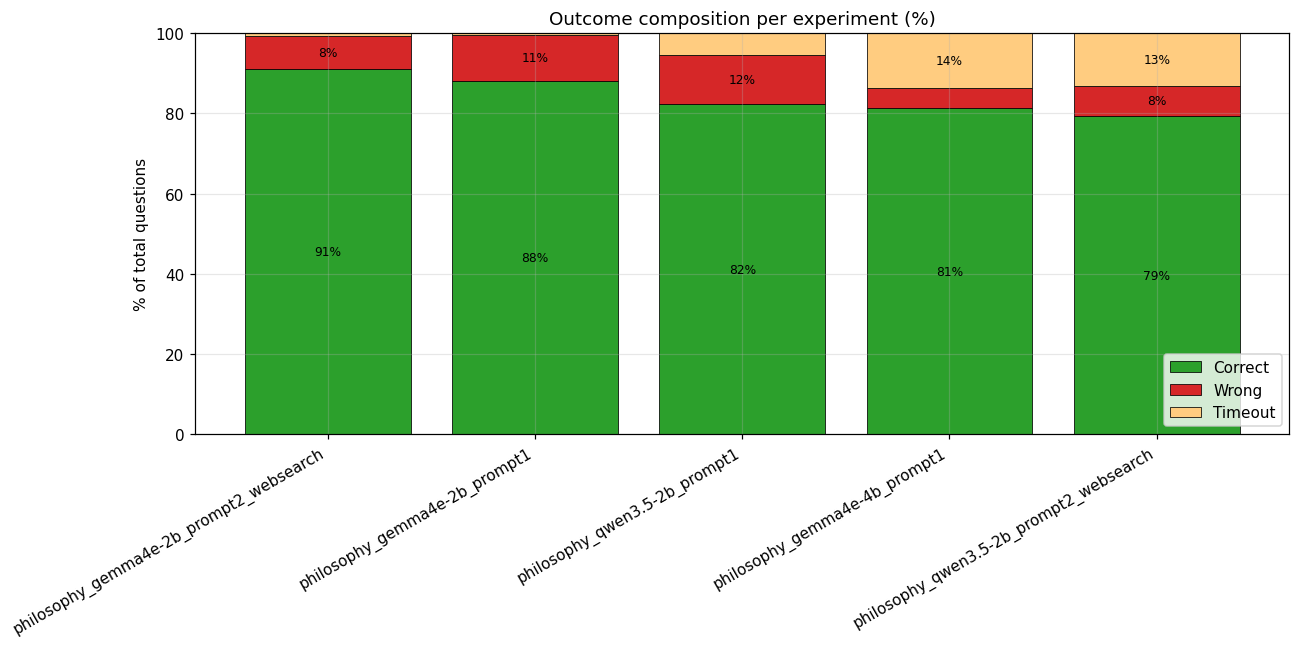

,model,tot_correct,tot_wrong,tot_timeout
0,philosophy_psicology/philosophy_gemma4e-2b_pro...,226,20,2
1,philosophy_psicology/philosophy_gemma4e-2b_pro...,200,26,1
2,philosophy_psicology/philosophy_qwen3.5-2b_pro...,135,20,9
3,philosophy_psicology/philosophy_gemma4e-4b_pro...,130,8,22
4,philosophy_psicology/philosophy_qwen3.5-2b_pro...,115,11,19


In [ ]:
# @title Philosophy and Psychology outcomes distribution %

outcomes_pct(EXPERIMENTS)

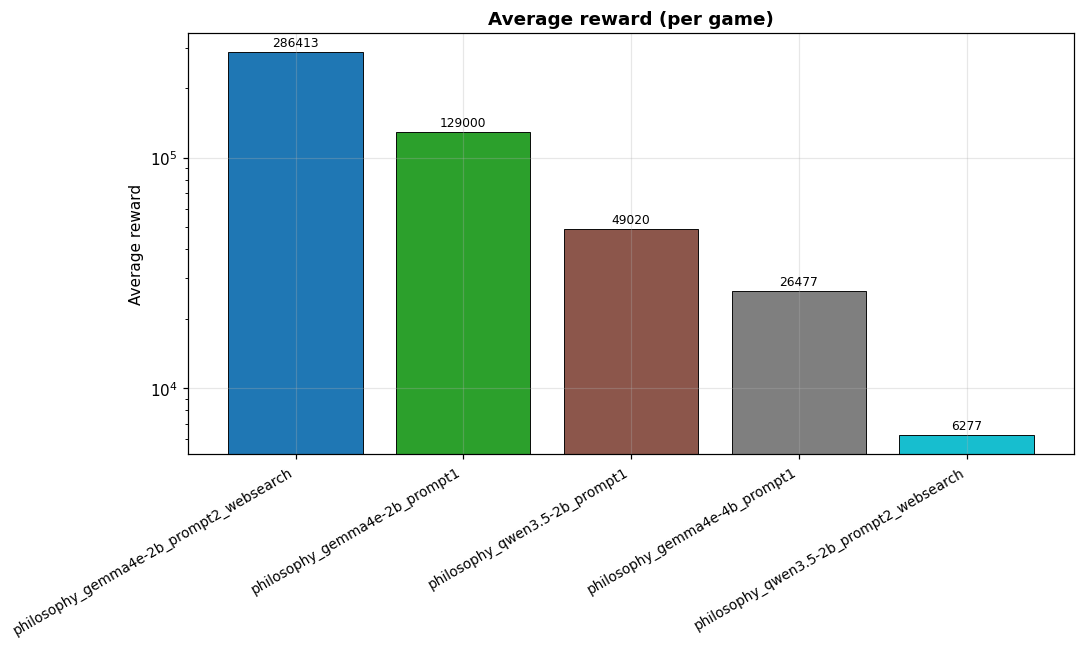

,model,avg_reward
0,philosophy_psicology/philosophy_gemma4e-2b_pro...,286413.333333
1,philosophy_psicology/philosophy_gemma4e-2b_pro...,129000.000000
2,philosophy_psicology/philosophy_qwen3.5-2b_pro...,49020.000000
3,philosophy_psicology/philosophy_gemma4e-4b_pro...,26476.666667
4,philosophy_psicology/philosophy_qwen3.5-2b_pro...,6276.666667


In [ ]:
# @title Philosophy and Psychology average reward

avg_reward(EXPERIMENTS)

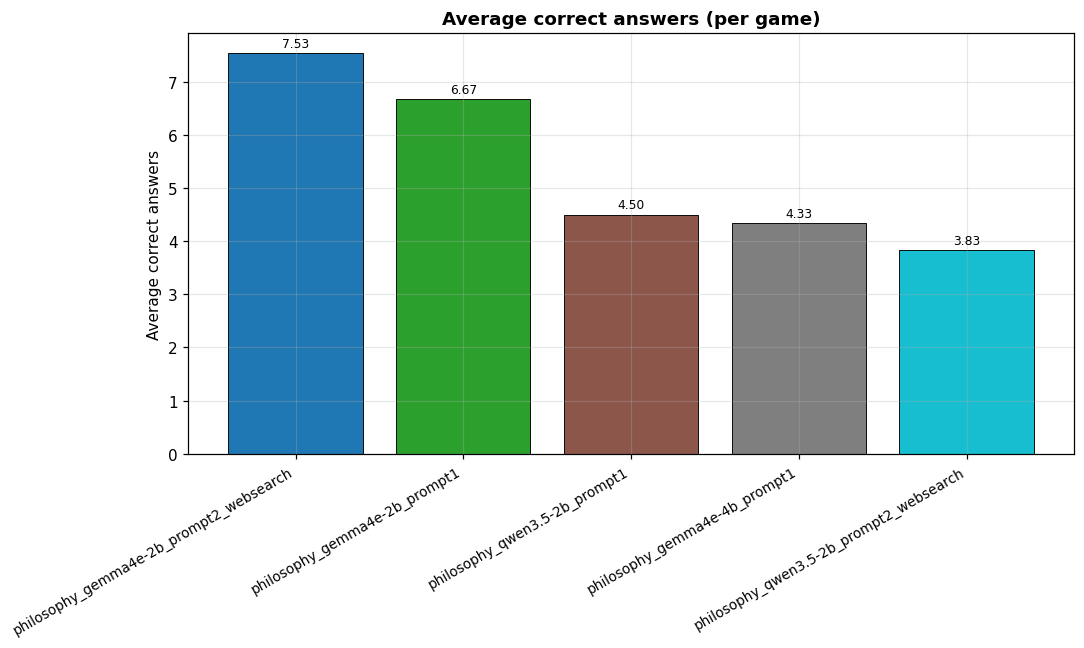

,model,avg_correct
0,philosophy_psicology/philosophy_gemma4e-2b_pro...,7.533333
1,philosophy_psicology/philosophy_gemma4e-2b_pro...,6.666667
2,philosophy_psicology/philosophy_qwen3.5-2b_pro...,4.500000
3,philosophy_psicology/philosophy_gemma4e-4b_pro...,4.333333
4,philosophy_psicology/philosophy_qwen3.5-2b_pro...,3.833333


In [ ]:
# @title Philosophy and Psychology average correct answers

avg_question(EXPERIMENTS)

## News


News questions were among the hardest categories, because they require recent and frequently changing information. For this reason, a static knowledge base was less suitable, while web search and webpage fetching were more useful.

The best overall setup was news_p0_gemma4-e2b_ws+wf, which reached the highest correctness rate, around 79%, with very few timeouts. This suggests that combining Gemma4-e2B with both web search and web fetching provided the most reliable external context.

The configuration news_p0_gemma4-e2b_ws was also strong and achieved the best hit@10 score. However, its results were less stable across games, showing that web search alone can sometimes perform very well, but is less consistent than search plus fetching.

The Tavily-based setups performed reasonably, but did not clearly outperform the Gemma4 configurations. Adding the date did not improve the results, suggesting that better retrieval quality mattered more than simply giving temporal information.

We also tried an original approach by using an "Hybrid Web Search". This tool performs a web search, fetches the results and performs an hybrid search over the web pages, returning only the most relevant chunks.
The results were still unsatisfying.

The Qwen-based models were generally weaker, with lower correctness and more timeouts. Specifically, they often felt in tool calls loops.

Overall, the best architecture for News was Gemma4-e2B with prompt0, web search, and web fetching, because this category needs fresh information and reliable use of external evidence.

In [ ]:
# @title News experiments selection

import glob

EXPERIMENTS = sorted(glob.glob("logs/experiments/NEWS/*.json"))

print(f"Found {len(EXPERIMENTS)} entertainment experiment file(s):")
for path in EXPERIMENTS:
    print(path)

Found 8 entertainment experiment file(s):
logs/experiments/NEWS/news_gemma2b_tavily.json
logs/experiments/NEWS/news_gemma2b_tavily_with_date.json
logs/experiments/NEWS/news_p0_gemma4e-2b_ws+wf.json
logs/experiments/NEWS/news_p0_gemma4e-2b_ws.json
logs/experiments/NEWS/news_p0_qwen3.5-2b_ws+wf.json
logs/experiments/NEWS/news_p0_qwen3.5-2b_ws.json
logs/experiments/NEWS/news_p1_gemma4e-2b_ws+wf.json
logs/experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json


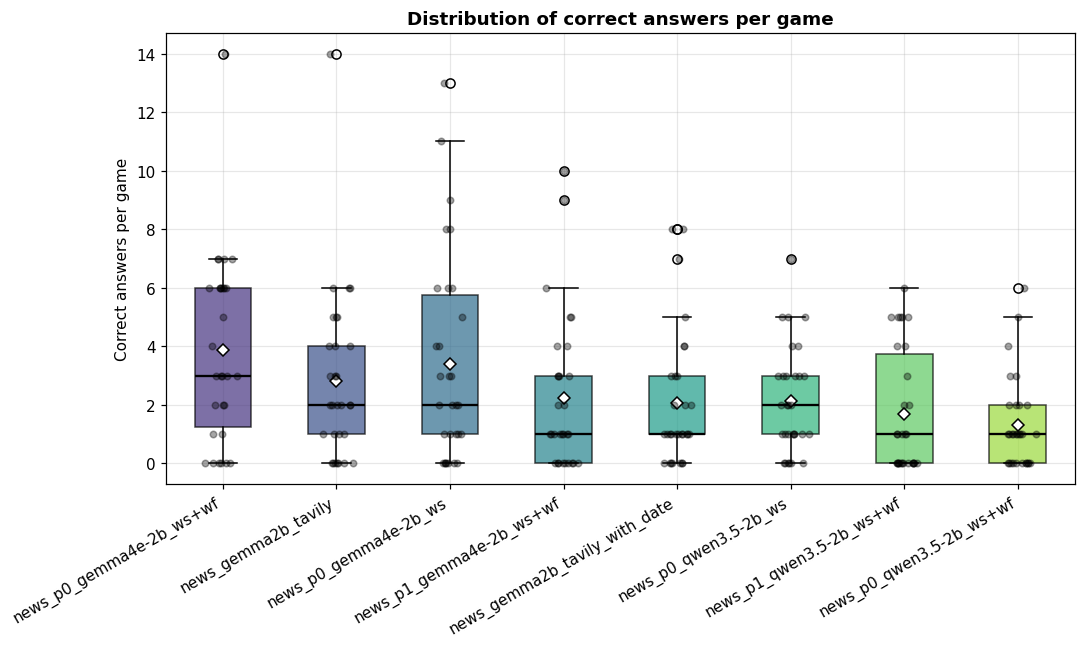

,file,model,session_idx,reward,n_questions,n_correct,n_wrong,n_timeout
0,experiments/NEWS/news_gemma2b_tavily.json,experiments/NEWS/news_gemma2b_tavily.json,0,0,1,0,1,0
1,experiments/NEWS/news_gemma2b_tavily.json,experiments/NEWS/news_gemma2b_tavily.json,1,1000,6,5,1,0
2,experiments/NEWS/news_gemma2b_tavily.json,experiments/NEWS/news_gemma2b_tavily.json,2,0,1,0,1,0
3,experiments/NEWS/news_gemma2b_tavily.json,experiments/NEWS/news_gemma2b_tavily.json,3,100,2,1,1,0
4,experiments/NEWS/news_gemma2b_tavily.json,experiments/NEWS/news_gemma2b_tavily.json,4,0,1,0,1,0
...,...,...,...,...,...,...,...,...
235,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,25,0,1,0,1,0
236,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,26,100,2,1,0,1
237,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,27,1000,6,5,0,1
238,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,28,2000,7,6,1,0


In [ ]:
# @title News boxplot
import fnmatch
import re
MATCH_BASE_PATH = "logs"


box_plot(EXPERIMENTS)

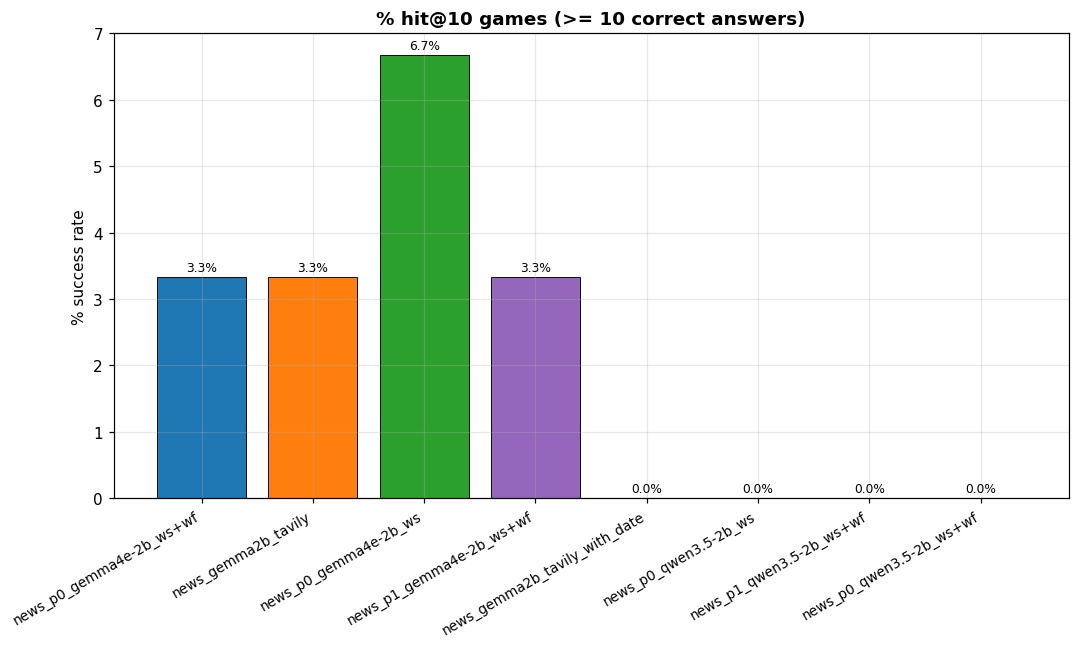

,model,hit@10
0,experiments/NEWS/news_p0_gemma4e-2b_ws+wf.json,3.333333
1,experiments/NEWS/news_gemma2b_tavily.json,3.333333
2,experiments/NEWS/news_p0_gemma4e-2b_ws.json,6.666667
3,experiments/NEWS/news_p1_gemma4e-2b_ws+wf.json,3.333333
4,experiments/NEWS/news_gemma2b_tavily_with_date...,0.000000
5,experiments/NEWS/news_p0_qwen3.5-2b_ws.json,0.000000
6,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,0.000000
7,experiments/NEWS/news_p0_qwen3.5-2b_ws+wf.json,0.000000


In [ ]:
# @title News Hit@10

hit_at(10, EXPERIMENTS)

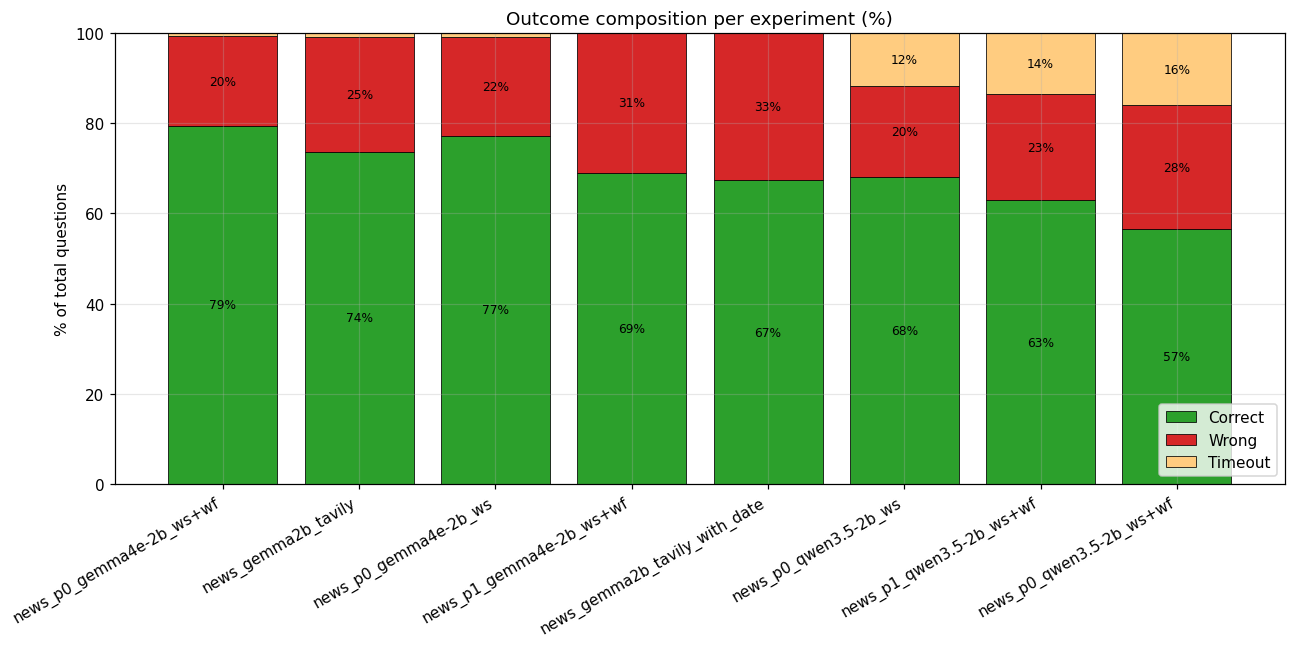

,model,tot_correct,tot_wrong,tot_timeout
0,experiments/NEWS/news_p0_gemma4e-2b_ws+wf.json,116,29,1
1,experiments/NEWS/news_gemma2b_tavily.json,84,29,1
2,experiments/NEWS/news_p0_gemma4e-2b_ws.json,102,29,1
3,experiments/NEWS/news_p1_gemma4e-2b_ws+wf.json,67,30,0
4,experiments/NEWS/news_gemma2b_tavily_with_date...,62,30,0
5,experiments/NEWS/news_p0_qwen3.5-2b_ws.json,64,19,11
6,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,51,19,11
7,experiments/NEWS/news_p0_qwen3.5-2b_ws+wf.json,39,19,11


In [ ]:
# @title News outcomes distribution %

outcomes_pct(EXPERIMENTS)

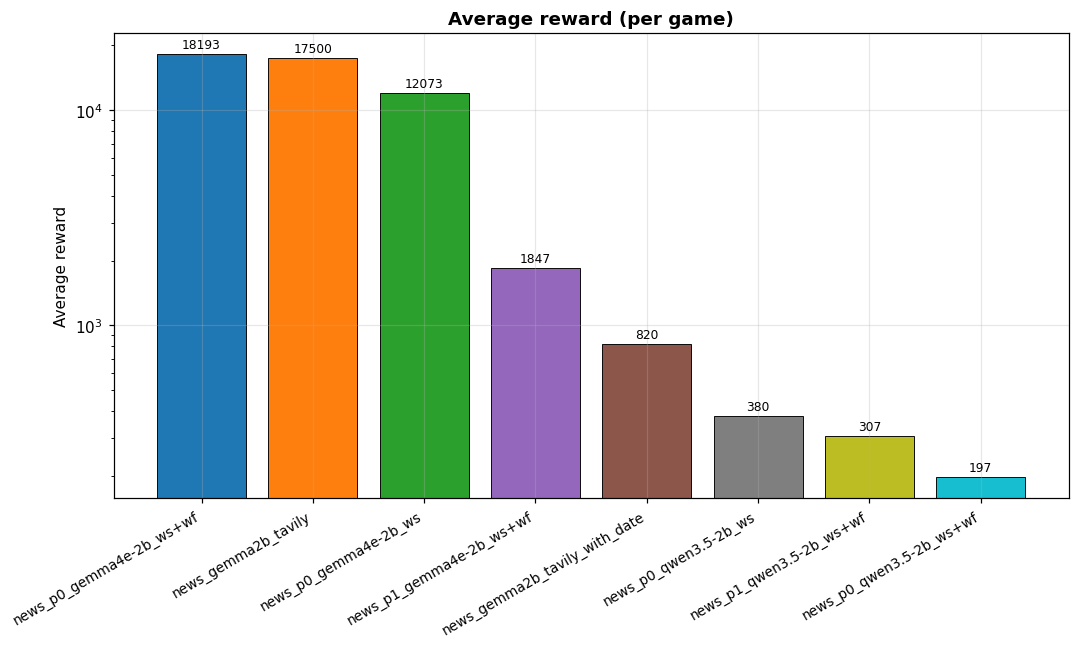

,model,avg_reward
0,experiments/NEWS/news_p0_gemma4e-2b_ws+wf.json,18193.333333
1,experiments/NEWS/news_gemma2b_tavily.json,17500.000000
2,experiments/NEWS/news_p0_gemma4e-2b_ws.json,12073.333333
3,experiments/NEWS/news_p1_gemma4e-2b_ws+wf.json,1846.666667
4,experiments/NEWS/news_gemma2b_tavily_with_date...,820.000000
5,experiments/NEWS/news_p0_qwen3.5-2b_ws.json,380.000000
6,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,306.666667
7,experiments/NEWS/news_p0_qwen3.5-2b_ws+wf.json,196.666667


In [ ]:
# @title News average reward

avg_reward(EXPERIMENTS)

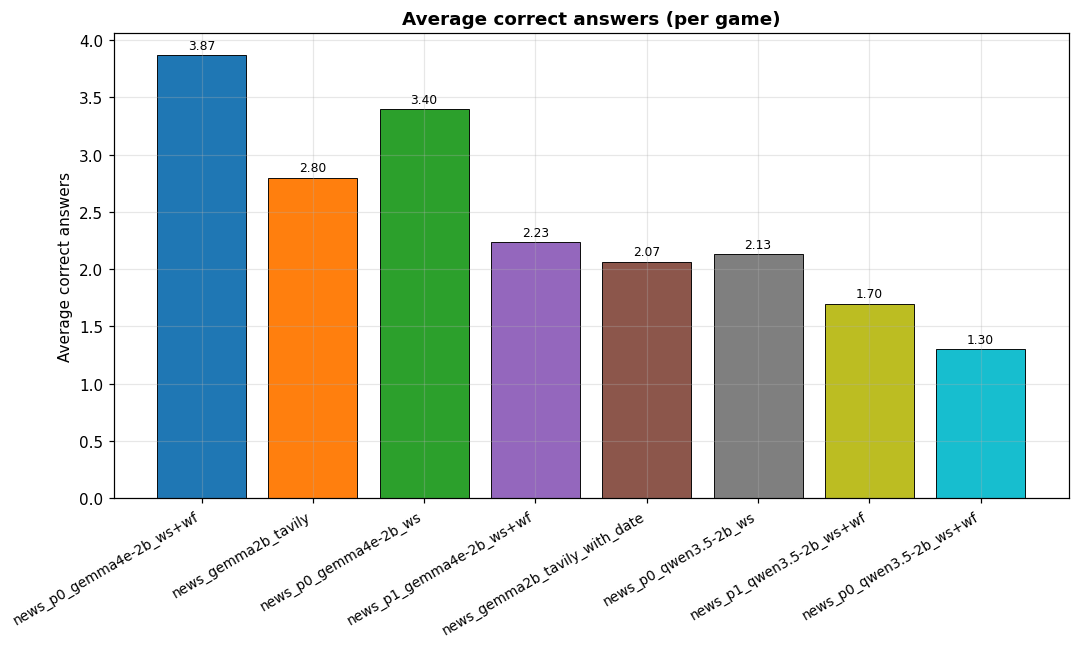

,model,avg_correct
0,experiments/NEWS/news_p0_gemma4e-2b_ws+wf.json,3.866667
1,experiments/NEWS/news_gemma2b_tavily.json,2.800000
2,experiments/NEWS/news_p0_gemma4e-2b_ws.json,3.400000
3,experiments/NEWS/news_p1_gemma4e-2b_ws+wf.json,2.233333
4,experiments/NEWS/news_gemma2b_tavily_with_date...,2.066667
5,experiments/NEWS/news_p0_qwen3.5-2b_ws.json,2.133333
6,experiments/NEWS/news_p1_qwen3.5-2b_ws+wf.json,1.700000
7,experiments/NEWS/news_p0_qwen3.5-2b_ws+wf.json,1.300000


In [ ]:
# @title News average correct answers

avg_question(EXPERIMENTS)

## Final comment on the experiments

Here is what we observed across the different categories:

- **Mathematics was the most different and one of the hardest domains.**  
  Unlike the other categories, Math could not be solved effectively with retrieval or factual knowledge alone. The best results came from models with stronger reasoning abilities, especially the Qwen family, and from adding calculation tools such as `python_eval` or `simple_calc`. Gemma models, which worked well in knowledge-based categories, were much weaker here, showing that mathematical reasoning requires a different strategy.

- **RAG-style categories benefited the most from retrieval and targeted search.**  
  Categories such as Entertainment, Ancient History, Science and Nature, and Philosophy/Psychology were mostly knowledge-based. In these domains, using retrieved context or web search helped the model access specific facts, definitions, names, events, and entities that small models may not store reliably. Overall, Gemma4e-2B was the most consistent model in these categories, especially when combined with Wikipedia-based retrieval or web search.

- **News required live external information.**  
  News was challenging because many answers depend on recent or changing facts, so relying only on the model’s internal knowledge was not enough. Web search and web fetching were more important here than in other categories, since the agent needed to find and verify up-to-date information. The results were more variable than in the RAG-style domains, but search-based configurations were clearly the most suitable approach.

## Audio Mode

The final architecture extends the system to speech-based games. Whisper transcribes the spoken question and options; optionally, a lightweight correction LLM cleans recognition errors before the standard agent loop answers the reconstructed multiple-choice question.

Specifically, the correction LLM is in charge of:
- **homophones disambiguation**
- **denoising** the text from redundant content such as repeated answer labels, laughters and unnecessary comments
- **restructuring** the transcription in a cleaner format

Therefore, as we have noticed that most of the errors were coming from the LLM not being able to clearly understand the questions, the polished results now allow our model to answer them as they were posed in the original textual format, at the cost of a small computational overhead.

In [ ]:
# @title Whisper Settings

SETTINGS["whisper"] = {
    "model": "small.en",
    "whisper_prompt": "You are transcribing questions about ancient civilization",
    "fix_question": False,
    "fix_question_llm": {
        "model": "qwen3.5:0.8b",
        "extra_body": {
            "reasoning_effort": "none",
        },
        "correction_prompt": """Fix a transcribed multiple-choice question.

The text comes from speech recognition. It has two problems:

1. Recognition errors: wrong words that sound alike (e.g. "four"->"for", "too"->"two"), missing or extra words, bad punctuation, garbled numbers or technical terms.

2. Spoken noise: things the speaker said out loud that are NOT part of the question. Remove all of these:
   - Answer labels: "option A", "option B", "letter C", "number one", "the first one", "the last one"
   - Laughter and filler sounds: "haha", "hahaha", "[laughs]", "ehm", "uh", "um", "hmm"
   - False starts, side comments, repeated words

Rules:
- Fix the errors. Remove the noise. Keep the meaning exactly.
- Do NOT rewrite the question. Do NOT add new content.
- Keep exactly 4 options.
- Output ONLY this format, nothing else:

Q: <question>
0. <option A>
1. <option B>
2. <option C>
3. <option D>

Example 1 (recognition errors):
Input:
Q: witch organ in the human body is responsible four pumping blood
0. The brain
1. The lungs
2. The heart
3. The liver
Output:
Q: Which organ in the human body is responsible for pumping blood?
0. The brain
1. The lungs
2. The heart
3. The liver

Example 2 (spoken noise):
Input:
Q: um what is the capital of France haha
0. option A Berlin
1. option B uh Madrid
2. option C Paris
3. and the last one London
Output:
Q: What is the capital of France?
0. Berlin
1. Madrid
2. Paris
3. London

Now correct this:
        """
    }

}

In [ ]:
# @title Load Whisper Model
import whisper

whisper_model = whisper.load_model(SETTINGS["whisper"]["model"])


In [ ]:
# @title Recognize Speech function

def recognize_speech(audio_data) -> str:
    """Transcribes audio using a locally hosted Whisper model.

    Handles both raw binary data (bytes) and string file paths.
    """
    # If the input is raw bytes, Whisper needs it written to a temporary file
    if isinstance(audio_data, bytes):
        with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as temp_file:
            temp_file.write(audio_data)
            audio_path = temp_file.name
        result = whisper_model.transcribe(audio_path, language="en", prompt=SETTINGS["whisper"]["whisper_prompt"])

        # Clean up the temporary file safely
        try:
            os.remove(audio_path)
        except OSError:
            pass
    else:
        # If it's already a string path (e.g., "level_1_question.wav")
        result = whisper_model.transcribe(str(audio_data))

    return result.get("text", "").strip()


In [ ]:
import time as _time

# @title Speech Correction Agent Architecture
def run_agent_corrected_loop(
    question: str,
    settings: dict,
    agent: str = "maths",
    max_iterations: int = 10,
    datasets: dict | None = None,
    verbose: bool = False,
    question_idx: str = "numbers",
) -> dict:
    t0 = _time.time()

    # 1. Correction Step
    correction_cfg = settings["whisper"]["fix_question_llm"]
    correction_model = correction_cfg["model"]
    correction_prompt = correction_cfg["correction_prompt"]

    # Setup a dedicated LLM for correction
    correction_llm_settings = copy.deepcopy(settings)
    correction_llm_settings["llm"]["model"] = correction_model
    correction_llm_settings["llm"]["extra_body"] = correction_cfg.get("extra_body", {})

    c_llm = build_llm(correction_llm_settings)

    if verbose:
        print(f"  [speech-correction] Using {correction_model} to clean transcription...")

    c_messages = [
        SystemMessage(content=correction_prompt),
        HumanMessage(content=f"Please fix this transcribed text:\n{question}")
    ]

    c_response = c_llm.invoke(c_messages)
    corrected_question = c_response.content.strip()
    t1 = _time.time()
    print(t1-t0)
    if verbose:
        print(f"--- Corrected Question ---\n{corrected_question}\n-------------------------")

    # 2. Main Agent Execution
    # We use the corrected text as the new input for the standard agent loop
    result = run_agent_loop(
        question=corrected_question,
        settings=settings,
        agent=agent,
        max_iterations=max_iterations,
        datasets=datasets,
        verbose=verbose,
        question_idx=question_idx,
    )

    # Add metadata about the correction process
    result["original_question"] = question
    result["corrected_question"] = corrected_question
    result["answer_time"] = _time.perf_counter() - t0

    return result

In [ ]:
# @title Speech Game experiments

SETTINGS["polimillionaire"]["experiments"] = 20
SETTINGS["polimillionaire"]["experiment_name"] = "gemmae2b-whisper-medium-ancient-raw"

for i in range(SETTINGS["polimillionaire"]["experiments"]):
  print(f"\n=== Starting Game {i} ===")
  game = client.game.start(competition_id=comp_id, mode="speech")
  print(f"Session ID: {game.session_id}")
  print(f"Total number of questions: {game.state.competition.max_levels}")
  print()
  if SETTINGS["whisper"]["fix_question"]:
    arch = run_agent_corrected_loop
  else:
    arch = run_agent_loop
  play_game(game, audio_mode=True, recognize_speech=recognize_speech, architecture=arch)

### Whisper results
We managed to run a few experiments with Whisper.
We run our best performing ancient model with speech, here are the results.

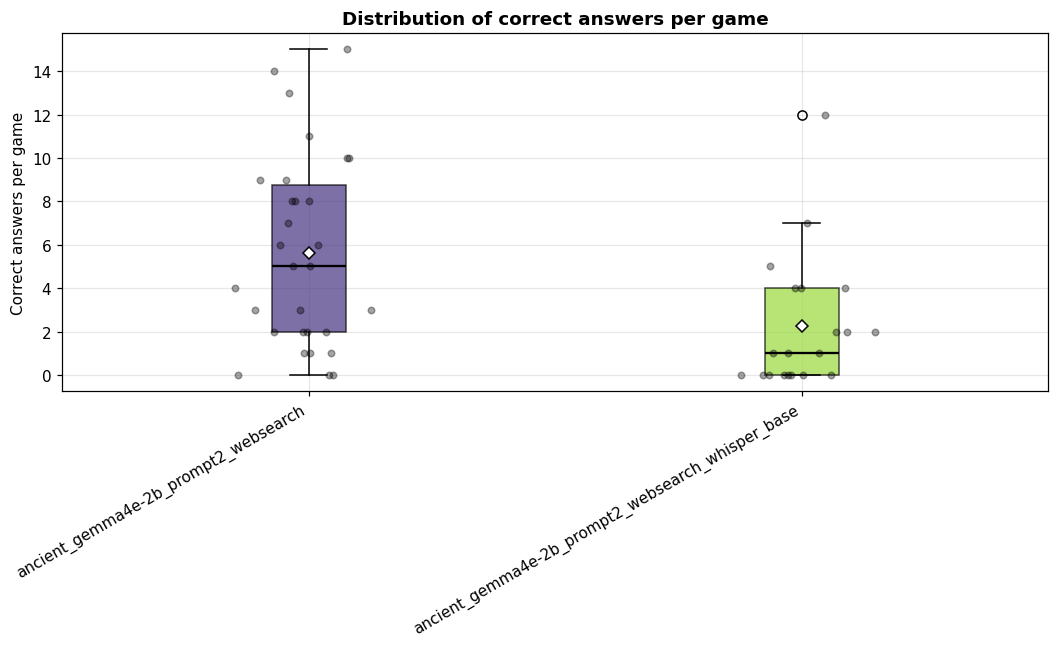

In [ ]:
_ = box_plot(["experiments/ancient/ancient_gemma4e-2b_prompt2_websearch*"])

As we can see, the errors in transcription cause the model to perform much worse.

More experiments must be done to learn how to fix these transcription errors and additional way to recover